# Cyclone Oceanic Response Analysis: Scale Decomposition

**Cyclones Analyzed:** Remal (May 2024) & Dana (October 2024)

**Data Sources:**
- SST: GHRSST MUR-JPL-L4-GLOB-v4.1 (0.01° resolution)
- MSLA: CMEMS SEALEVEL_GLO_PHY_L4_MY_008_047 (0.125Â° resolution)

**Phases:**
1. Date-wise Data Inventory & First-look Plots
2. 2D Gaussian Filter for Scale Separation
3. Scale-wise Visual Comparison
4. Cyclone Response by Scale 

In [2]:
import os
import glob
import re
import json
import warnings
from datetime import datetime, timedelta
from math import ceil

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize, TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean  

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150})

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [3]:
# =============================================================================
# DATA PATHS
# =============================================================================
SST_DATA_DIR = r"C:\Users\abhik\Downloads\New_folder\MUR-JPL-L4-GLOB-v4.1_4.1-20260316_132446"
MSLA_ROOT_DIR = r"C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024"

OUTPUT_DIR = r"C:\Users\abhik\Desktop\project related work\Cyclone_Analysis_Outputs_newscale_500large"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

CYCLONE_JSON_PATH = r"C:\Users\abhik\Desktop\project related work\cyclone_info_2024_padded.json"

SELECT_BASINS = None
SELECT_STORMS = None

PRE_DAYS = None
POST_DAYS = None
# =========================
# HELPERS
# =========================
def _parse_date(date_str):
    return datetime.strptime(date_str, "%Y-%m-%d") if date_str else None

def _mph_to_kt(mph):
    return round(mph * 0.868976, 1) if mph is not None else None

def _derive_analysis_dates(dates):
    formation = _parse_date(dates.get("formation"))
    dissipation = _parse_date(dates.get("dissipation"))
    landfall = _parse_date(dates.get("landfall"))

    if not formation or not dissipation:
        return {}

    during_end = landfall or dissipation
    pre_days = PRE_DAYS or 0
    post_days = POST_DAYS or 0

    return {
        "pre": (
            (formation - timedelta(days=pre_days)).strftime("%Y-%m-%d"),
            (formation - timedelta(days=1)).strftime("%Y-%m-%d"),
        ),
        "during": (
            formation.strftime("%Y-%m-%d"),
            during_end.strftime("%Y-%m-%d"),
        ),
        "post": (
            (during_end + timedelta(days=1)).strftime("%Y-%m-%d"),
            (during_end + timedelta(days=post_days)).strftime("%Y-%m-%d"),
        ),
    }

def _normalize_storm_record(storm):
    max_wind_kt = storm.get("max_wind_kt") or _mph_to_kt(storm.get("max_wind_mph"))
    min_pressure = storm.get("min_pressure_hPa") or storm.get("min_pressure_mb")

    dates = storm.get("dates", {})
    analysis_dates = storm.get("analysis_dates") or _derive_analysis_dates(dates)

    normalized = {
        "name": storm.get("name", "Unknown"),
        "dates": dates,
        "analysis_dates": analysis_dates,
        "max_wind_kt": max_wind_kt,
        "min_pressure_hPa": min_pressure,
    }
    if "track" in storm:
        normalized["track"] = storm["track"]
    if "bbox" in storm:
        normalized["bbox"] = storm["bbox"]
    if "category" in storm:
        normalized["category"] = storm["category"]
    return normalized

def load_cyclones(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    cyclones = {}

    for basin_key, basin in data.items():
        if SELECT_BASINS and basin_key.lower() not in [b.lower() for b in SELECT_BASINS]:
            continue

        for storm in basin.get("storms", []):
            name = storm.get("name", "").strip()
            if SELECT_STORMS and name.lower() not in [n.lower() for n in SELECT_STORMS]:
                continue

            cyclones[name.upper()] = _normalize_storm_record(storm)

    return cyclones

# =========================
# MAIN
# =========================
cyclones = load_cyclones(CYCLONE_JSON_PATH)

# results = {}

# for name, info in cyclones.items():
#     formation = info["dates"].get("formation")
#     dissipation = info["dates"].get("dissipation")

#     if not formation or not dissipation:
#         continue

#     start = _parse_date(formation)
#     end = _parse_date(dissipation)

#     days = (end - start).days + 1
#     results[name] = days

# =========================
# FILTER >= 6 DAYS
# =========================
# filtered = {k: v for k, v in results.items() if v >= 6}

# =========================
# OUTPUT
# =========================
# print("Cyclones (>= 6 days):\n")

# for name, days in sorted(filtered.items(), key=lambda x: x[1], reverse=True):
#     print(f"{name}: {days} days")

# print("\nTotal cyclones:", len(results))
# print("Cyclones >=6 days:", len(filtered))

In [4]:
# import json
# from datetime import datetime, timedelta

# OUTPUT_PATH = r"C:\Users\abhik\Desktop\project related work\cyclone_info_2024_padded.json"


# =========================
# HELPERS
# =========================

# def _format(date_value):
#     if isinstance(date_value, datetime):
#         return date_value.strftime("%Y-%m-%d")
#     return datetime.strptime(date_value, "%Y-%m-%d").strftime("%Y-%m-%d")


# def get_padding(days, storm_name=None):
#     """Return (pre_days, post_days) to normalize durations to 12 or 20 days."""
#     name = (storm_name or "").strip().upper()
#     if name == "ANGGREK" and days == 22:
#         return (0, 0)
#     if days == 20 or days == 12:
#         return (0, 0)
#     if 12 < days < 20:
#         needed = 20 - days
#         pre = needed // 2
#         post = needed - pre
#         return (pre, post)
#     else:
#         needed = 12 - days
#         pre = needed // 2
#         post = needed - pre
#         return (pre, post)


# =========================
# MAIN PROCESS
# =========================
# with open(CYCLONE_JSON_PATH, "r", encoding="utf-8") as f:
#     data = json.load(f)


# for basin in data.values():
#     for storm in basin.get("storms", []):
#         dates = storm.get("dates", {})

#         formation = dates.get("formation")
#         dissipation = dates.get("dissipation")

#         if not formation or not dissipation:
#             continue

#         start = _parse_date(formation)
#         end = _parse_date(dissipation)

#         days = (end - start).days + 1

#         pre_days, post_days = get_padding(days, storm.get("name"))

#         start_analysis = start - timedelta(days=pre_days)
#         end_analysis = end + timedelta(days=post_days)

#         # Keep formation/dissipation unchanged; write analysis window separately
#         dates["start_analysis_date"] = _format(start_analysis)
#         dates["end_analysis_date"] = _format(end_analysis)


# =========================
# SAVE UPDATED FILE
# =========================
# with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
#     json.dump(data, f, indent=2)


# print("✅ JSON updated with analysis window dates (12 or 20 days)")
# name_days = []

# for basin in data.values():
#     for storm in basin.get("storms", []):
#         name = storm.get("name")
#         dates = storm.get("dates", {})
#         formation = dates.get("formation")
#         dissipation = dates.get("dissipation")
#         start_analysis = dates.get("start_analysis_date")
#         end_analysis = dates.get("end_analysis_date")
#         if not name or not formation or not dissipation:
#             continue
#         start = datetime.strptime(formation, "%Y-%m-%d")
#         end = datetime.strptime(dissipation, "%Y-%m-%d")
#         days = (end - start).days + 1
#         start = datetime.strptime(start_analysis, "%Y-%m-%d")
#         end = datetime.strptime(end_analysis, "%Y-%m-%d")
#         pad_days = (end - start).days + 1
#         name_days.append((name, days, pad_days))

# print("Cyclone durations (days):")
# for name, days, pad_days in sorted(name_days, key=lambda x: x[0].lower()):
#     print(f"{name}: {days} (padded: {pad_days})")

---
# PHASE 1: Date-wise Data Inventory & First-look Plots

## 1.1 Cyclone Track Summary

In [ ]:
def print_cyclone_summary(cyclone_data=None):
    """Print comprehensive summary of cyclones from basin or flat structure."""
    data = cyclone_data if cyclone_data is not None else cyclones
    print("=" * 80)
    print("CYCLONE INVENTORY SUMMARY")
    print("=" * 80)
    
    def _derive_bbox_from_track(track):
        if not track:
            return None
        lons = [p[0] for p in track]
        lats = [p[1] for p in track]
        return {
            "lon_min": min(lons),
            "lon_max": max(lons),
            "lat_min": min(lats),
            "lat_max": max(lats),
        }
    
    def _print_storm(cyc_name, cyc):
        print(f"\n{'=' * 40}")
        print(f"CYCLONE: {cyc.get('name', cyc_name)}")
        print(f"{'=' * 40}")
        print(f"Category: {cyc.get('category', 'N/A')}")
        max_wind = cyc.get('max_wind_mph') or cyc.get('max_wind_kt', 'N/A')
        min_press = cyc.get('min_pressure_mb') or cyc.get('min_pressure_hPa', 'N/A')
        print(f"Max Wind: {max_wind} | Min Pressure: {min_press}")
        print(f"")
        print(f"KEY DATES:")
        for key, date in cyc.get('dates', {}).items():
            print(f"  {key.capitalize():20} : {date}")
        print(f"")
        track = cyc.get('track', [])
        bb = cyc.get('bbox') or _derive_bbox_from_track(track)
        print(f"ANALYSIS BOUNDING BOX:")
        if bb:
            print(f"  Longitude: {bb.get('lon_min', 'N/A')} °E to {bb.get('lon_max', 'N/A')} °E")
            print(f"  Latitude:  {bb.get('lat_min', 'N/A')} °N to {bb.get('lat_max', 'N/A')} °N")
        else:
            print("  N/A")
        print(f"")
        analysis_dates = cyc.get('analysis_dates', {})
        if analysis_dates:
            print(f"ANALYSIS PERIODS:")
            for phase, dates in analysis_dates.items():
                if isinstance(dates, (list, tuple)) and len(dates) == 2:
                    print(f"  {phase.capitalize():8} : {dates[0]} to {dates[1]}")
                else:
                    print(f"  {phase.capitalize():8} : {dates}")
            print(f"")
        print(f"TRACK POSITIONS ({len(track)} points):")
        print(f"  {'Date/Time':<18} {'Lon':>8} {'Lat':>8} {'Wind':>8} {'Pres':>8}")
        for point in track:
            if len(point) == 5:
                lon, lat, dt, wind, pres = point
                w_str = f"{wind:>6}" if wind is not None else "   N/A"
                p_str = f"{pres:>6}" if pres is not None else "   N/A"
                print(f"  {dt:<18} {float(lon):>8.1f} {float(lat):>8.1f} {w_str} {p_str}")
            else:
                print(f"  {str(point)}")
    
    if any(isinstance(v, dict) and 'storms' in v for v in data.values()):
        for basin in data.values():
            for storm in basin.get('storms', []):
                name = storm.get('name', 'Unknown')
                _print_storm(name, storm)
    else:
        for cyc_name, cyc in data.items():
            _print_storm(cyc_name, cyc)
    
    print(f"\n{'=' * 80}")

# print_cyclone_summary()

CYCLONE INVENTORY SUMMARY

CYCLONE: Alberto
Category: TS
Max Wind: 43.4 | Min Pressure: 993

KEY DATES:
  Formation            : 2024-06-17
  Peak                 : 2024-06-20
  Landfall             : None
  Dissipation          : 2024-06-20
  Start_analysis_date  : 2024-06-13
  End_analysis_date    : 2024-06-24

ANALYSIS BOUNDING BOX:
  Longitude: -98.8 °E to -92.6 °E
  Latitude:  19.9 °N to 22.4 °N

ANALYSIS PERIODS:
  Pre      : 2024-06-17 to 2024-06-16
  During   : 2024-06-17 to 2024-06-20
  Post     : 2024-06-21 to 2024-06-20

TRACK POSITIONS (23 points):
  Date/Time               Lon      Lat     Wind     Pres
  2024-06-17 18:00      -92.7     19.9     35   1001
  2024-06-17 21:00      -92.7     20.2     35   1000
  2024-06-18 00:00      -92.7     20.4     35    999
  2024-06-18 03:00      -92.7     20.6     35    999
  2024-06-18 06:00      -92.7     20.9     35    999
  2024-06-18 09:00      -92.7     21.2     35    999
  2024-06-18 12:00      -92.6     21.5     35    999
  202

## 1.2 Data Loading Functions

In [6]:
def extract_date_from_sst_filename(filepath):
    """Parse YYYYMMDD from SST filename."""
    filename = os.path.basename(filepath)
    match = re.match(r'^(\d{8})', filename)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    raise ValueError(f"Cannot parse date from: {filename}")


def load_sst_for_date(date, region, downsample=5):
    """
    Load SST data for a specific date.
    
    Parameters
    ----------
    date : datetime or str
        Date to load (YYYY-MM-DD format if string)
    region : dict
        {lon_min, lon_max, lat_min, lat_max}
    downsample : int
        Spatial subsampling factor
    
    Returns
    -------
    xr.DataArray : SST in degrees Celsius
    """
    if isinstance(date, str):
        date = datetime.strptime(date, '%Y-%m-%d')
    
    date_str = date.strftime('%Y%m%d')
    pattern = os.path.join(SST_DATA_DIR, f"{date_str}*.nc")
    files = glob.glob(pattern)
    
    if not files:
        return None
    
    ds = xr.open_dataset(files[0])
    sst = ds['analysed_sst'].squeeze('time')
    
    # Subset to region
    sst = sst.sel(
        lon=slice(region['lon_min'], region['lon_max']),
        lat=slice(region['lat_min'], region['lat_max'])
    )
    
    # Convert Kelvin to Celsius
    sst = sst - 273.15
    
    # Downsample
    if downsample > 1:
        sst = sst[::downsample, ::downsample]
    
    ds.close()
    return sst


def extract_date_from_msla_filename(filepath):
    """Parse YYYYMMDD from MSLA filename."""
    filename = os.path.basename(filepath)
    match = re.search(r'_(\d{8})_', filename)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    raise ValueError(f"Cannot parse date from: {filename}")


def load_msla_for_date(date, region, downsample=1):
    """
    Load MSLA data for a specific date.
    
    Parameters
    ----------
    date : datetime or str
        Date to load (YYYY-MM-DD format if string)
    region : dict
        {lon_min, lon_max, lat_min, lat_max}
    downsample : int
        Spatial subsampling factor
    
    Returns
    -------
    xr.DataArray : MSLA in meters
    """
    if isinstance(date, str):
        date = datetime.strptime(date, '%Y-%m-%d')
    
    date_str = date.strftime('%Y%m%d')
    pattern = os.path.join(MSLA_ROOT_DIR, f"*_{date_str}_*.nc")
    files = glob.glob(pattern)
    
    if not files:
        return None
    
    ds = xr.open_dataset(files[0], engine="netcdf4")
    msla = ds['sla'].squeeze('time')
    
    # Subset to region
    msla = msla.sel(
        latitude=slice(region['lat_min'], region['lat_max']),
        longitude=slice(region['lon_min'], region['lon_max'])
    )
    
    # Downsample
    if downsample > 1:
        msla = msla[::downsample, ::downsample]
    
    ds.close()
    return msla


print("Data loading functions defined.")

Data loading functions defined.


## 1.3 Load MSLA Dataset

In [7]:

# ---------------------------------------------------------
# ON-DEMAND APPROACH (MATCHES SST): Do not pre-load MSLA.
# ---------------------------------------------------------

# 1) Pre-calculate the bounding boxes and analysis dates for all cyclones
with open(r"C:\Users\abhik\Desktop\project related work\cyclone_info_2024_padded.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)

cyc_bboxes = {}
for basin_key, basin_info in json_data.items():
    for storm in basin_info.get("storms", []):
        cyc_name = storm.get("name", "Unknown")
        bb = storm.get("bbox")
        dates = storm.get("dates", {})
        
        start_str = dates.get("start_analysis_date")
        end_str = dates.get("end_analysis_date")
        
        if not bb:
            track = storm.get("track", [])
            if track:
                lons = [float(p[0]) for p in track]
                lats = [float(p[1]) for p in track]
                bb = {
                    "lon_min": min(lons), "lon_max": max(lons),
                    "lat_min": min(lats), "lat_max": max(lats)
                }
            else:
                continue
                
        if not start_str or not end_str:
            continue
            
        start_date = datetime.strptime(start_str, "%Y-%m-%d").date()
        end_date = datetime.strptime(end_str, "%Y-%m-%d").date()
                
        # Buffer
        cyc_bboxes[cyc_name] = {
            'lat_min': bb['lat_min'] - 1, 'lat_max': bb['lat_max'] + 1,
            'lon_min': bb['lon_min'] - 1, 'lon_max': bb['lon_max'] + 1,
            'start_date': start_date,
            'end_date': end_date
        }

print(f"Prepared bounding boxes and dates for {len(cyc_bboxes)} cyclones.")

Prepared bounding boxes and dates for 82 cyclones.


## 1.4 Data Inventory - Check Available Files

In [8]:
from datetime import timedelta
import pandas as pd
import os
import glob

def check_data_availability_all_cyclones():
    """Check SST and MSLA availability for all cyclones in cyc_bboxes."""

    results = {}

    msla_files = glob.glob(os.path.join(MSLA_ROOT_DIR, "*.nc"))
    if not msla_files:
        print(f"WARNING: No MSLA files found in {MSLA_ROOT_DIR}")

    msla_dates = set()
    for fp in msla_files:
        try:
            msla_dates.add(extract_date_from_msla_filename(fp).date())
        except Exception:
            continue

    for cyclone_name in sorted(cyc_bboxes.keys()):
        cyc_info = cyc_bboxes[cyclone_name]
        start_dt = datetime.combine(cyc_info['start_date'], datetime.min.time())
        end_dt = datetime.combine(cyc_info['end_date'], datetime.min.time())

        print(f"\n{'=' * 60}")
        print(f"DATA AVAILABILITY: {cyclone_name}")
        print(f"{'=' * 60}")

        all_dates = []
        current = start_dt
        while current <= end_dt:
            all_dates.append((current, 'Analysis'))
            current += timedelta(days=1)

        print(f"\n{'Date':<12} {'Phase':<10} {'SST':<8} {'MSLA':<8}")
        print("-" * 40)

        sst_count = 0
        msla_count = 0

        for date, phase in all_dates:
            date_str = date.strftime('%Y%m%d')
            sst_pattern = os.path.join(SST_DATA_DIR, f"{date_str}*.nc")
            sst_files = glob.glob(sst_pattern)
            sst_ok = len(sst_files) > 0

            msla_ok = date.date() in msla_dates

            if sst_ok:
                sst_count += 1
            if msla_ok:
                msla_count += 1

            sst_status = '✓' if sst_ok else '✗'
            msla_status = '✓' if msla_ok else '✗'
            print(f"{date.strftime('%Y-%m-%d'):<12} {phase:<10} {sst_status:<8} {msla_status:<8}")

        print("-" * 40)
        print(f"Total: {len(all_dates)} days | SST: {sst_count} | MSLA: {msla_count}")

        results[cyclone_name] = {
            "dates": all_dates,
            "sst_count": sst_count,
            "msla_count": msla_count,
            "total_days": len(all_dates),
        }

    return results


# availability_results = check_data_availability_all_cyclones()

## 1.5 Cyclone Track Visualization

In [9]:
def make_safe_name(name):
    """Convert cyclone name to a Windows-safe file/folder name."""
    name = str(name).strip().upper()
    name = re.sub(r'[<>:"/\\|?*]+', '_', name)
    name = re.sub(r'\s+', ' ', name).strip()
    name = name.rstrip('. ')
    return name

CYCLONE_OUTPUT_DIRS = {}

def get_cyclone_output_dir(cyclone_name):
    """Return output directory for one cyclone, creating it if needed."""
    cyclone_key = str(cyclone_name).strip().upper()

    if cyclone_key not in CYCLONE_OUTPUT_DIRS:
        safe_name = make_safe_name(cyclone_key)
        cyc_dir = os.path.join(OUTPUT_DIR, safe_name)
        os.makedirs(cyc_dir, exist_ok=True)
        CYCLONE_OUTPUT_DIRS[cyclone_key] = cyc_dir

    return CYCLONE_OUTPUT_DIRS[cyclone_key]

In [10]:
def plot_individual_cyclone_tracks():
    """Plot and save one track map for each cyclone in its own directory."""
    color_list = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'magenta', 'cyan']
    marker_list = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

    cyclone_names = sorted(cyclones.keys())
    colors = {name: color_list[i % len(color_list)] for i, name in enumerate(cyclone_names)}
    markers = {name: marker_list[i % len(marker_list)] for i, name in enumerate(cyclone_names)}

    saved_files = []

    for cyc_name, cyc in cyclones.items():
        if 'track' not in cyc or not cyc['track']:
            print(f"Skipping {cyc_name}: no track data")
            continue

        cyc_dir = get_cyclone_output_dir(cyc_name)
        safe_cyc_name = make_safe_name(cyc_name).lower()

        fig, ax = plt.subplots(
            figsize=(10, 8),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )

        track = cyc['track']
        lons = [t[0] for t in track]
        lats = [t[1] for t in track]
        winds = [t[3] for t in track]

        valid_wind_values = [w for w in winds if w is not None]
        peak_wind = max(valid_wind_values) if valid_wind_values else None
        peak_idx = next((i for i, w in enumerate(winds) if w == peak_wind), None)

        lon_pad = 2
        lat_pad = 2
        ax.set_extent(
            [min(lons) - lon_pad, max(lons) + lon_pad, min(lats) - lat_pad, max(lats) + lat_pad],
            crs=ccrs.PlateCarree()
        )

        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', linestyle='--')
        gl.top_labels = False
        gl.right_labels = False

        ax.plot(
            lons, lats, '-',
            color=colors[cyc_name],
            linewidth=2,
            transform=ccrs.PlateCarree(),
            label=f"{cyc_name} Track"
        )

        for i, (lon, lat, dt, wind, pres) in enumerate(track):
            size = (wind / 10) ** 1.5 * 5 if wind is not None else 30

            ax.scatter(
                lon, lat,
                s=size,
                c=colors[cyc_name],
                marker=markers[cyc_name],
                edgecolor='white',
                linewidth=0.5,
                transform=ccrs.PlateCarree(),
                zorder=5
            )

            is_key_point = (i == 0) or (i == len(track) - 1) or (peak_idx is not None and i == peak_idx)

            if is_key_point:
                date_label = str(dt).split()[0][5:]
                ax.annotate(
                    date_label,
                    (lon, lat),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=7,
                    color=colors[cyc_name]
                )

        if peak_idx is not None:
            ax.scatter(
                lons[peak_idx], lats[peak_idx],
                s=200,
                c='yellow',
                marker='*',
                edgecolor=colors[cyc_name],
                linewidth=1.5,
                transform=ccrs.PlateCarree(),
                zorder=6
            )

        ax.legend(loc='upper left', fontsize=9)
        ax.set_title(f'Cyclone Track: {cyc_name} (2024)', fontsize=13, fontweight='bold')

        plt.tight_layout()

        out_file = os.path.join(cyc_dir, f'{safe_cyc_name}_track.png')
        fig.savefig(
            out_file,
            dpi=150,
            bbox_inches='tight',
            facecolor='white'
        )

        saved_files.append((cyc_name, out_file))
        print(f"Saved: {cyc_name} --> {out_file}")

        # plt.show()
        plt.close(fig)

    return saved_files

In [11]:
# saved_track_files = plot_individual_cyclone_tracks()

# print("\n" + "=" * 70)
# print("CYCLONE TRACK FILES CREATED")
# print("=" * 70)

# for i, (cyc_name, file_path) in enumerate(saved_track_files, start=1):
#     print(f"{i:02d}. {cyc_name}")
#     print(f"    {file_path}")

In [ ]:
import matplotlib.patheffects as pe
import cmocean
track_cmap = cmocean.cm.phase
def plot_all_cyclone_tracks_global(show_bbox=True, save_path=None):
    """Plot all cyclone tracks on a global map with unique colors."""
    
    fig = plt.figure(figsize=(14.5, 7.5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor='#a8c7e6', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='#d9d3c1', zorder=1)
    ax.coastlines(linewidth=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.35, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}

    # Build list of tracks and bounds
    all_lons = []
    all_lats = []
    tracks = []
    for cyc_name, cyc in cyclones.items():
        track = cyc.get('track', [])
        if not track:
            continue
        lons = [t[0] for t in track]
        lats = [t[1] for t in track]
        tracks.append((cyc_name, lons, lats))
        all_lons.extend(lons)
        all_lats.extend(lats)

    if not tracks:
        print("No cyclone tracks found.")
        return None

    # Color per cyclone
    colors = [track_cmap(i / max(1, len(tracks) - 1)) for i in range(len(tracks))]

    for (cyc_name, lons, lats), color in zip(tracks, colors):
        ax.plot(
            lons, lats,
            color=color, linewidth=1.4, alpha=0.95,
            transform=ccrs.Geodetic(), label=cyc_name,
            path_effects=[pe.withStroke(linewidth=2.4, foreground='white', alpha=0.6)]
        )
        ax.plot(lons[0], lats[0], 'o', color=color, markersize=3.0, transform=ccrs.PlateCarree())
        ax.plot(lons[-1], lats[-1], '*', color=color, markersize=4.5, transform=ccrs.PlateCarree())

    if show_bbox and all_lons and all_lats:
        pad = 2.0
        lon_min = min(all_lons) - pad
        lon_max = max(all_lons) + pad
        lat_min = min(all_lats) - pad
        lat_max = max(all_lats) + pad
        rect = plt.Rectangle(
            (lon_min, lat_min),
            lon_max - lon_min,
            lat_max - lat_min,
            fill=False, edgecolor='#333333', linewidth=1.2, linestyle='--',
            transform=ccrs.PlateCarree(), zorder=3
        )
        ax.add_patch(rect)

    ax.set_title('Cyclone Tracks in Year 2024', fontsize=14, fontweight='bold')
    ax.legend(loc='lower left', fontsize=6, ncol=3, framealpha=0.8)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved -> {save_path}")

    return fig

# Example:

# fig = plot_all_cyclone_tracks_global(show_bbox=False, save_path=os.path.join(OUTPUT_DIR, "all_cyclone_tracks_global.png"))
# plt.show()

## 1.6 First-Look: Side-by-Side SST and MSLA RAW Plots

## 1.6.1 Generate First-Look Plots for Cyclone

In [ ]:
def _get_phase_date_ranges(cyc):
    if cyc.get("analysis_dates"):
        return cyc["analysis_dates"]

    dates = cyc.get("dates", {})
    formation = dates.get("formation")
    dissipation = dates.get("dissipation")
    landfall = dates.get("landfall")
    start_analysis = dates.get("start_analysis_date")
    end_analysis = dates.get("end_analysis_date")

    if not formation or not dissipation or not start_analysis or not end_analysis:
        return None

    formation_dt = datetime.strptime(formation, "%Y-%m-%d")
    dissipation_dt = datetime.strptime(dissipation, "%Y-%m-%d")
    landfall_dt = datetime.strptime(landfall, "%Y-%m-%d") if landfall else dissipation_dt
    start_analysis_dt = datetime.strptime(start_analysis, "%Y-%m-%d")
    end_analysis_dt = datetime.strptime(end_analysis, "%Y-%m-%d")

    return {
        "pre": (
            start_analysis_dt.strftime("%Y-%m-%d"),
            (formation_dt - timedelta(days=1)).strftime("%Y-%m-%d"),
        ),
        "during": (
            formation_dt.strftime("%Y-%m-%d"),
            dissipation_dt.strftime("%Y-%m-%d"),
        ),
        "post": (
            (dissipation_dt + timedelta(days=1)).strftime("%Y-%m-%d"),
            end_analysis_dt.strftime("%Y-%m-%d"),
        ),
    }


def build_phase_date_ranges_for_all(cyclones_dict):
    """Build phase date ranges for all cyclones, skipping those without dates."""
    ranges = {}
    for cyclone_name, cyc in cyclones_dict.items():
        phase_ranges = _get_phase_date_ranges(cyc)
        if phase_ranges is None:
            continue
        ranges[cyclone_name] = phase_ranges
    return ranges


# all_phase_date_ranges = build_phase_date_ranges_for_all(cyclones)
# print(f"Built phase date ranges for {len(all_phase_date_ranges)} cyclones.")

Built phase date ranges for 82 cyclones.


In [14]:
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec

def _make_square_bbox(bbox, track=None, pad_deg=0.6):
    lon_min, lon_max = bbox['lon_min'], bbox['lon_max']
    lat_min, lat_max = bbox['lat_min'], bbox['lat_max']

    if track:
        track_lons = [t[0] for t in track]
        track_lats = [t[1] for t in track]
        lon_min = min(lon_min, min(track_lons))
        lon_max = max(lon_max, max(track_lons))
        lat_min = min(lat_min, min(track_lats))
        lat_max = max(lat_max, max(track_lats))

    lon_min -= pad_deg
    lon_max += pad_deg
    lat_min -= pad_deg
    lat_max += pad_deg

    lon_span = lon_max - lon_min
    lat_span = lat_max - lat_min
    span = max(lon_span, lat_span, 0.01)

    lon_mid = (lon_min + lon_max) / 2.0
    lat_mid = (lat_min + lat_max) / 2.0
    half = span / 2.0

    return {
        'lon_min': lon_mid - half,
        'lon_max': lon_mid + half,
        'lat_min': lat_mid - half,
        'lat_max': lat_mid + half,
    }


def _add_phase_date_label(ax, phase_upper, date_txt, phase_color):
    ax.text(
        0.5, 1.16, phase_upper,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=8.2, fontweight='bold', color='white',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor=phase_color,
            edgecolor='none',
            alpha=0.95
        ),
        path_effects=[pe.withStroke(linewidth=1.4, foreground='black')],
        clip_on=False
    )

    ax.text(
        0.5, 1.05, date_txt,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=7.6, fontweight='bold', color='black',
        clip_on=False
    )


def _draw_panel(ax, data, bbox, cmap, vmin, vmax, track_data=None, date=None, show_title=''):
    ax.set_extent(
        [bbox['lon_min'], bbox['lon_max'], bbox['lat_min'], bbox['lat_max']],
        crs=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.LAND, facecolor='#d9d3c1', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.35, linestyle='--')

    im = None
    if data is not None:
        lon_name = 'lon' if 'lon' in data.coords else 'longitude'
        lat_name = 'lat' if 'lat' in data.coords else 'latitude'
        lons = data[lon_name].values
        lats = data[lat_name].values

        im = ax.pcolormesh(
            lons, lats, data.values,
            cmap=cmap, vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(), shading='auto', zorder=0
        )
    else:
        ax.text(
            0.5, 0.5, 'No data',
            transform=ax.transAxes,
            ha='center', va='center',
            fontsize=8, color='gray'
        )

    if track_data and date is not None:
        all_lons = [t[0] for t in track_data]
        all_lats = [t[1] for t in track_data]
        all_dts = [datetime.strptime(t[2], '%Y-%m-%d %H:%M') for t in track_data]

        ax.plot(
            all_lons, all_lats, '--',
            color='white', lw=0.6, alpha=0.4,
            transform=ccrs.PlateCarree(), zorder=3
        )

        past_lons = [lo for lo, dt in zip(all_lons, all_dts) if dt.date() <= date.date()]
        past_lats = [la for la, dt in zip(all_lats, all_dts) if dt.date() <= date.date()]

        if past_lons:
            ax.plot(
                past_lons, past_lats, '-',
                color='yellow', lw=1.0,
                transform=ccrs.PlateCarree(), zorder=4
            )
            ax.plot(
                past_lons[-1], past_lats[-1], '*',
                color='red', ms=5,
                transform=ccrs.PlateCarree(), zorder=5
            )

    if show_title:
        ax.set_title(show_title, fontsize=8)

    return im


def generate_cyclone_panel_figure(
        cyclone_name,
        phase_date_ranges,
        save_plots=True,
        output_dir=None):

    cyc = cyclones[cyclone_name]
    track = cyc.get('track', [])
    bbox = _make_square_bbox(cyc['bbox'], track=track)

    sst_vmin = globals().get('SST_VMIN', 28.0)
    sst_vmax = globals().get('SST_VMAX', 34.0)
    sla_vmin = globals().get('SLA_VMIN', -0.3)
    sla_vmax = globals().get('SLA_VMAX', 0.3)

    dates_info = cyc.get('dates', {})
    start_analysis = dates_info.get('start_analysis_date')
    end_analysis = dates_info.get('end_analysis_date')
    formation = dates_info.get('formation')
    dissipation = dates_info.get('dissipation')

    ordered_days = []

    if start_analysis and end_analysis and formation and dissipation:
        start_dt = datetime.strptime(start_analysis, '%Y-%m-%d')
        end_dt = datetime.strptime(end_analysis, '%Y-%m-%d')
        formation_dt = datetime.strptime(formation, '%Y-%m-%d')
        dissipation_dt = datetime.strptime(dissipation, '%Y-%m-%d')

        cur = start_dt
        while cur <= end_dt:
            if cur < formation_dt:
                phase = 'pre'
            elif cur <= dissipation_dt:
                phase = 'during'
            else:
                phase = 'post'

            ordered_days.append((cur, phase))
            cur += timedelta(days=1)
    else:
        for phase, (start_str, end_str) in phase_date_ranges.items():
            s = datetime.strptime(start_str, '%Y-%m-%d')
            e = datetime.strptime(end_str, '%Y-%m-%d')

            cur = s
            while cur <= e:
                ordered_days.append((cur, phase))
                cur += timedelta(days=1)

    n_days = len(ordered_days)
    target_days = 12 if n_days <= 12 else 20

    while len(ordered_days) < target_days:
        ordered_days.append((None, None))

    ordered_days = ordered_days[:target_days]

    phase_colors = {
        'pre': '#4a90d9',
        'during': '#e05c2a',
        'post': '#3daa5e'
    }

    cmap_msla = 'RdBu_r'
    try:
        import cmocean
        cmap_msla = cmocean.cm.balance
    except ImportError:
        pass

    rows = 3 if target_days == 12 else 5
    cols = 8

    fig_w = 18
    fig_h = 2.25 * rows + 2.2
    fig = plt.figure(figsize=(fig_w, fig_h))

    gs = gridspec.GridSpec(
        rows, cols,
        hspace=0.42, wspace=0.08,
        left=0.06, right=0.94, top=0.88, bottom=0.17
    )

    sst_im_ref = None
    msla_im_ref = None

    for r in range(rows):
        for d in range(4):
            idx = r * 4 + d
            date, phase = ordered_days[idx]

            phase_upper = phase.upper() if phase else ''
            phase_color = phase_colors.get(phase, '#888888')
            date_txt = date.strftime('%b %d') if date else ''

            sst_ax = fig.add_subplot(gs[r, d], projection=ccrs.PlateCarree())
            sst = load_sst_for_date(date, bbox) if date else None

            im_sst = _draw_panel(
                sst_ax, sst, bbox,
                cmap='RdYlBu_r', vmin=sst_vmin, vmax=sst_vmax,
                track_data=track, date=date, show_title=''
            )

            if im_sst is not None:
                sst_im_ref = im_sst

            if date:
                _add_phase_date_label(sst_ax, phase_upper, date_txt, phase_color)

            if r == 0 and d == 0:
                sst_ax.text(
                    -0.28, 0.5, 'SST (C)',
                    transform=sst_ax.transAxes,
                    va='center', ha='center', rotation=90,
                    fontsize=9.5, fontweight='bold'
                )

            msla_ax = fig.add_subplot(gs[r, d + 4], projection=ccrs.PlateCarree())
            msla = load_msla_for_date(date, bbox) if date else None

            im_msla = _draw_panel(
                msla_ax, msla, bbox,
                cmap=cmap_msla, vmin=sla_vmin, vmax=sla_vmax,
                track_data=track, date=date, show_title=''
            )

            if im_msla is not None:
                msla_im_ref = im_msla

            if date:
                _add_phase_date_label(msla_ax, phase_upper, date_txt, phase_color)

            if r == 0 and d == 0:
                msla_ax.text(
                    -0.28, 0.5, 'MSLA (m)',
                    transform=msla_ax.transAxes,
                    va='center', ha='center', rotation=90,
                    fontsize=9.5, fontweight='bold'
                )

    cax_sst = fig.add_axes([0.08, 0.07, 0.38, 0.025])
    if sst_im_ref is not None:
        cb1 = fig.colorbar(
            sst_im_ref,
            cax=cax_sst,
            orientation='horizontal',
            extend='both'
        )
        cb1.set_label('SST (C)', fontsize=8.5)
        cb1.ax.tick_params(labelsize=7)

    cax_msla = fig.add_axes([0.54, 0.07, 0.38, 0.025])
    if msla_im_ref is not None:
        cb2 = fig.colorbar(
            msla_im_ref,
            cax=cax_msla,
            orientation='horizontal',
            extend='both'
        )
        cb2.set_label('SLA (m)', fontsize=8.5)
        cb2.ax.tick_params(labelsize=7)

    title_bits = [cyc['name'], 'SST & MSLA Time Series']

    if start_analysis and end_analysis and formation and dissipation:
        title_bits.append(f"Analysis: {start_analysis} to {end_analysis}")
        title_bits.append(f"Formation: {formation}  Dissipation: {dissipation}")

    fig.suptitle(
        ' | '.join(title_bits),
        fontsize=12.5,
        fontweight='bold',
        y=0.955
    )

    if save_plots:
        out = output_dir or get_cyclone_output_dir(cyclone_name)
        os.makedirs(out, exist_ok=True)

        fpath = os.path.join(
            out,
            f'{make_safe_name(cyclone_name)}_SST_MSLA_panel.png'
        )

        fig.savefig(fpath, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved -> {fpath}")

    return fig


In [15]:
# panel_figures = {}

# for cyclone_name, cyc in cyclones.items():
#     phase_ranges = _get_phase_date_ranges(cyc)
#     if phase_ranges is None:
#         print(f"Skipping {cyclone_name}: no usable date ranges")
#         continue

#     fig = generate_cyclone_panel_figure(
#         cyclone_name,
#         phase_ranges,
#         save_plots=False
#     )
#     panel_figures[cyclone_name] = fig

# # plt.show()

---
# PHASE 2: 2D Gaussian Filter for Scale Separation

## 2.1 Scale Decomposition Main Function

In [16]:
FILTER_SCALES = {
    # SST: 0.05°/pixel ≈ 5.55 km/pixel at 19°N
    # Edited to properly isolate mesoscale eddies (50 - 500 km).
    'submeso': 0.25,  # ~28 km  (unused in submeso calc, but kept for reference)
    'meso':    1.0,   # ~111 km  → Defines boundary between submeso and meso (lower limit for eddies)
    'large':   3.0,   # ~333 km → Defines boundary between meso and large-scale (upper limit for eddies)
}

# MSLA: 0.125°/pixel ≈ 13.9 km/pixel at 19°N
FILTER_SCALES_MSLA = {
    'submeso': 0.625,  # ~69 km  (unused in submeso calc, but kept for reference)
    'meso':    1.5,  # ~167 km  → Defines boundary between submeso grid noise and mesoscale eddies
    'large':   3.0,    # ~333 km → Defines boundary between meso and large-scale background
}

# Plot settings
SST_VMIN, SST_VMAX = 28.0, 35.0
SLA_VMIN, SLA_VMAX = -0.2, 0.2

def scale_decomposition(field_2d, grid_resolution_deg,
                        filter_scales=None, ref_lat=19.0,
                        mode='reflect', truncate=4.0,
                        verbose=True):
    """
    Decompose a 2D oceanographic field into sub-mesoscale, mesoscale,
    and large-scale components using nested Gaussian low-pass filtering.

    Decomposition logic (band-pass by difference):
        large  = heavily smoothed background       (low-pass at 'large' scale)
        meso   = meso_lp - large_lp                (band-pass: meso–large)
        submeso= raw - meso_lp                     (high-pass residual)

    Reconstruction identity: submeso + meso + large = raw  (exact)

    Parameters
    ----------
    field_2d            : np.ndarray or xr.DataArray  (lat, lon)
    grid_resolution_deg : float   grid spacing in degrees
    filter_scales       : dict    {'submeso', 'meso', 'large'} in degrees
    ref_lat             : float   reference latitude for anisotropic sigma (deg)
    mode                : str     boundary mode for gaussian_filter ('reflect')
    truncate            : float   kernel half-width in sigma units (default 4.0)
    verbose             : bool    print sigma values and reconstruction residual

    Returns
    -------
    dict  : 'raw', 'large_scale', 'meso', 'submeso',
            'sigma_sub', 'sigma_meso', 'sigma_large'
    """
    # ── Input normalisation ──────────────────────────────────────────────
    if hasattr(field_2d, 'values'):
        data = field_2d.values.astype(float).copy()
    else:
        data = np.asarray(field_2d, dtype=float).copy()

    if filter_scales is None:
        filter_scales = FILTER_SCALES

    # ── NaN handling ─────────────────────────────────────────────────────
    mask = np.isnan(data)
    fill_val = np.nanmean(data)
    data_filled = np.where(mask, fill_val, data)

    # ── Anisotropic sigma (separate lat / lon) ────────────────────────────
    # Because 1° longitude ≠ 1° latitude in km at non-zero latitudes,
    # using a single scalar sigma would introduce directional distortion.
    dlat_km = 111.0 * grid_resolution_deg
    dlon_km = 111.0 * np.cos(np.deg2rad(ref_lat)) * grid_resolution_deg

    def _sigma_pair(scale_deg):
        scale_km = 111.0 * scale_deg
        return (scale_km / dlat_km,  scale_km / dlon_km)    # sigma along latitude axis, # sigma along longitude axis

    sigma_sub   = _sigma_pair(filter_scales['submeso'])
    sigma_meso  = _sigma_pair(filter_scales['meso'])
    sigma_large = _sigma_pair(filter_scales['large'])

    if verbose:
        print(f"  sigma_sub   lat:{sigma_sub[0]:.2f}  lon:{sigma_sub[1]:.2f}  grid pts")
        print(f"  sigma_meso  lat:{sigma_meso[0]:.2f}  lon:{sigma_meso[1]:.2f}  grid pts")
        print(f"  sigma_large lat:{sigma_large[0]:.2f}  lon:{sigma_large[1]:.2f}  grid pts")

    # ── Three nested Gaussian low-pass filters ────────────────────────────
    sub_lp   = gaussian_filter(data_filled, sigma=sigma_sub, mode=mode, truncate=truncate)
    meso_lp  = gaussian_filter(data_filled, sigma=sigma_meso, mode=mode, truncate=truncate)
    large_lp = gaussian_filter(data_filled, sigma=sigma_large, mode=mode, truncate=truncate)

    # ── Band-pass decomposition ───────────────────────────────────────────
    # submeso = raw - meso_lp         (high-pass: everything finer than meso)
    # meso    = meso_lp - large_lp    (band-pass: meso to large-scale cutoff)
    # large   = large_lp              (low-pass: broad background)
    submeso = data_filled - meso_lp
    meso    = meso_lp  - large_lp
    large   = large_lp

    # ── Reconstruction sanity check ───────────────────────────────────────
    # submeso + meso + large = data_filled  (exact algebraic identity)
    if verbose:
        residual = np.nanmean(np.abs(submeso + meso + large - data_filled))
        print(f"  Reconstruction residual (mean |error|): {residual:.2e}"
              f"  {'✓ OK' if residual < 1e-8 else '⚠ CHECK'}")

    # ── Restore NaN mask ──────────────────────────────────────────────────
    submeso = np.where(mask, np.nan, submeso)
    meso    = np.where(mask, np.nan, meso)
    large   = np.where(mask, np.nan, large)

    return {
        'raw':         np.where(mask, np.nan, data),
        'large_scale': large,
        'meso':        meso,
        'submeso':     submeso,
        'sigma_sub':   sigma_sub,
        'sigma_meso':  sigma_meso,
        'sigma_large': sigma_large,
    }


# =============================================================================
# DATASET-SPECIFIC WRAPPERS
# =============================================================================

def decompose_sst_field(sst_data, ref_lat=19.0):
    """
    Apply scale decomposition to SST field (0.05° grid, MUR-JPL downsampled).
    ref_lat is computed from data coordinates if available.
    """
    grid_res = 0.05
    if hasattr(sst_data, 'lat'):
        ref_lat = float(sst_data.lat.mean())
    print(f"  SST  grid_res={grid_res}°  ref_lat={ref_lat:.1f}°N")
    return scale_decomposition(sst_data, grid_resolution_deg=grid_res, filter_scales=FILTER_SCALES, ref_lat=ref_lat )


def decompose_msla_field(msla_data, ref_lat=19.0):
    """
    Apply scale decomposition to MSLA field (0.125° grid, CMEMS DUACS).
    Note: 'submeso' here resolves ~55 km (smallest resolvable scale at 0.125°),
    not strict ocean submesoscale (<10 km).
    ref_lat is computed from data coordinates if available.
    """
    grid_res = 0.125
    if hasattr(msla_data, 'latitude'):
        ref_lat = float(msla_data.latitude.mean())
    elif hasattr(msla_data, 'lat'):
        ref_lat = float(msla_data.lat.mean())
    print(f"  MSLA grid_res={grid_res}°  ref_lat={ref_lat:.1f}°N")
    return scale_decomposition( msla_data, grid_resolution_deg=grid_res, filter_scales=FILTER_SCALES_MSLA, ref_lat=ref_lat)


print("Scale decomposition functions defined.")


Scale decomposition functions defined.


---
# PHASE 3: Scale-wise Visual Comparison

## 3.1 Multi-Scale Visualization Function

## 3.1 Comprehensive Scale Evolution Matrix Plot

Generate **two separate 4 —12 or 4- 20 matrix figures** per cyclone:
- **SST** scale evolution (Raw, Large, Meso, Sub-meso)
- **MSLA** scale evolution (Raw, Large, Meso, Sub-meso) 

Columns span pre,  during,  post cyclone phases for respective dates.

In [17]:
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, TwoSlopeNorm
from datetime import datetime, timedelta
import pandas as pd
import os
import numpy as np
import gc

def _make_square_bbox(bbox, track=None, pad_deg=0.6):
    lon_min, lon_max = bbox['lon_min'], bbox['lon_max']
    lat_min, lat_max = bbox['lat_min'], bbox['lat_max']

    if track:
        track_lons = [t[0] for t in track]
        track_lats = [t[1] for t in track]
        lon_min = min(lon_min, min(track_lons))
        lon_max = max(lon_max, max(track_lons))
        lat_min = min(lat_min, min(track_lats))
        lat_max = max(lat_max, max(track_lats))

    lon_min -= pad_deg
    lon_max += pad_deg
    lat_min -= pad_deg
    lat_max += pad_deg

    lon_span = lon_max - lon_min
    lat_span = lat_max - lat_min
    span = max(lon_span, lat_span, 0.01)

    lon_mid = (lon_min + lon_max) / 2.0
    lat_mid = (lat_min + lat_max) / 2.0
    half = span / 2.0

    return {
        'lon_min': lon_mid - half,
        'lon_max': lon_mid + half,
        'lat_min': lat_mid - half,
        'lat_max': lat_mid + half,
    }


def _add_phase_date_label(ax, phase_upper, date_txt, phase_color):
    ax.text(
        0.5, 1.16, phase_upper,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=8.2, fontweight='bold', color='white',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor=phase_color,
            edgecolor='none',
            alpha=0.95
        ),
        path_effects=[pe.withStroke(linewidth=1.4, foreground='black')],
        clip_on=False
    )

    ax.text(
        0.5, 1.05, date_txt,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=7.6, fontweight='bold', color='black',
        clip_on=False
    )

# =============================================================================
# MAIN FIGURE FUNCTION (Analysis Window Columns)
# =============================================================================
def _get_analysis_window_ranges(cyc):
    dates = cyc.get('dates', {})
    ranges = []

    def _add_range(label, start_str, end_str):
        if start_str and end_str:
            ranges.append((label, start_str, end_str))

    # Common explicit keys (if present in JSON)
    _add_range('ANALYSIS_12D', dates.get('start_analysis_date_12'), dates.get('end_analysis_date_12'))
    _add_range('ANALYSIS_20D', dates.get('start_analysis_date_20'), dates.get('end_analysis_date_20'))
    _add_range('ANALYSIS', dates.get('start_analysis_date'), dates.get('end_analysis_date'))

    # If JSON stores analysis window as nested dicts
    for key in ['analysis_window_12', 'analysis_window_20', 'analysis_window']:
        win = dates.get(key) if isinstance(dates.get(key), dict) else None
        if win:
            label = key.upper()
            _add_range(label, win.get('start'), win.get('end'))

    # Fallback: derive a single window from analysis_dates (pre/during/post)
    if not ranges:
        analysis_dates = cyc.get('analysis_dates') or {}
        all_dates = []
        for phase in ['pre', 'during', 'post']:
            if phase in analysis_dates:
                start_str, end_str = analysis_dates[phase]
                if start_str:
                    all_dates.append(start_str)
                if end_str:
                    all_dates.append(end_str)
        if all_dates:
            start_str = min(all_dates)
            end_str = max(all_dates)
            _add_range('ANALYSIS', start_str, end_str)

    return ranges


def _get_analysis_date_list_from_range(start_str, end_str):
    return [d.to_pydatetime() for d in pd.date_range(start_str, end_str, freq='D')]


def _resolve_cyclone_output_dir(cyclone_name, output_dir=None):
    if 'CYCLONE_OUTPUT_DIRS' in globals() and cyclone_name in CYCLONE_OUTPUT_DIRS:
        return CYCLONE_OUTPUT_DIRS[cyclone_name]
    base = output_dir or OUTPUT_DIR
    candidate = os.path.join(base, cyclone_name)
    if os.path.isdir(candidate):
        return candidate
    return base


if 'pe' not in globals():
    import matplotlib.patheffects as pe

if 'ANALYSIS_COLOR' not in globals():
    ANALYSIS_COLOR = '#444444'
if 'ANALYSIS_TEXT' not in globals():
    ANALYSIS_TEXT = 'white'


if 'CMAP_SST' not in globals():
    CMAP_SST = plt.get_cmap('turbo')
if 'CMAP_SLA' not in globals():
    CMAP_SLA = plt.get_cmap('RdBu_r')
if 'CMAP_SST_ANOM' not in globals():
    CMAP_SST_ANOM = plt.get_cmap('RdBu_r')
if 'CMAP_SLA_ANOM' not in globals():
    CMAP_SLA_ANOM = plt.get_cmap('RdBu_r')

if 'SCALE_ROWS' not in globals():
    SCALE_ROWS = [
        {
            'key':   'raw',
            'label': 'Raw Field',
            'sst':  {'cmap': CMAP_SST,       'vmin': SST_VMIN, 'vmax': SST_VMAX, 'unit': 'C',        'diverge': False},
            'msla': {'cmap': CMAP_SLA,       'vmin': SLA_VMIN, 'vmax': SLA_VMAX, 'unit': 'm',         'diverge': True},
        },
        {
            'key':   'large_scale',
            'label': 'Large-Scale Anomaly\n(>500 km SST  |  >500 km MSLA)',
            'sst':  {'cmap': CMAP_SST_ANOM,  'vmin': -0.3,     'vmax': 0.3,      'unit': 'SST Anom (°C)', 'diverge': True},
            'msla': {'cmap': CMAP_SLA_ANOM,  'vmin': -0.12,    'vmax': 0.12,     'unit': 'SLA Anom (m)',  'diverge': True},
        },
        {
            'key':   'meso',
            'label': 'Mesoscale Band\n(55–500 km SST  |  69–500 km MSLA)',
            'sst':  {'cmap': CMAP_SST_ANOM,  'vmin': -0.5,     'vmax': 0.5,      'unit': 'SST Anom (°C)', 'diverge': True},
            'msla': {'cmap': CMAP_SLA_ANOM,  'vmin': -0.10,    'vmax': 0.10,     'unit': 'SLA Anom (m)',  'diverge': True},
        },
        {
            'key':   'submeso',
            'label': 'Sub-Mesoscale\n(<55 km SST  |  <69 km MSLA)',
            'sst':  {'cmap': CMAP_SST_ANOM,  'vmin': -0.3,     'vmax': 0.3,      'unit': 'SST Anom (°C)', 'diverge': True},
            'msla': {'cmap': CMAP_SLA_ANOM,  'vmin': -0.04,    'vmax': 0.04,     'unit': 'SLA Anom (m)',  'diverge': True},
        },
    ]


if '_draw_evolution_panel' not in globals():
    def _draw_evolution_panel(ax, field, lons, lats, bbox,
                              cmap, vmin, vmax, diverge,
                              track_data=None, date=None,
                              add_left_labels=False, add_bottom_labels=False):
        ax.set_extent([bbox['lon_min'], bbox['lon_max'],
                       bbox['lat_min'], bbox['lat_max']],
                      crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND, facecolor='#d4c9a8', zorder=3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', zorder=4)

        gl = ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.35, linestyle='--')
        if add_left_labels:
            gl.left_labels = True
            gl.ylabel_style = {'size': 6}
        if add_bottom_labels:
            gl.bottom_labels = True
            gl.xlabel_style = {'size': 6}

        if field is not None and lons is not None and lats is not None:
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax) if diverge else Normalize(vmin=vmin, vmax=vmax)
            im = ax.pcolormesh(lons, lats, field, cmap=cmap, norm=norm,
                               transform=ccrs.PlateCarree(), shading='auto', zorder=1)
        else:
            im = None
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='gray')

        # track overlays
        if track_data and date is not None:
            all_lons = [e[0] for e in track_data]
            all_lats = [e[1] for e in track_data]
            all_dts  = [datetime.strptime(e[2], '%Y-%m-%d %H:%M') for e in track_data]

            ax.plot(all_lons, all_lats, '--', color='white', lw=0.8, alpha=0.4,
                    transform=ccrs.PlateCarree(), zorder=5)

            past_lons = [lo for lo, dt in zip(all_lons, all_dts) if dt.date() <= date.date()]
            past_lats = [la for la, dt in zip(all_lats, all_dts) if dt.date() <= date.date()]
            if past_lons:
                ax.plot(past_lons, past_lats, '-o', color='yellow', lw=1.2, ms=2.5,
                        transform=ccrs.PlateCarree(), zorder=6)
                ax.plot(past_lons[-1], past_lats[-1], '*', color='red', ms=7.0,
                        transform=ccrs.PlateCarree(), zorder=7)

        return im


def _plot_scale_evolution_matrix_one(cyclone_name, variable='SST', save=True, output_dir=None):
    var   = variable.upper()
    cyc   = cyclones[cyclone_name]
    track = cyc.get('track', [])
    bbox  = _make_square_bbox(cyc['bbox'], track=track)

    windows = _get_analysis_window_ranges(cyc)
    if not windows:
        print(f"Skipping {cyclone_name}: no analysis window dates in JSON")
        return None
        
    dates_info = cyc.get('dates', {})
    formation = dates_info.get('formation')
    dissipation = dates_info.get('dissipation')
    
    formation_dt = datetime.strptime(formation, '%Y-%m-%d') if formation else None
    dissipation_dt = datetime.strptime(dissipation, '%Y-%m-%d') if dissipation else None

    phase_colors = {
        'pre': '#4a90d9',
        'during': '#e05c2a',
        'post': '#3daa5e'
    }

    figures = {}
    cyclone_out_dir = _resolve_cyclone_output_dir(cyclone_name, output_dir)

    for window_label, start_str, end_str in windows:
        date_list = _get_analysis_date_list_from_range(start_str, end_str)
        n_cols = len(date_list)
        n_rows = len(SCALE_ROWS)

        print(f"\n{'=' * 65}")
        print(f"  {cyclone_name}  |  {var}  |  {n_cols} columns x {n_rows} rows")
        print(f"  Window: {window_label}  ({start_str} -> {end_str})")
        print(f"{'=' * 65}")

        panel_w = 3.0
        fig_w   = max(26, n_cols * panel_w + 2.0)
        fig_h   = n_rows * 4.6 + 1.6
        fig = plt.figure(figsize=(fig_w, fig_h))

        gs = gridspec.GridSpec(
            n_rows + 1, n_cols,
            height_ratios=[0.055] + [1] * n_rows,
            hspace=0.22, wspace=0.03,
            left=0.05, right=0.90,
            top=0.91, bottom=0.05
        )

        # header row (single analysis window label)
        hax = fig.add_subplot(gs[0, :])
        hax.set_facecolor(ANALYSIS_COLOR)
        hax.set_axis_off()
        hax.text(0.5, 0.5, window_label, transform=hax.transAxes,
                 ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color=ANALYSIS_TEXT,
                 path_effects=[pe.withStroke(linewidth=2, foreground='black')])

        # one shared colorbar axis per row
        cbar_row_h = 0.82 / n_rows
        cbar_axes = []
        for ri in range(n_rows):
            y0 = 0.05 + (n_rows - 1 - ri) * cbar_row_h + cbar_row_h * 0.12
            cax = fig.add_axes([0.92, y0, 0.012, cbar_row_h * 0.70])
            cbar_axes.append(cax)

        row_ims = [None] * n_rows

        _ls_baseline = None   # signals: subtract per-day domain mean inside the loop
        _ls_use_domain_mean = True

        for ci, date in enumerate(date_list):
            print(f"  col {ci+1:2d}/{n_cols}  {date.strftime('%Y-%m-%d')} ...", end=' ', flush=True)

            if formation_dt and dissipation_dt:
                if date < formation_dt:
                    phase = 'pre'
                elif date <= dissipation_dt:
                    phase = 'during'
                else:
                    phase = 'post'
            else:
                phase = 'during'

            phase_upper = phase.upper()
            phase_color = phase_colors.get(phase, '#888888')
            date_txt = date.strftime('%b %d')

            if var == 'SST':
                raw_data = load_sst_for_date(date, bbox)
                decomp   = decompose_sst_field(raw_data) if raw_data is not None else None
                if raw_data is not None:
                    lons, lats = raw_data.lon.values, raw_data.lat.values
                else:
                    lons = lats = None
            else:
                raw_data = load_msla_for_date(date, bbox)
                decomp = decompose_msla_field(raw_data) if raw_data is not None else None
                if raw_data is not None:
                    lons, lats = raw_data.longitude.values, raw_data.latitude.values
                else:
                    lons = lats = None

           # Subtract baseline from large_scale so it displays as anomaly
            if decomp is not None and 'large_scale' in decomp:
                if _ls_baseline is not None:
                    decomp['large_scale'] = decomp['large_scale'] - _ls_baseline
                elif var == 'SST':
                    domain_mean = np.nanmean(decomp['large_scale'])
                    decomp['large_scale'] = decomp['large_scale'] - domain_mean

            for ri, row_cfg in enumerate(SCALE_ROWS):
                ax = fig.add_subplot(gs[ri + 1, ci], projection=ccrs.PlateCarree())

                # window border
                for spine in ax.spines.values():
                    spine.set_edgecolor(ANALYSIS_COLOR)
                    spine.set_linewidth(1.2)

                cfg = row_cfg[var.lower()]
                field = decomp[row_cfg['key']] if decomp is not None else None

                im = _draw_evolution_panel(
                    ax, field, lons, lats, bbox,
                    cmap=cfg['cmap'], vmin=cfg['vmin'], vmax=cfg['vmax'], diverge=cfg['diverge'],
                    track_data=track, date=date,
                    add_left_labels=(ci == 0),
                    add_bottom_labels=(ri == n_rows - 1)
                )
                if im is not None:
                    row_ims[ri] = im

                if ri == 0:
                    _add_phase_date_label(ax, phase_upper, date_txt, phase_color)

                if ci == 0:
                    ax.text(-0.24, 0.5, row_cfg['label'],
                            transform=ax.transAxes,
                            va='center', ha='center',
                            rotation=90, fontsize=8.2,
                            fontweight='bold', color='#333333')

            print('done')

            # Let's add manual garbage clearing here per column
            if raw_data is not None:
                del raw_data
            if decomp is not None:
                del decomp
            gc.collect()

        # shared row colorbars
        for ri, row_cfg in enumerate(SCALE_ROWS):
            cfg = row_cfg[var.lower()]
            if row_ims[ri] is not None:
                cb = fig.colorbar(row_ims[ri], cax=cbar_axes[ri], orientation='vertical', extend='both')
                cb.set_label(cfg['unit'], fontsize=8.0)
                cb.ax.tick_params(labelsize=7.0)

        # sigma annotation
        fs      = FILTER_SCALES if var == 'SST' else FILTER_SCALES_MSLA
        dx      = 0.05 if var == 'SST' else 0.125
        ref_lat = (bbox['lat_min'] + bbox['lat_max']) / 2.0
        dlat    = 111.0 * dx
        dlon    = 111.0 * np.cos(np.deg2rad(ref_lat)) * dx

        def _s(sd):
            km = 111.0 * sd
            return f"({km/dlat:.1f}, {km/dlon:.1f})"

        fig.text(
            0.50, 0.01,
            f"Filter sigma (lat, lon) grid-pts  --  sub: {_s(fs['submeso'])}  |  meso: {_s(fs['meso'])}  |  large: {_s(fs['large'])}",
            ha='center', va='bottom', fontsize=8.0,
            color='#555555', style='italic',
            bbox=dict(facecolor='#f5f5f5', edgecolor='#cccccc',
                      boxstyle='round,pad=0.3', alpha=0.85)
        )

        fig.legend(
            handles=[
                plt.Line2D([0], [0], color='white',  lw=0.8, linestyle='--', label='Full track'),
                plt.Line2D([0], [0], color='yellow', lw=1.2, marker='o', ms=3, label='Track to date'),
                plt.Line2D([0], [0], color='red',    lw=0, marker='*', ms=8, label='Current position'),
            ],
            loc='lower right', bbox_to_anchor=(0.915, 0.055),
            fontsize=7.0, framealpha=0.85, edgecolor='#cccccc', ncol=1
        )

        fig.suptitle(
            f"{cyc['name']}  --  {var} Scale Decomposition Evolution\n{window_label} {start_str} -> {end_str}",
            fontsize=14, fontweight='bold', y=0.98
        )

        if save:
            out = cyclone_out_dir or OUTPUT_DIR
            fname = f'{cyclone_name}_{var}_{window_label}_4x{n_cols}.png'
            fpath = os.path.join(out, fname)
            fig.savefig(fpath, dpi=150, bbox_inches='tight', facecolor='white')
            print(f"\n  Saved -> {fpath}")
            fig.clf()
            plt.close(fig)
            gc.collect()
            figures[window_label] = fpath
        else:
            figures[window_label] = fig
            
    # clear unneeded figures from axes memory
    fig = None
    row_ims = None
    cbar_axes = None
    gs = None
    
    return figures


def plot_scale_evolution_matrix(cyclone_name='ALL', variable='SST', save=True, output_dir=None):
    if cyclone_name == 'ALL' or cyclone_name is None:
        cyclone_names = [c for c, info in cyclones.items() if info.get('dates')]
        results = {}
        for name in cyclone_names:
            results[name] = _plot_scale_evolution_matrix_one(name, variable=variable, save=save, output_dir=output_dir)
            plt.close('all')
            gc.collect()
        return results

    if isinstance(cyclone_name, (list, tuple, set)):
        results = {}
        for name in cyclone_name:
            if name not in cyclones:
                print(f"Skipping {name}: missing cyclones entry")
                continue
            results[name] = _plot_scale_evolution_matrix_one(name, variable=variable, save=save, output_dir=output_dir)
            plt.close('all')
            gc.collect()
        return results

    res = _plot_scale_evolution_matrix_one(cyclone_name, variable=variable, save=save, output_dir=output_dir)
    plt.close('all')
    gc.collect()
    return res

# =============================================================================
# RUN
# # =============================================================================
# for var in ['SST', 'MSLA']:
#     figs_by_cyclone = plot_scale_evolution_matrix('ALL', variable=var, save=True)
#     for cyclone_figs in figs_by_cyclone.values():
#         if not cyclone_figs:
#             continue
#         for fig in cyclone_figs.values():
#             if fig is None:
#                 continue
#             if not isinstance(fig, str):
#                 plt.close(fig)
#     plt.close('all')
#     gc.collect()


print("\nAll Scale Evolution Matrix plots generated.")


All Scale Evolution Matrix plots generated.


<!-- Plot sst and msla anomalies Across all the Cyclones And put them on a graph Where y axis is sst anomalies And X axis is Date of that cyclone also highlight the cyclone with some dots or square triangle all of these things so plot 2 curves one for sst and second for msla anomalies Then can you predict Correlation studies between Msla and sst And make one plot For all the Cyclones that how SST anomalies and MSLA anomaly across all the cyclones are correlated -->

Calculating absolute raw means over analysis windows for all cyclones (this may take a minute)...

  ALBERTO... Done
  BERYL... Done
  CHRIS... Done
  DEBBY... Done
  ERNESTO... Done
  FRANCINE... Done
  GORDON... Done
  HELENE... Done
  ISAAC... Done
  JOYCE... Done
  KIRK... Done
  LESLIE... Done
  MILTON... Done
  OSCAR... Done
  KRISTY... Done
  PATTY... Done
  RAFAEL... Done
  SARA... Done
  ALETTA... Done
  BUD... Done
  CARLOTTA... Done
  DANIEL... Done
  FABIO... Done
  EMILIA... Done
  GILMA... Done
  HONE... Done
  HECTOR... Done
  ILEANA... Done
  JOHN... Done
  LANE... Done
  EWINIAR... Done
  GAEMI... Done
  PRAPIROON... Done
  MARIA... Done
  SON-TINH... Done
  AMPIL... Done
  JONGDARI... Done
  SHANSHAN... Done
  YAGI... Done
  LEEPI... Done
  BEBINCA... Done
  PULASAN... Done
  UNNAMED... Done
  CIMARON... Done
  JEBI... Done
  KRATHON... Done
  BARIJAT... Done
  TRAMI... Done
  KONG-REY... Done
  YINXING... Done
  TORAJI... Done
  MAN-YI... Done
  USAGI... Done
  REMAL

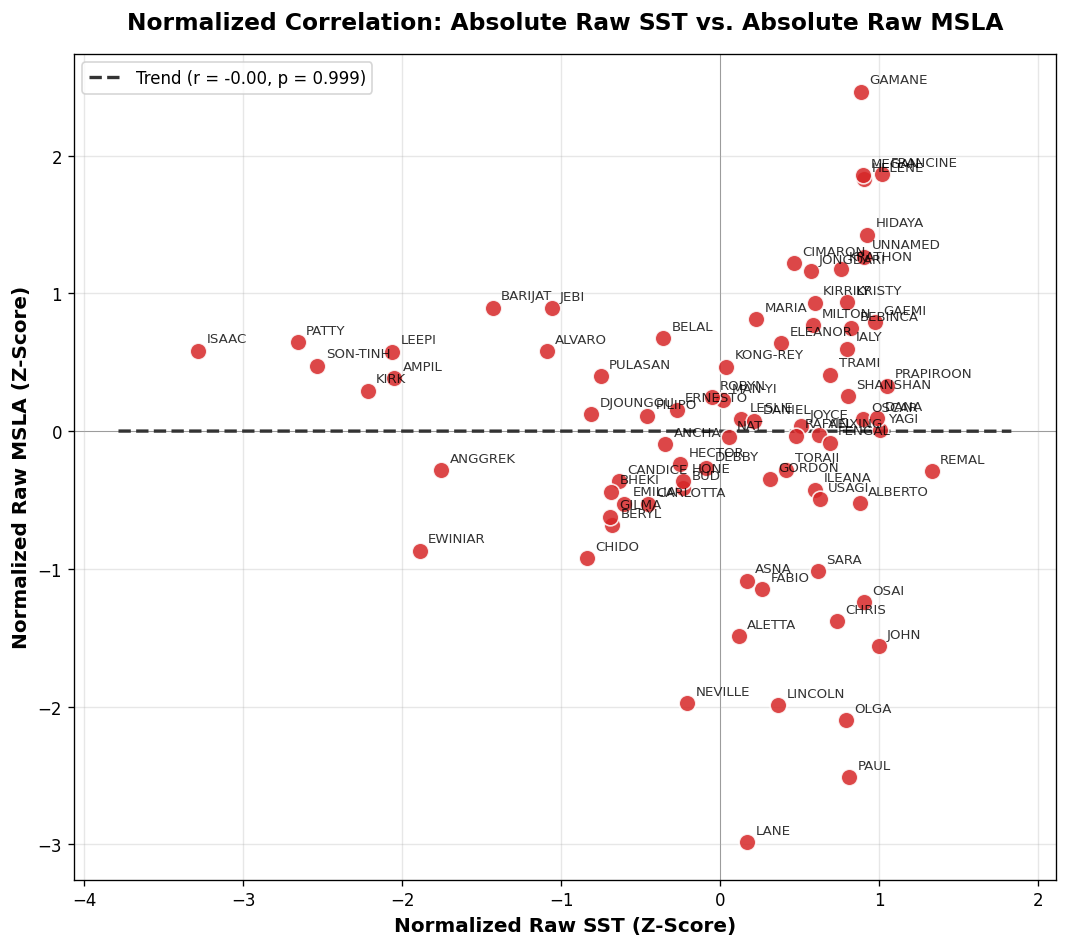

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

print("Calculating absolute raw means over analysis windows for all cyclones (this may take a minute)...\n")

raw_records = []

for cyc_name, cyc in cyclones.items():
    print(f"  {cyc_name}...", end=" ")
    bbox = _make_square_bbox(cyc.get('bbox', {}), cyc.get('track', []))
    peak_date = _get_peak_date(cyc)
    
    if not peak_date:
        print("Skipped (no peak date)")
        continue
        
    windows = _get_analysis_window_ranges(cyc)
    if not windows:
        print("Skipped (no window)")
        continue
        
    _, start_str, end_str = windows[-1]
    date_list = _get_analysis_date_list_from_range(start_str, end_str)

    sst_vals, msla_vals = [], []
    for date in date_list:
        # Load raw data
        sst_raw = load_sst_for_date(date, bbox)
        if sst_raw is not None:
            sst_vals.append(np.nanmean(sst_raw))
            
        msla_raw = load_msla_for_date(date, bbox)
        if msla_raw is not None:
            msla_vals.append(np.nanmean(msla_raw))
            
    sst_mean = np.nanmean(sst_vals) if sst_vals else np.nan
    msla_mean = np.nanmean(msla_vals) if msla_vals else np.nan
    
    raw_records.append({
        'Cyclone': cyc_name,
        'Peak_Date': str(peak_date),
        'SST_Raw': sst_mean,
        'MSLA_Raw': msla_mean
    })
    print("Done")

df_raw = pd.DataFrame(raw_records)
df_raw['Peak_Date'] = pd.to_datetime(df_raw['Peak_Date'])

print("\nFinished building raw dataset!")


# =============================================================================
# Plotting function mimicking `plot_msla_anomaly` exactly
# =============================================================================

def plot_raw_stem_chart(df, column, ylabel, title, save_name, is_msla=False):
    valid = df.dropna(subset=[column, 'Peak_Date']).copy()
    valid = valid.sort_values('Peak_Date')

    if valid.empty:
        print(f"No data for {column}.")
        return

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd', 'P', '8']

    fig, ax = plt.subplots(figsize=(14, 6))

    # Because absolute temperatures are ~28C (not zero), we draw the baseline
    # at the overall global average of the dataset so stems go up and down.
    overall_mean = valid[column].mean()
    ax.axhline(overall_mean, color='gray', linewidth=0.8, linestyle='--', zorder=1, label=f'Annual Baseline ({overall_mean:.2f})')

    for _, row in valid.iterrows():
        ax.plot([row['Peak_Date'], row['Peak_Date']],
                [overall_mean, row[column]],
                color='#cccccc', linewidth=0.8, zorder=2)

    for i, (_, row) in enumerate(valid.iterrows()):
        
        # Color logic: green/purple for MSLA, red/blue for SST based on relation to the mean
        if is_msla:
            c = '#2ca02c' if row[column] >= overall_mean else '#9467bd'
            yoff = 0.0003
        else:
            c = '#d62728' if row[column] >= overall_mean else '#1f77b4'
            yoff = 0.004
            
        ax.scatter(row['Peak_Date'], row[column],
                   marker=markers[i % len(markers)],
                   color=c, s=80, zorder=4,
                   edgecolors='white', linewidths=0.5)

        direct_yoff = 10 if row[column] >= overall_mean else -12
        ax.annotate(row['Cyclone'],
                    xy=(row['Peak_Date'], row[column]),
                    xytext=(0, direct_yoff),
                    textcoords='offset points',
                    ha='center', fontsize=6.5, color='#333333',
                    rotation=45,
                    arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.5))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate(rotation=45)

    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.25)
    
    if is_msla:
         handles = [Patch(color='#2ca02c', label='Above Global Mean (+)'),
                    Patch(color='#9467bd', label='Below Global Mean (−)')]
    else:
         handles = [Patch(color='#d62728', label='Warm Background (+)'),
                    Patch(color='#1f77b4', label='Cold Background (−)')]
         
    ax.legend(handles=handles, fontsize=9, framealpha=0.9, loc='best')

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

# =============================================================================
# Run Plots!
# =============================================================================
# plot_raw_stem_chart(df_raw, 'SST_Raw', 'Absolute Raw SST (°C)', 'Mean Absolute Raw SST per Cyclone vs. Peak Date', 'Raw_SST_vs_Date.png', is_msla=False)
# plot_raw_stem_chart(df_raw, 'MSLA_Raw', 'Absolute Raw MSLA (m)', 'Mean Absolute Raw MSLA per Cyclone vs. Peak Date', 'Raw_MSLA_vs_Date.png', is_msla=True)
# Insert this below the 'Run Plots!' section in cell 29

def plot_raw_correlation(df, save_name='Raw_Correlation_SST_vs_MSLA.png'):
    valid = df.dropna(subset=['SST_Raw', 'MSLA_Raw', 'Cyclone']).copy()
    if valid.empty:
         print("No valid data to correlate.")
         return
         
    # 1. Z-Score normalization
    valid['SST_Z'] = (valid['SST_Raw'] - valid['SST_Raw'].mean()) / valid['SST_Raw'].std()
    valid['MSLA_Z'] = (valid['MSLA_Raw'] - valid['MSLA_Raw'].mean()) / valid['MSLA_Raw'].std()

    # 2. Setup Figure
    fig, ax = plt.subplots(figsize=(9, 8))
    
    # 3. Compute Pearson
    r, p = pearsonr(valid['SST_Z'], valid['MSLA_Z'])
    
    # 4. Scatter Plot
    ax.scatter(valid['SST_Z'], valid['MSLA_Z'], 
               color='#d62728', edgecolor='white', s=100, zorder=3, alpha=0.85)

    # 5. Trendline
    m, b = np.polyfit(valid['SST_Z'], valid['MSLA_Z'], 1)
    x_range = np.linspace(valid['SST_Z'].min()-0.5, valid['SST_Z'].max()+0.5, 100)
    ax.plot(x_range, m*x_range + b, color='#333333', linewidth=2, linestyle='--',
            label=f'Trend (r = {r:.2f}, p = {p:.3f})', zorder=2)
            
    # 6. Annotations (Cyclone Names)
    for i, row in valid.iterrows():
       ax.annotate(row['Cyclone'],
                   (row['SST_Z'], row['MSLA_Z']),
                   textcoords="offset points",
                   xytext=(5, 5),
                   ha='left',
                   fontsize=8,
                   alpha=0.8)

    # 7. Formatting
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, zorder=1)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, zorder=1)
    
    ax.set_xlabel('Normalized Raw SST (Z-Score)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Raw MSLA (Z-Score)', fontsize=12, fontweight='bold')
    ax.set_title('Normalized Correlation: Absolute Raw SST vs. Absolute Raw MSLA', fontsize=14, fontweight='bold', pad=15)
    
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    # plt.show()

# Run the correlation plot
# plot_raw_correlation(df_raw, save_name='Raw_Correlation_SST_vs_MSLA.png')




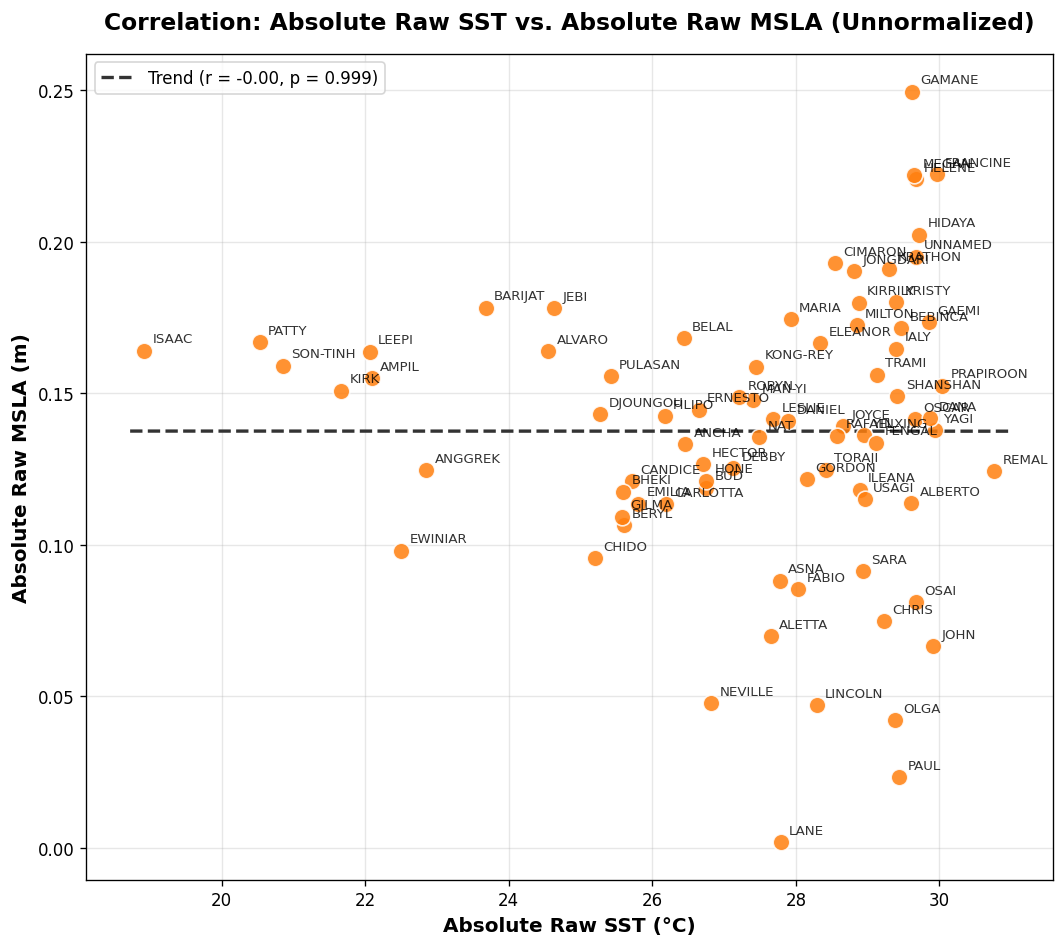

In [ ]:

def plot_raw_correlation_absolute(df, save_name='Raw_Correlation_Absolute_SST_vs_MSLA.png'):
    valid = df.dropna(subset=['SST_Raw', 'MSLA_Raw', 'Cyclone']).copy()
    if valid.empty:
         print("No valid data to correlate.")
         return
         
    # Setup Figure
    fig, ax = plt.subplots(figsize=(9, 8))
    
    # Compute Pearson Correlation on absolute values
    r, p = pearsonr(valid['SST_Raw'], valid['MSLA_Raw'])
    
    # Scatter Plot
    ax.scatter(valid['SST_Raw'], valid['MSLA_Raw'], 
               color='#ff7f0e', edgecolor='white', s=100, zorder=3, alpha=0.85)

    # Trendline
    m, b = np.polyfit(valid['SST_Raw'], valid['MSLA_Raw'], 1)
    
    # Create x-range slightly wider than data to draw trendline nicely
    x_min, x_max = valid['SST_Raw'].min(), valid['SST_Raw'].max()
    x_range = np.linspace(x_min - 0.2, x_max + 0.2, 100)
    
    ax.plot(x_range, m * x_range + b, color='#333333', linewidth=2, linestyle='--',
            label=f'Trend (r = {r:.2f}, p = {p:.3f})', zorder=2)
            
    # Annotations (Cyclone Names)
    for i, row in valid.iterrows():
       ax.annotate(row['Cyclone'],
                   (row['SST_Raw'], row['MSLA_Raw']),
                   textcoords="offset points",
                   xytext=(5, 5),
                   ha='left',
                   fontsize=8,
                   alpha=0.8)

    # Formatting
    ax.set_xlabel('Absolute Raw SST (°C)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Absolute Raw MSLA (m)', fontsize=12, fontweight='bold')
    ax.set_title('Correlation: Absolute Raw SST vs. Absolute Raw MSLA (Unnormalized)', fontsize=14, fontweight='bold', pad=15)
    
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

# Run the absolute correlation plot
# plot_raw_correlation_absolute(df_raw, save_name='Raw_Correlation_Absolute_SST_vs_MSLA.png')

Saved: SST_Anomaly_vs_Date.png


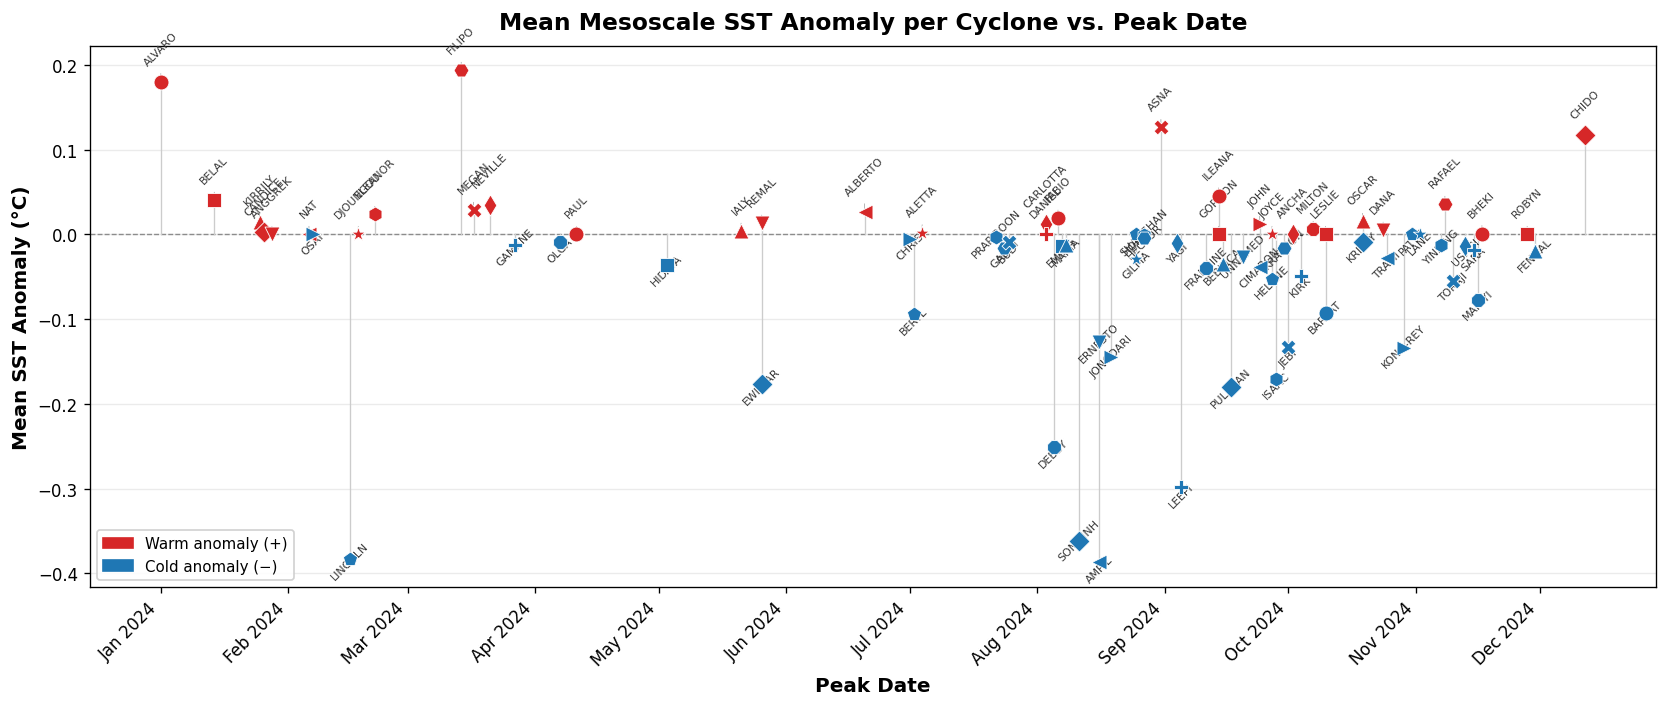

Saved: MSLA_Anomaly_vs_Date.png


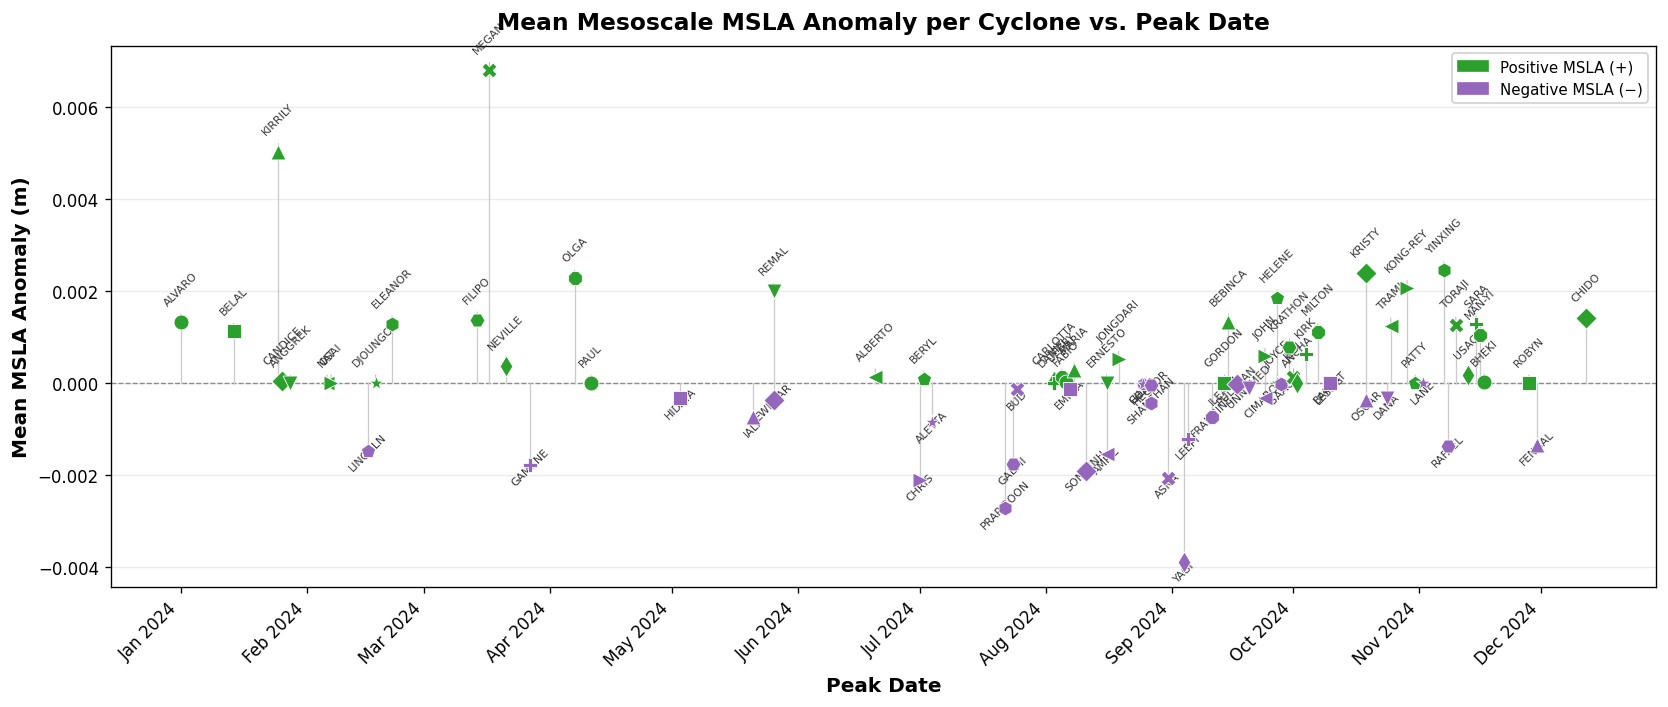

Saved: SST_MSLA_Correlation.png


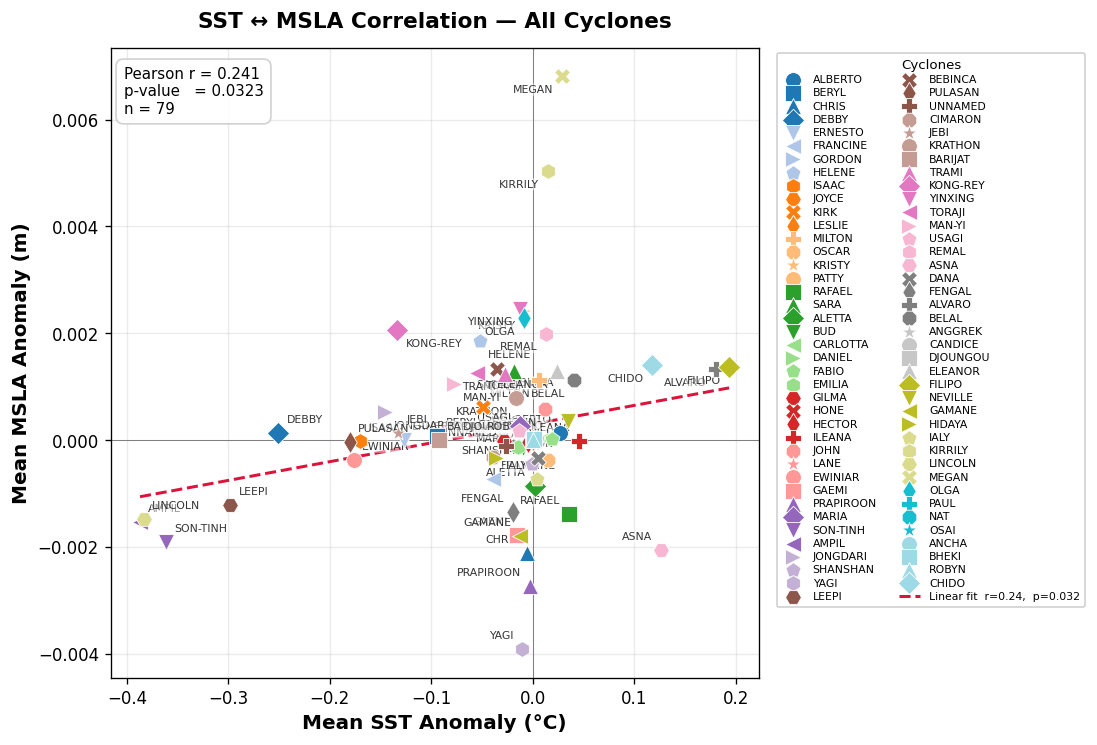

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr


# =============================================================================
# STEP 1 — Compute simple mean SST & MSLA anomaly per cyclone
# =============================================================================

def _get_peak_date(cyc):
    """
    Returns a datetime.date for the cyclone peak.
    Priority:
      1. dates['peak']
      2. midpoint(formation, dissipation)
      3. midpoint of analysis window
    """
    dates = cyc.get('dates', {})
    if dates.get('peak'):
        return pd.to_datetime(dates['peak']).date()
    if dates.get('formation') and dates.get('dissipation'):
        t0 = pd.to_datetime(dates['formation'])
        t1 = pd.to_datetime(dates['dissipation'])
        return (t0 + (t1 - t0) / 2).date()
    windows = _get_analysis_window_ranges(cyc)
    if windows:
        _, s, e = windows[-1]
        t0, t1 = pd.to_datetime(s), pd.to_datetime(e)
        return (t0 + (t1 - t0) / 2).date()
    return None


def calculate_cyclone_anomalies_mean(cyclones_dict,
                                     output_csv='cyclone_anomalies_mean.csv'):
    """
    One row per cyclone.
    SST_Anomaly  = nanmean of daily meso-scale SST  over the analysis window.
    MSLA_Anomaly = nanmean of daily meso-scale MSLA over the analysis window.
    Peak_Date    = formation/dissipation midpoint (or explicit 'peak' key).
    """
    records = []

    for cyc_name, cyc in cyclones_dict.items():
        print(f"  {cyc_name} ...", end=' ', flush=True)

        bbox  = cyc.get('bbox')
        track = cyc.get('track')
        if not bbox or not track:
            print("skipped (no bbox/track)"); continue

        bbox      = _make_square_bbox(bbox, track)
        peak_date = _get_peak_date(cyc)
        if peak_date is None:
            print("skipped (no peak date)"); continue

        windows = _get_analysis_window_ranges(cyc)
        if not windows:
            print("skipped (no analysis window)"); continue

        _, start_str, end_str = windows[-1]
        date_list = _get_analysis_date_list_from_range(start_str, end_str)

        sst_vals, msla_vals = [], []

        for date in date_list:
            # SST
            sst_raw = load_sst_for_date(date, bbox)
            if sst_raw is not None:
                dec = decompose_sst_field(sst_raw)
                if dec and 'meso' in dec:
                    sst_vals.append(np.nanmean(dec['meso']))

            # MSLA
            msla_raw = load_msla_for_date(date, bbox)
            if msla_raw is not None:
                dec = decompose_msla_field(msla_raw)
                if dec and 'meso' in dec:
                    msla_vals.append(np.nanmean(dec['meso']))

        sst_mean  = np.nanmean(sst_vals)  if sst_vals  else np.nan
        msla_mean = np.nanmean(msla_vals) if msla_vals else np.nan

        d = cyc.get('dates', {})
        records.append({
            'Cyclone'     : cyc_name,
            'Peak_Date'   : str(peak_date),
            'Formation'   : d.get('formation', ''),
            'Dissipation' : d.get('dissipation', ''),
            'SST_Anomaly' : sst_mean,
            'MSLA_Anomaly': msla_mean,
        })
        print(f"SST={sst_mean:.4f}  MSLA={msla_mean:.5f}")

    df = pd.DataFrame(records)
    if not df.empty:
        df['Peak_Date'] = pd.to_datetime(df['Peak_Date'])
        df.to_csv(output_csv, index=False)
        print(f"\nSaved → {output_csv}")
    return df


# =============================================================================
# STEP 2 — Plot SST Anomaly  (x = Peak Date, y = SST Anomaly)
# =============================================================================

def plot_sst_anomaly(df, save=True):
    """
    One marker per cyclone.  X = peak date, Y = mean SST anomaly (°C).
    Markers coloured red (warm) / blue (cold).  Cyclone name annotated.
    """
    valid = df.dropna(subset=['SST_Anomaly', 'Peak_Date']).copy()
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])
    valid = valid.sort_values('Peak_Date')

    if valid.empty:
        print("No SST data."); return

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h',
               'H', 'X', 'd', 'P', '8']
    colors  = ['#d62728' if v >= 0 else '#1f77b4'
               for v in valid['SST_Anomaly']]

    fig, ax = plt.subplots(figsize=(14, 6))

    # zero line
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)

    # vertical stems
    for _, row in valid.iterrows():
        ax.plot([row['Peak_Date'], row['Peak_Date']],
                [0, row['SST_Anomaly']],
                color='#cccccc', linewidth=0.8, zorder=2)

    # markers + value labels
    for i, (_, row) in enumerate(valid.iterrows()):
        c = '#d62728' if row['SST_Anomaly'] >= 0 else '#1f77b4'
        ax.scatter(row['Peak_Date'], row['SST_Anomaly'],
                   marker=markers[i % len(markers)],
                   color=c, s=80, zorder=4,
                   edgecolors='white', linewidths=0.5)

        # cyclone name
        yoff = 0.004 if row['SST_Anomaly'] >= 0 else -0.004
        ax.annotate(row['Cyclone'],
                    xy=(row['Peak_Date'], row['SST_Anomaly']),
                    xytext=(0, 10 if row['SST_Anomaly'] >= 0 else -12),
                    textcoords='offset points',
                    ha='center', fontsize=6.5, color='#333333',
                    rotation=45,
                    arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.5))

        # numeric label
        # ax.text(row['Peak_Date'], row['SST_Anomaly'] + yoff * 8,
        #         f"{row['SST_Anomaly']:.3f}",
        #         ha='center', va='bottom' if row['SST_Anomaly'] >= 0 else 'top',
        #         fontsize=6, color='#444444')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate(rotation=45)

    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean SST Anomaly (°C)', fontsize=12, fontweight='bold')
    ax.set_title('Mean Mesoscale SST Anomaly per Cyclone vs. Peak Date',
                 fontsize=14, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.25)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#d62728', label='Warm anomaly (+)'),
                        Patch(color='#1f77b4', label='Cold anomaly (−)')],
              fontsize=9, framealpha=0.9, loc='best')

    plt.tight_layout()
    if save:
        plt.savefig('SST_Anomaly_vs_Date.png', dpi=150, bbox_inches='tight')
        print("Saved: SST_Anomaly_vs_Date.png")
    plt.show()


# =============================================================================
# STEP 3 — Plot MSLA Anomaly  (x = Peak Date, y = MSLA Anomaly)
# =============================================================================

def plot_msla_anomaly(df, save=True):
    """
    One marker per cyclone.  X = peak date, Y = mean MSLA anomaly (m).
    """
    valid = df.dropna(subset=['MSLA_Anomaly', 'Peak_Date']).copy()
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])
    valid = valid.sort_values('Peak_Date')

    if valid.empty:
        print("No MSLA data."); return

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h',
               'H', 'X', 'd', 'P', '8']

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)

    for _, row in valid.iterrows():
        ax.plot([row['Peak_Date'], row['Peak_Date']],
                [0, row['MSLA_Anomaly']],
                color='#cccccc', linewidth=0.8, zorder=2)

    for i, (_, row) in enumerate(valid.iterrows()):
        c = '#2ca02c' if row['MSLA_Anomaly'] >= 0 else '#9467bd'
        ax.scatter(row['Peak_Date'], row['MSLA_Anomaly'],
                   marker=markers[i % len(markers)],
                   color=c, s=80, zorder=4,
                   edgecolors='white', linewidths=0.5)

        ax.annotate(row['Cyclone'],
                    xy=(row['Peak_Date'], row['MSLA_Anomaly']),
                    xytext=(0, 10 if row['MSLA_Anomaly'] >= 0 else -12),
                    textcoords='offset points',
                    ha='center', fontsize=6.5, color='#333333',
                    rotation=45,
                    arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.5))

        yoff = 0.0003 if row['MSLA_Anomaly'] >= 0 else -0.0003
        # ax.text(row['Peak_Date'], row['MSLA_Anomaly'] + yoff * 8,
        #         f"{row['MSLA_Anomaly']:.4f}",
        #         ha='center', va='bottom' if row['MSLA_Anomaly'] >= 0 else 'top',
        #         fontsize=6, color='#444444')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate(rotation=45)

    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean MSLA Anomaly (m)', fontsize=12, fontweight='bold')
    ax.set_title('Mean Mesoscale MSLA Anomaly per Cyclone vs. Peak Date',
                 fontsize=14, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.25)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#2ca02c', label='Positive MSLA (+)'),
                        Patch(color='#9467bd', label='Negative MSLA (−)')],
              fontsize=9, framealpha=0.9, loc='best')

    plt.tight_layout()
    if save:
        plt.savefig('MSLA_Anomaly_vs_Date.png', dpi=150, bbox_inches='tight')
        print("Saved: MSLA_Anomaly_vs_Date.png")
    plt.show()


# =============================================================================
# STEP 4 — Correlation  (x = SST, y = MSLA, one point per cyclone)
# =============================================================================

def plot_anomaly_correlation(df, save=True):
    """
    Scatter of SST vs MSLA mean anomaly across all cyclones,
    with regression line and Pearson r / p-value annotation.
    """
    # Note: Using column names from user's snippet. Ensure these exist in your DataFrame.
    # If using the multiscale CSV, you might need to rename columns or map them here.
    col_x = 'SST_Anomaly'
    col_y = 'MSLA_Anomaly'
    
    if col_x not in df.columns or col_y not in df.columns:
        # Fallback to Meso-scale if user's names aren't found
        col_x, col_y = 'SST_Meso', 'MSLA_Meso'

    valid = df.dropna(subset=[col_x, col_y]).copy()
    if valid.empty:
        print("No paired data."); return

    sst  = valid[col_x].values
    msla = valid[col_y].values
    corr, pval = pearsonr(sst, msla)

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', 'H',
               'X', 'd', 'P', '8', '*']
    
    # Modern colormap lookup
    cmap = plt.get_cmap('tab20', len(valid))

    fig, ax = plt.subplots(figsize=(9, 7))

    # Calculate midpoints for intelligent annotation placement
    x_mid = np.mean(sst)
    y_mid = np.mean(msla)

    for i, (_, row) in enumerate(valid.iterrows()):
        x, y = row[col_x], row[col_y]
        ax.scatter(x, y,
                   marker=markers[i % len(markers)],
                   color=cmap(i), s=90, zorder=4,
                   edgecolors='white', linewidths=0.5,
                   label=row['Cyclone'])
        
        # --- START MODIFIED ANNOTATION LOGIC ---
        # Adjust text position based on location relative to height/width center
        # This prevents labels from going out of plot bounds.
        x_off = 5 if x < x_mid else -5
        y_off = 5 if y < y_mid else -5
        ha = 'left' if x_off > 0 else 'right'
        va = 'bottom' if y_off > 0 else 'top'

        ax.annotate(row['Cyclone'],
                    xy=(x, y),
                    xytext=(x_off, y_off), textcoords='offset points',
                    ha=ha, va=va,
                    fontsize=6.5, color='#333333',
                    bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none', alpha=0.5))
        # --- END MODIFIED ANNOTATION LOGIC ---

    # regression
    m, b   = np.polyfit(sst, msla, 1)
    xs     = np.linspace(sst.min(), sst.max(), 200)
    ax.plot(xs, m * xs + b, color='crimson', linestyle='--',
            linewidth=1.8, label=f'Linear fit  r={corr:.2f},  p={pval:.3f}')

    ax.axhline(0, color='gray', linewidth=0.6)
    ax.axvline(0, color='gray', linewidth=0.6)

    ax.set_xlabel('Mean SST Anomaly (°C)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean MSLA Anomaly (m)',  fontsize=12, fontweight='bold')
    ax.set_title('SST ↔ MSLA Correlation — All Cyclones',
                 fontsize=13, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.25)

    # legend outside to the right in two columns
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0),
              fontsize=6.5, framealpha=0.9, ncol=2, 
              title="Cyclones", title_fontsize=8,
              labelspacing=0.3, borderpad=0.5)

    ax.text(0.02, 0.97,
            f'Pearson r = {corr:.3f}\np-value   = {pval:.4f}\nn = {len(valid)}',
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

    # Manual adjustment to prevent "Tight layout" warnings and accommodate the 2-column legend
    plt.subplots_adjust(left=0.1, right=0.7, top=0.9, bottom=0.15)
    if save:
        plt.savefig('SST_MSLA_Correlation.png', dpi=150, bbox_inches='tight')
        print("Saved: SST_MSLA_Correlation.png")
    plt.show()


# =============================================================================
# RUNNER  (uncomment to execute)
# =============================================================================

# -- compute once (slow) ---
# df_anom = calculate_cyclone_anomalies_mean(cyclones)

# -- or reload saved CSV --
# df_anom = pd.read_csv('cyclone_anomalies_mean.csv')

# # -- plot --
# plot_sst_anomaly(df_anom)
# plot_msla_anomaly(df_anom)
# plot_anomaly_correlation(df_anom)


Saved: SST_Large_vs_Date.png


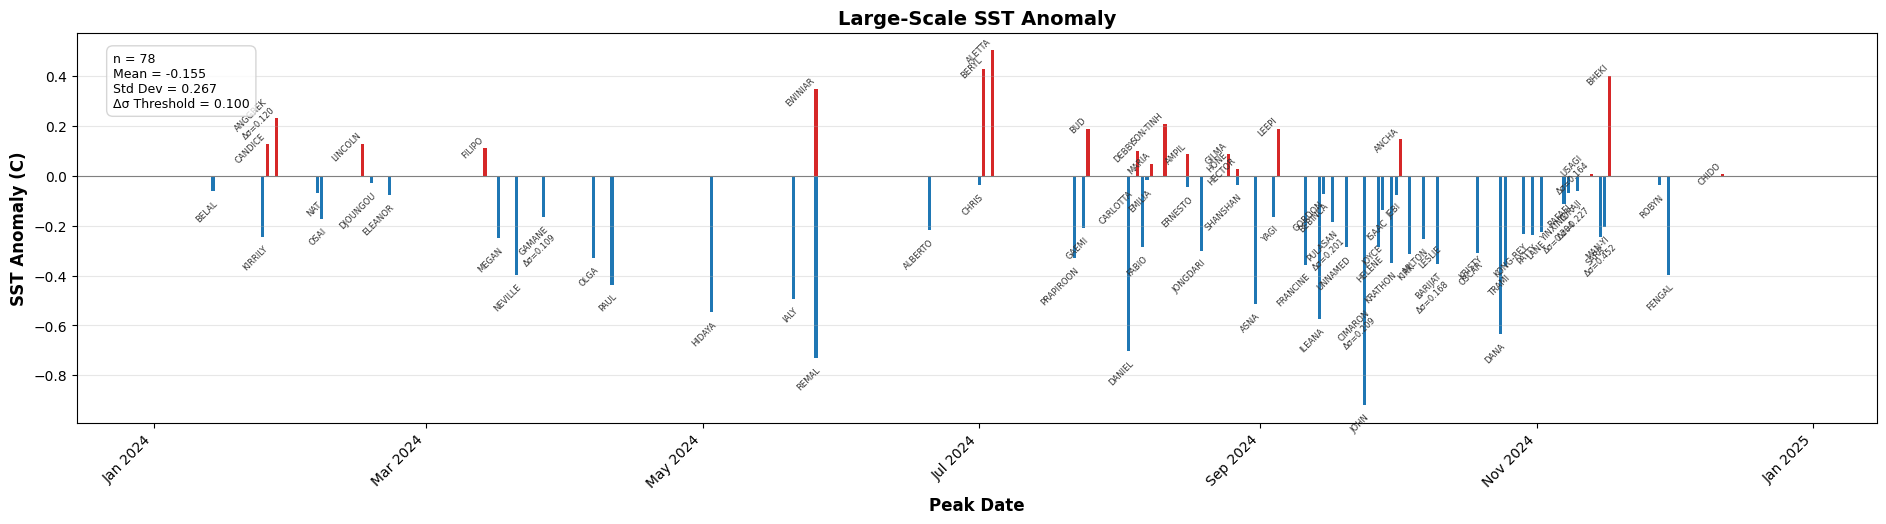

Saved: SST_Meso_vs_Date.png


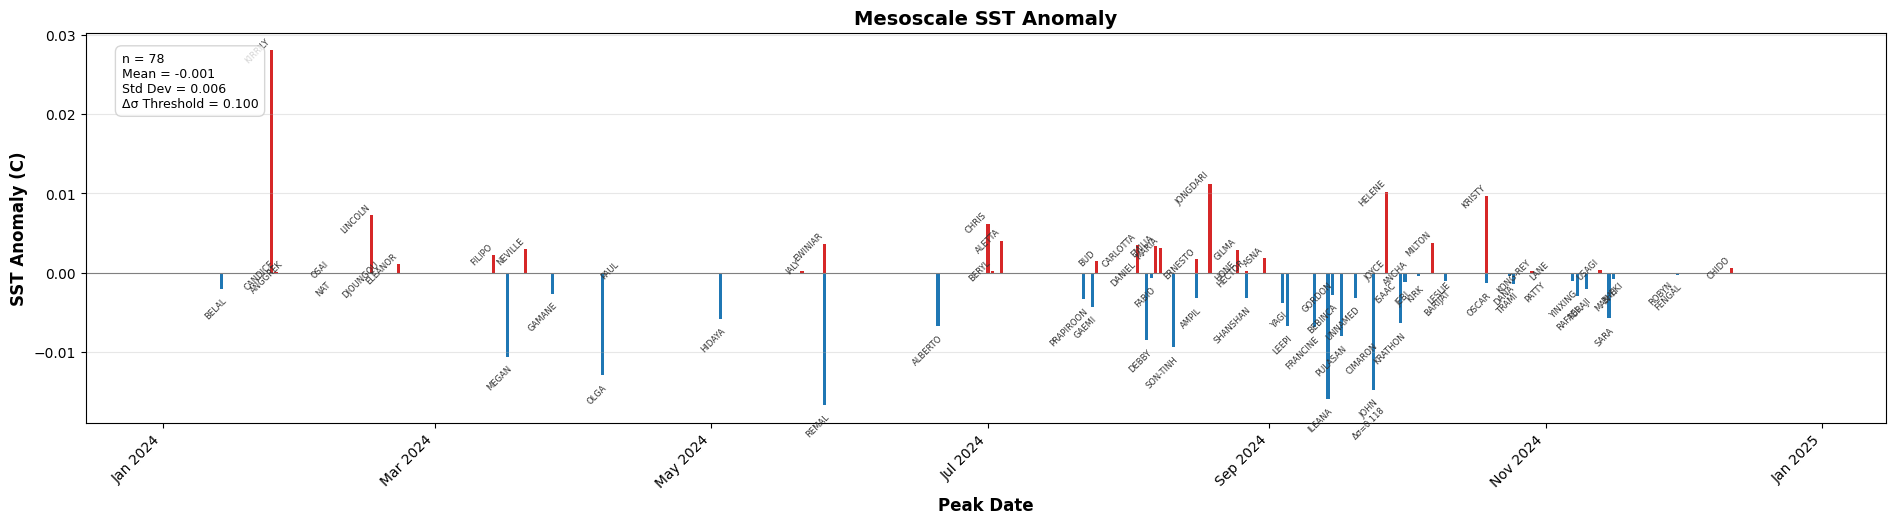

Saved: SST_Submeso_vs_Date.png


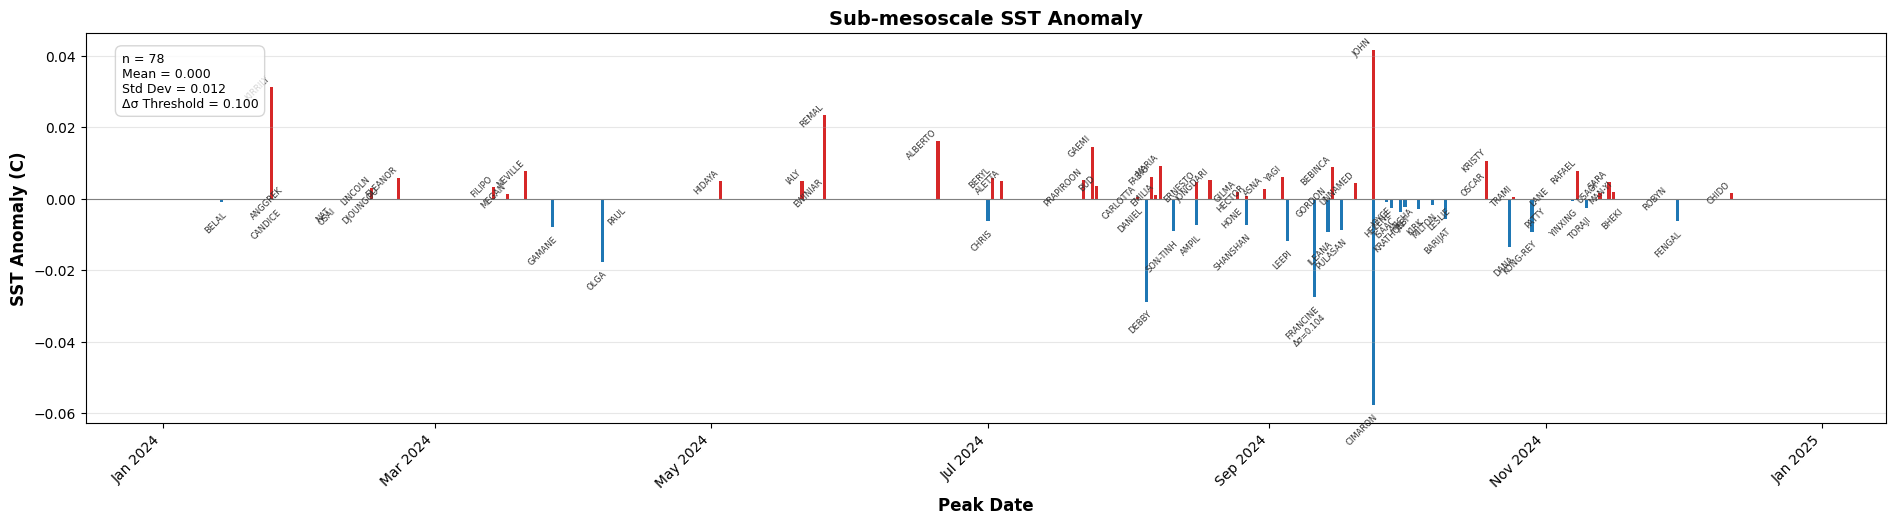

Saved: MSLA_Large_vs_Date.png


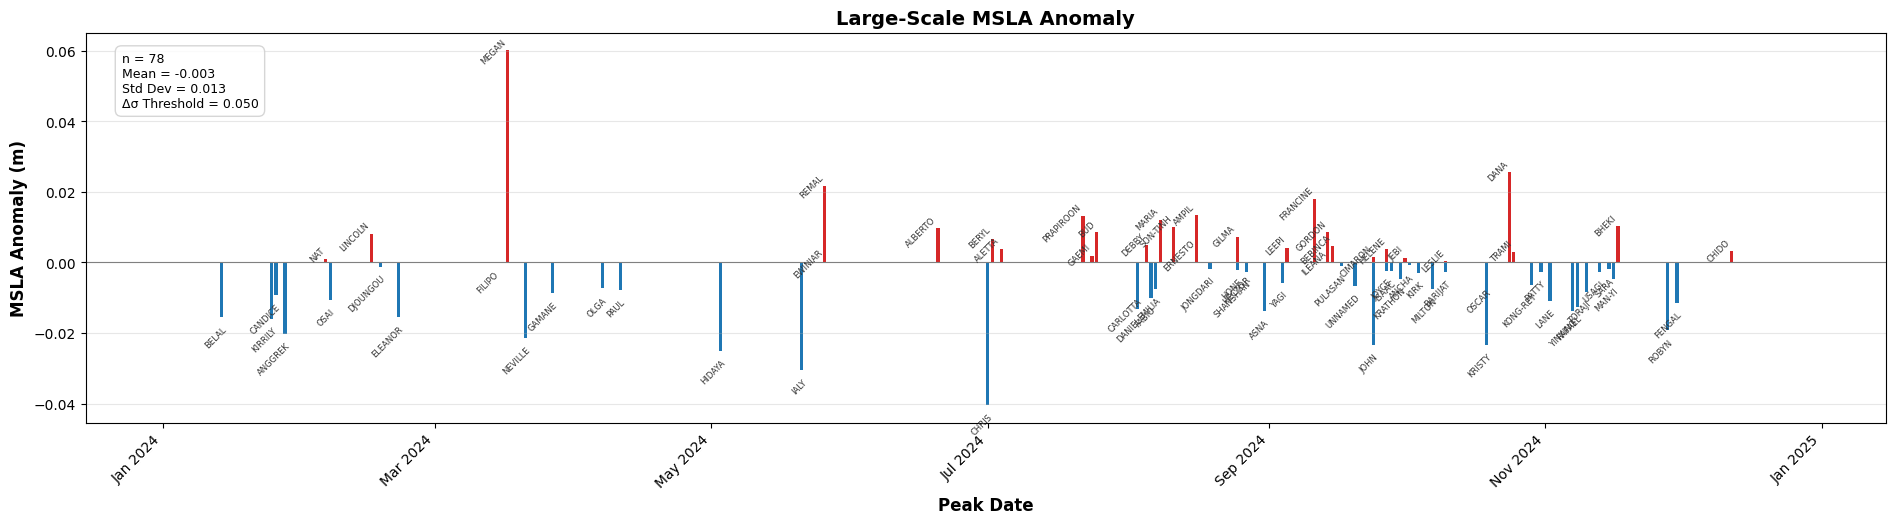

Saved: MSLA_Meso_vs_Date.png


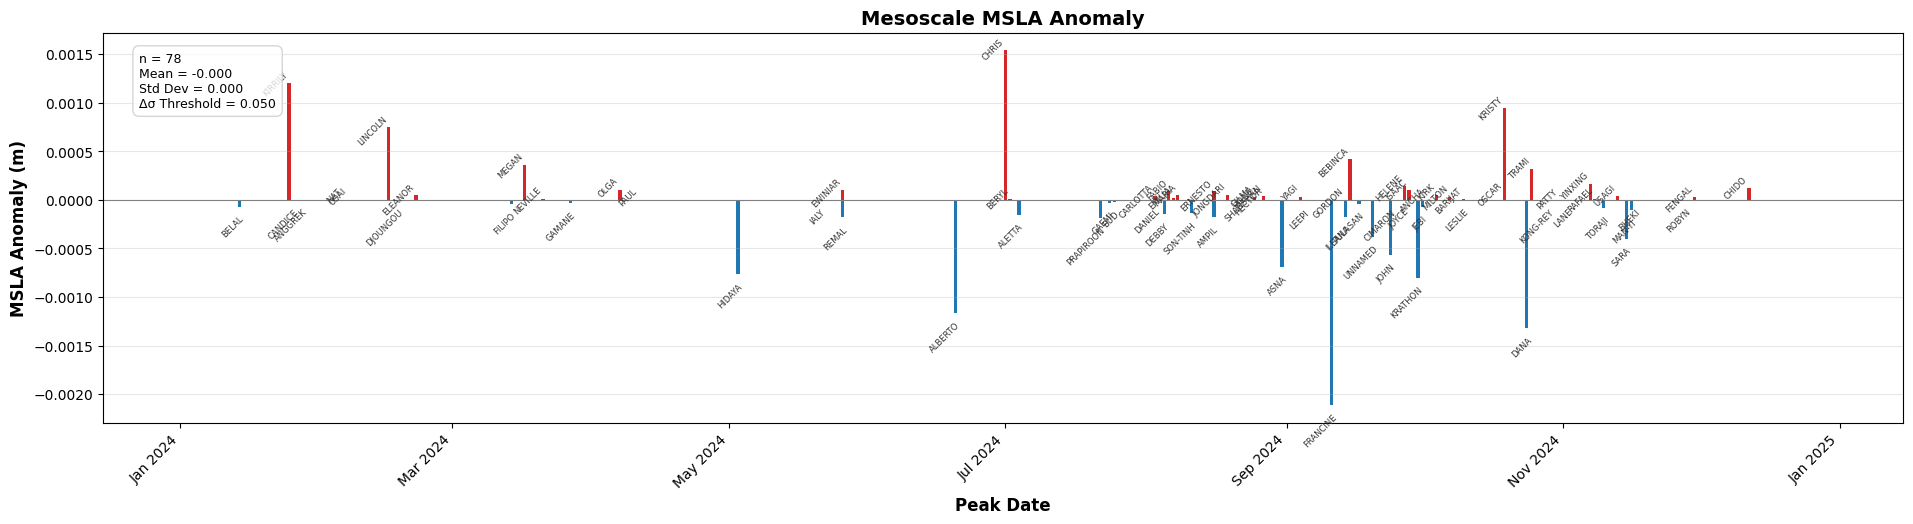

Saved: MSLA_Submeso_vs_Date.png


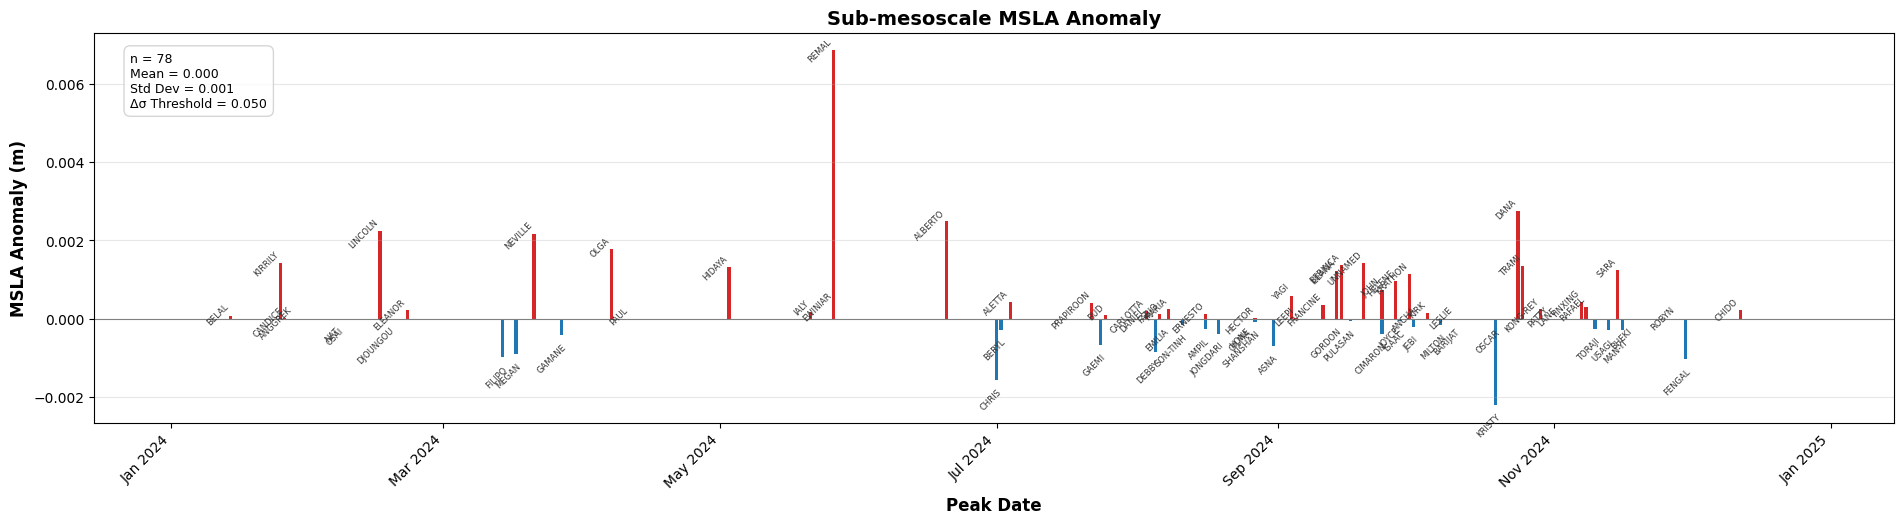

Saved: SST_Large_Seasonal.png


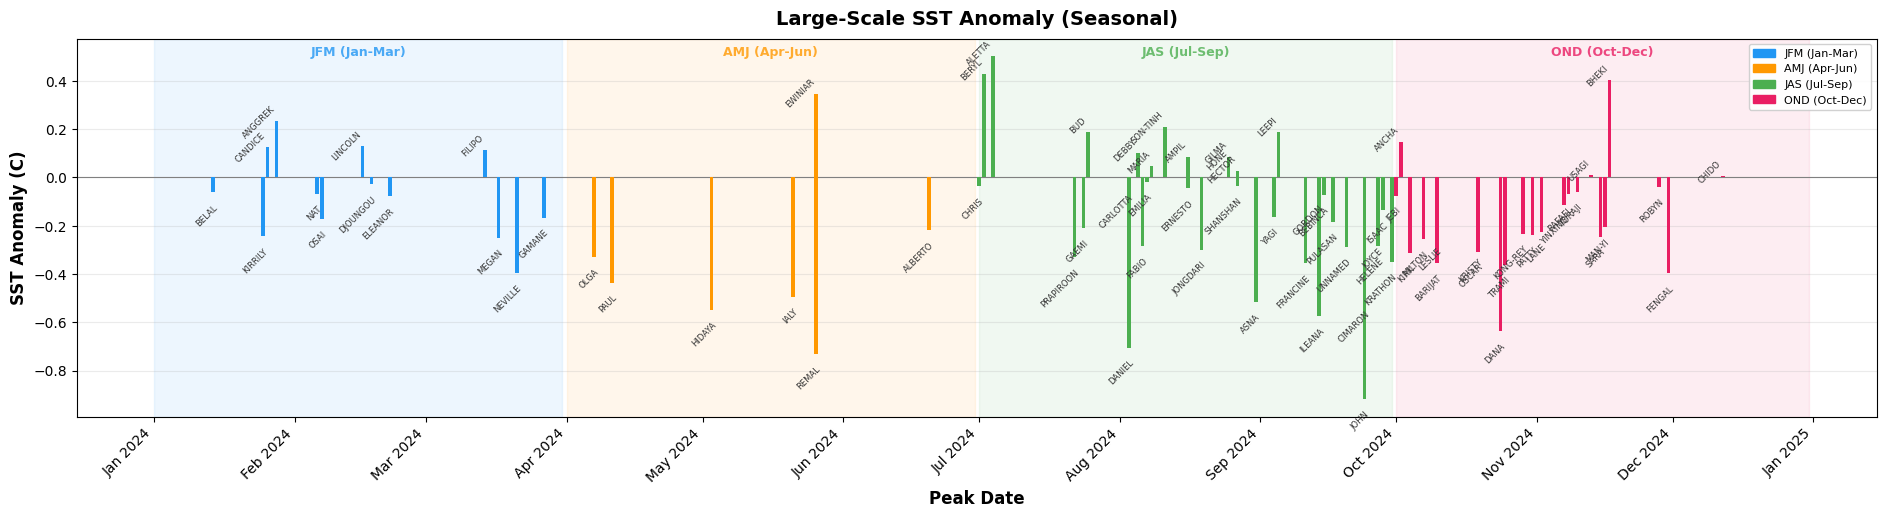

Saved: SST_Meso_Seasonal.png


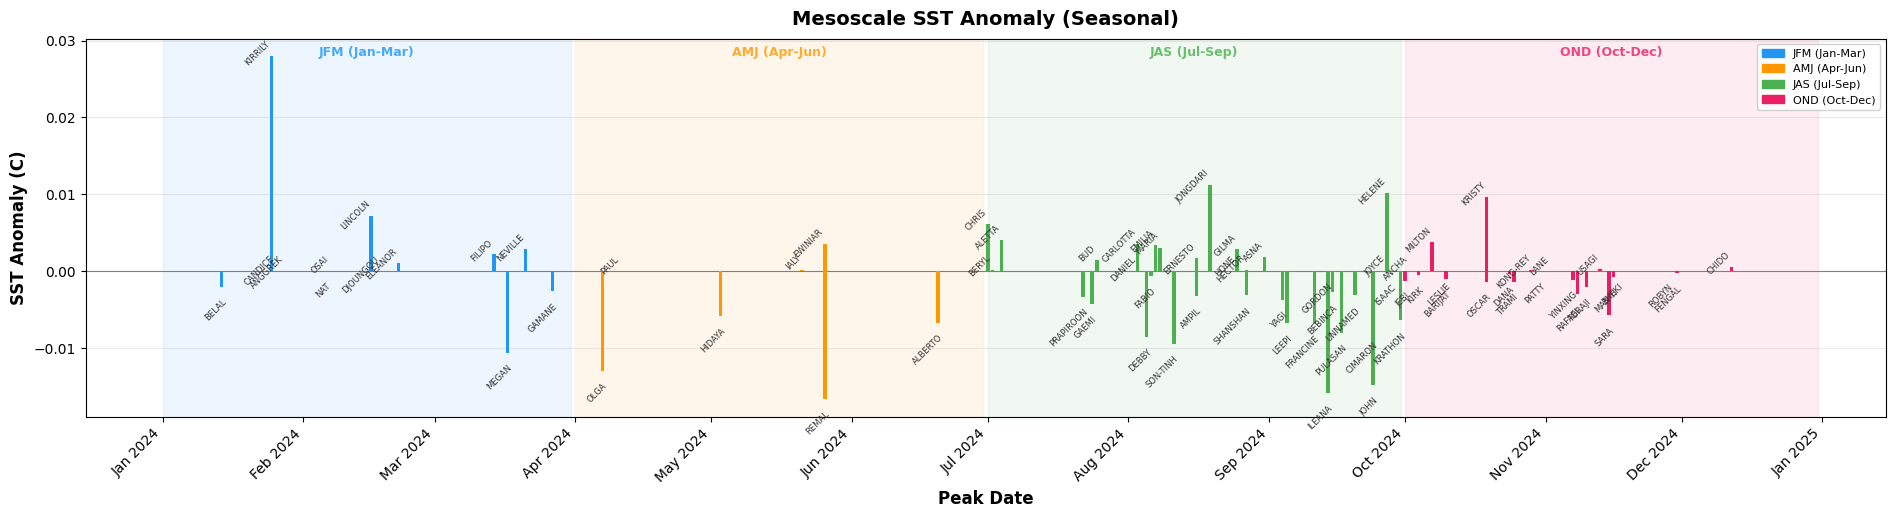

Saved: SST_Submeso_Seasonal.png


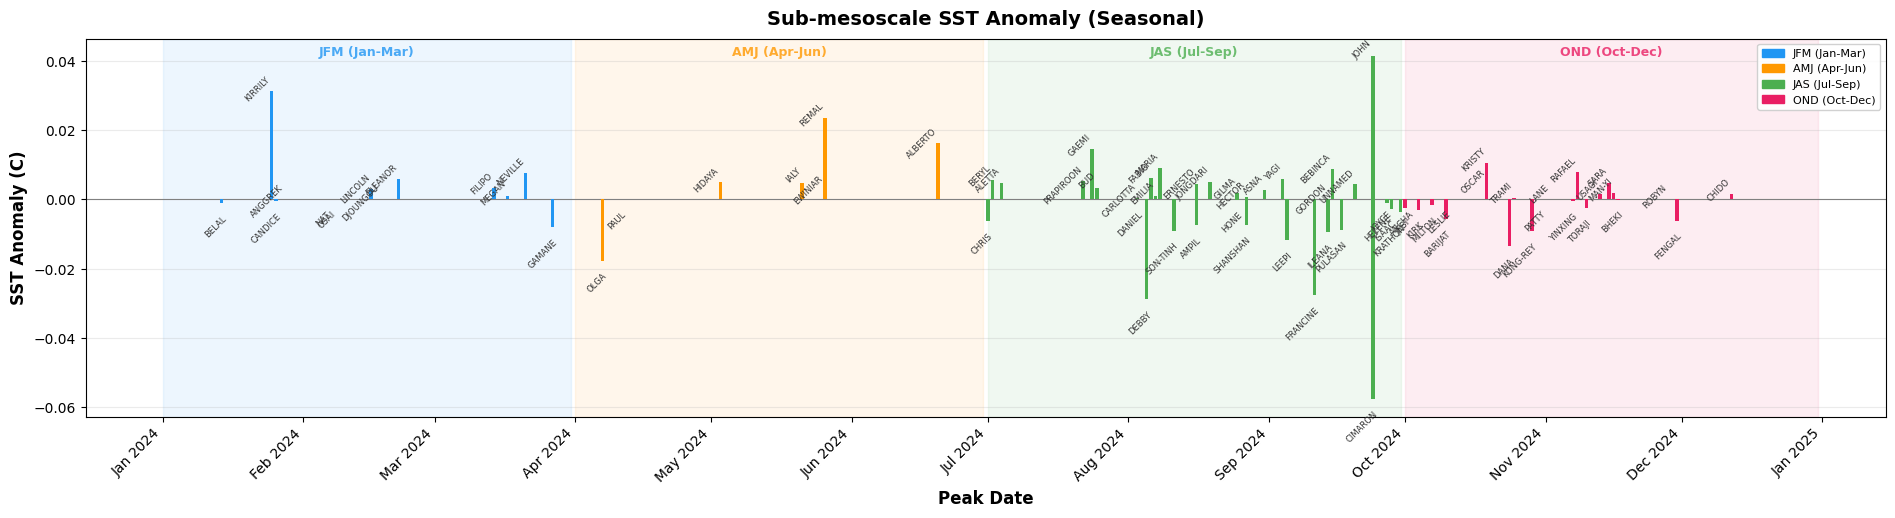

Saved: MSLA_Large_Seasonal.png


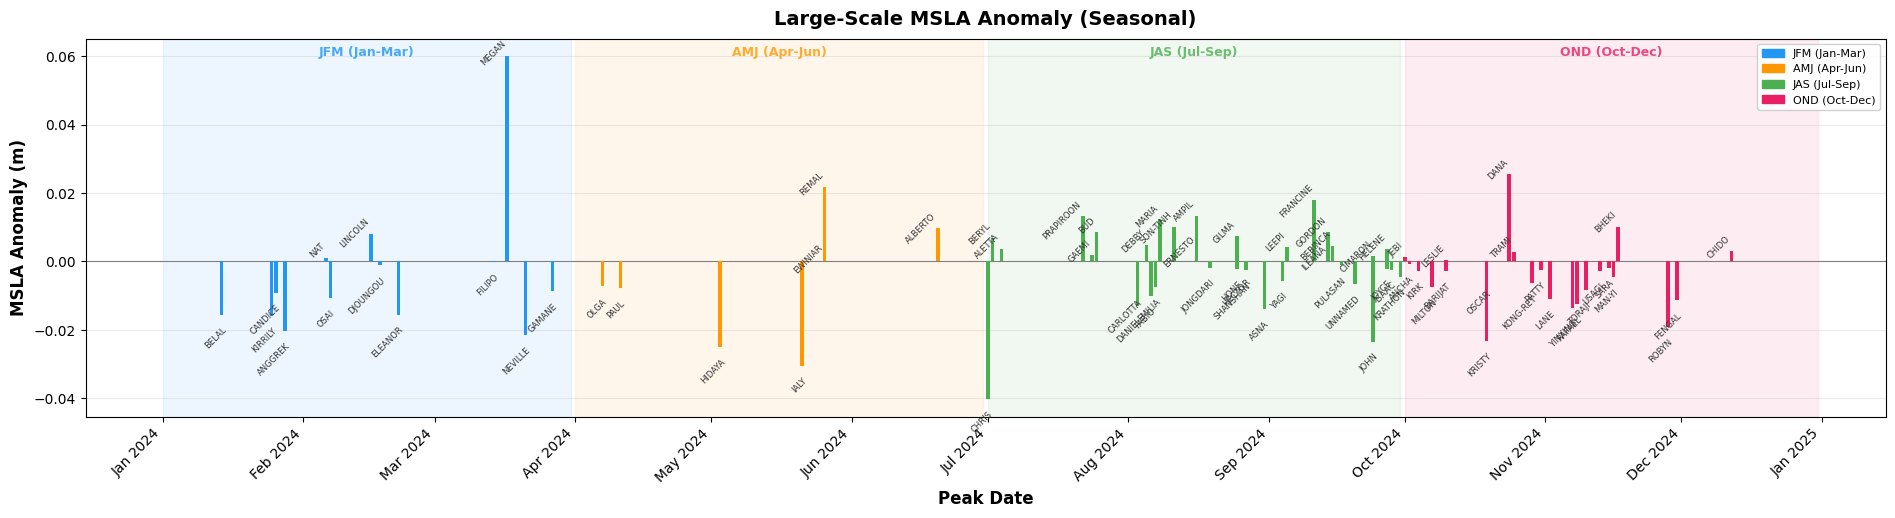

Saved: MSLA_Meso_Seasonal.png


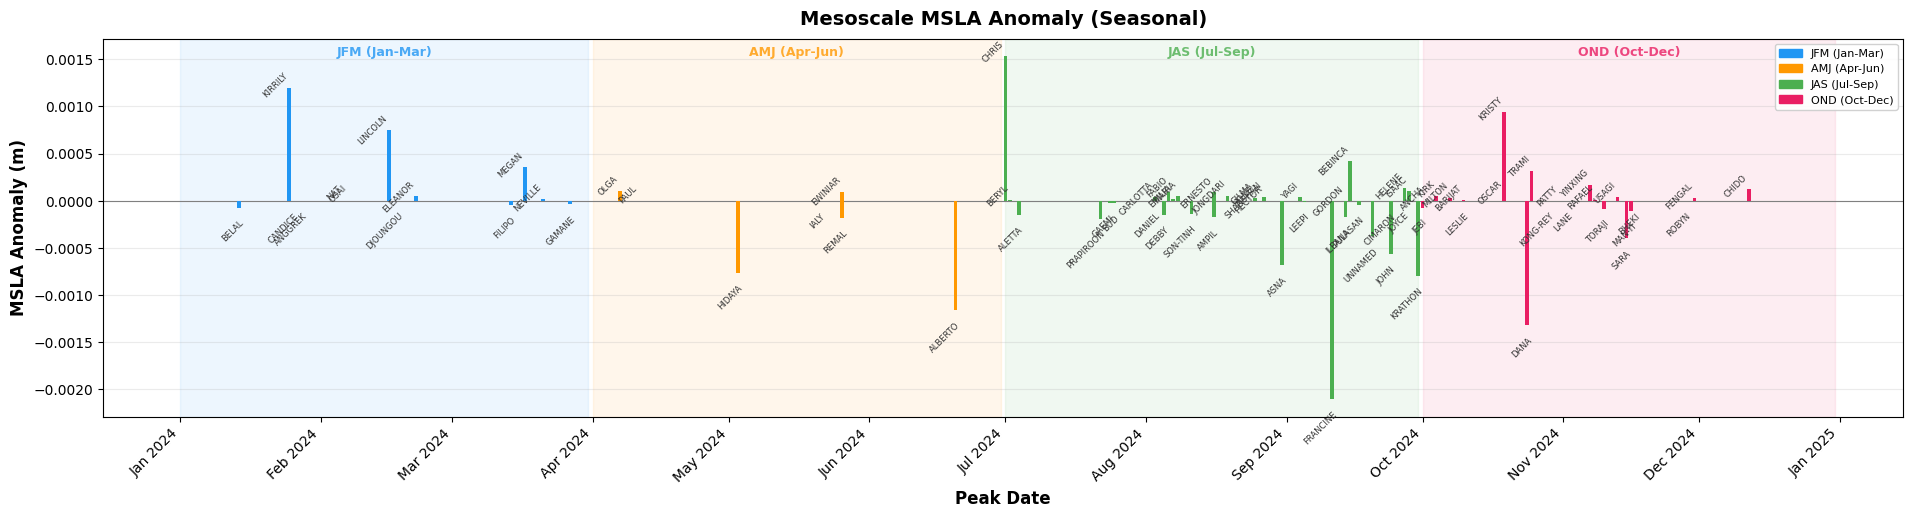

Saved: MSLA_Submeso_Seasonal.png


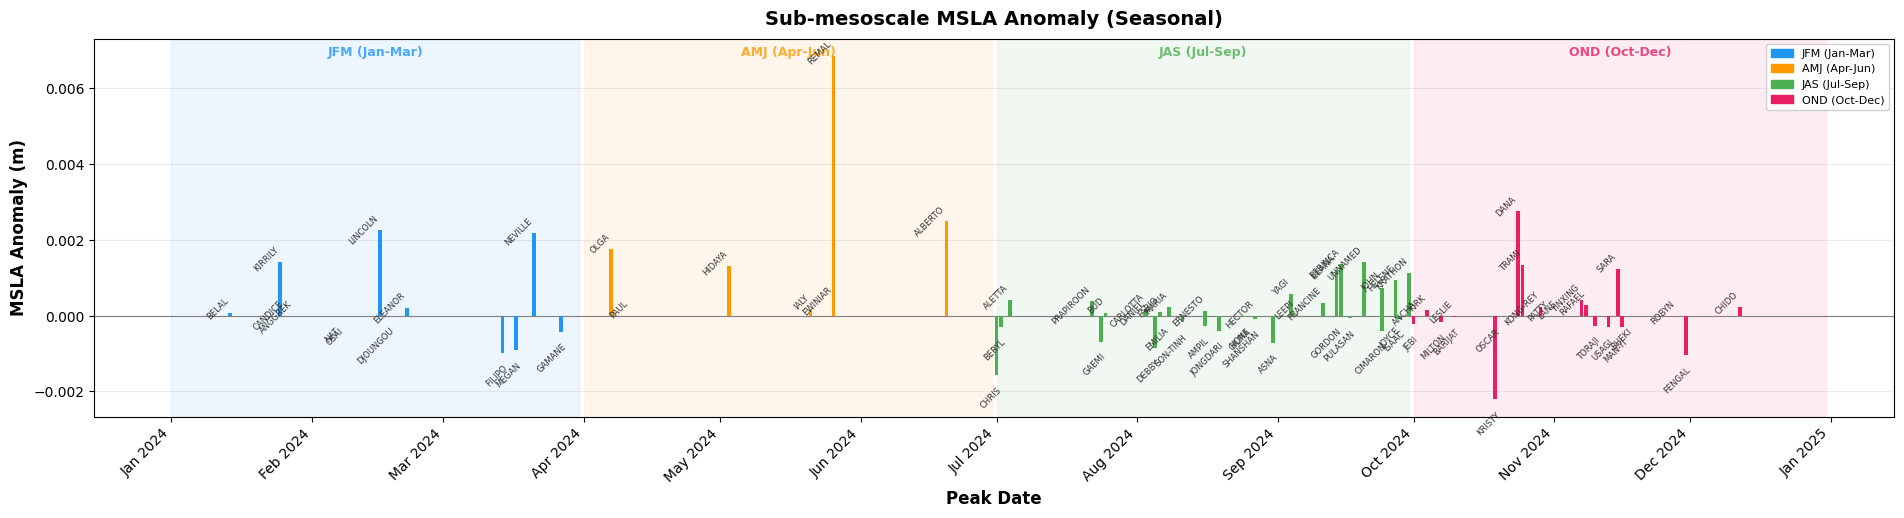

Saved: SST_Seasonal_Summary.png


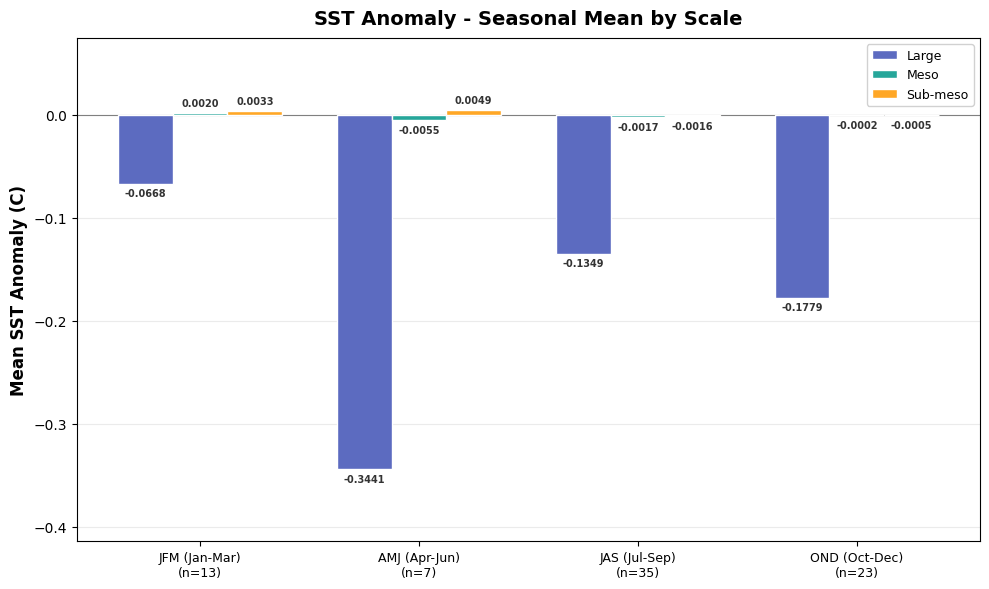

Saved: MSLA_Seasonal_Summary.png


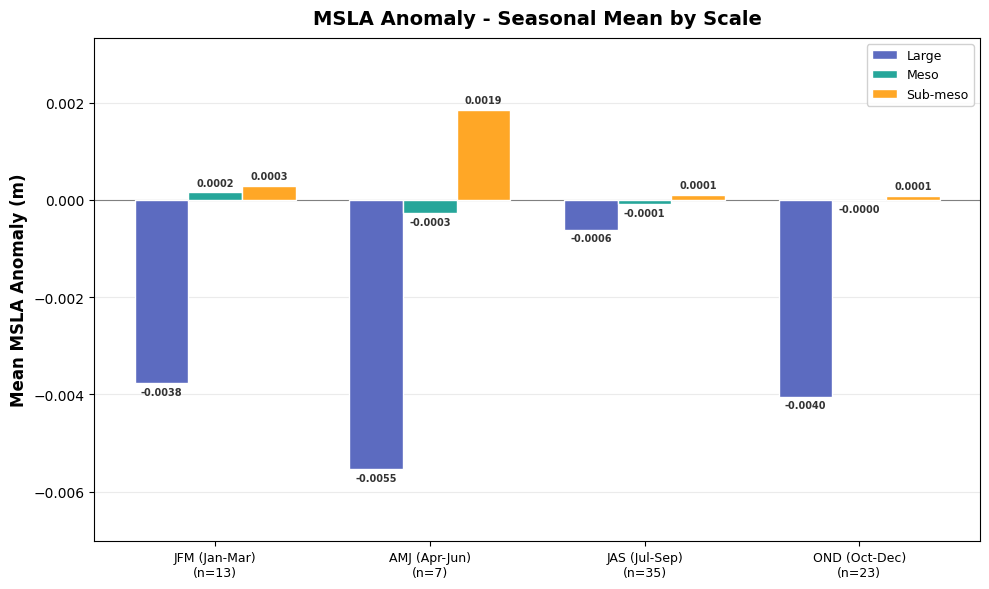

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os

def _bar_plot_abs_per_date(df, col, title, y_label, save_name, save=True, std_threshold=None):
    """
    Plots the absolute magnitude of the anomaly for each cyclone across the timeline.
    Colors bars red for original warm (positive) anomalies and blue for cold (negative).
    """
    if col not in df.columns:
        print(f"No data for {col}")
        return

    # Check if the corresponding std column exists
    std_col = f"{col}_Std"
    has_std = std_col in df.columns

    # Keep only rows with valid anomaly/std/date values
    if has_std:
        valid = df.dropna(subset=[col, std_col, 'Peak_Date']).copy()
    else:
        valid = df.dropna(subset=[col, 'Peak_Date']).copy()

    if valid.empty:
        print(f"No data for {col}")
        return

    # Ensure dates are datetime
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])

    # Sort chronologically
    valid = valid.sort_values('Peak_Date')

    # Color bars
    colors = ['#d62728' if v >= 0 else '#1f77b4' for v in valid[col]]

    # Absolute values for plotting
    abs_vals = valid[col].abs()

    # Figure size
    fig_width = min(20, max(12, len(valid) * 0.4))
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    # Plot bars
    bars = ax.bar(
        valid['Peak_Date'],
        abs_vals,
        color=colors,
        edgecolor=None,
        linewidth=0,
        width=0.7
    )

    # Zero line
    ax.axhline(0, color='gray', linewidth=0.8, zorder=2)

    # Titles and labels
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')

    # Date formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    if len(valid) <= 12:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

    # Restrict timeline
    ax.set_xlim([
        pd.to_datetime('2023-12-15'),
        pd.to_datetime('2025-01-15')
    ])

    fig.autofmt_xdate(rotation=45)

    ax.grid(axis='y', alpha=0.3)

    # Offset for labels
    ymin, ymax = abs_vals.min(), abs_vals.max()
    offset = 0.02 * (ymax - ymin) if ymax != ymin else 0.01

    # Legend for Warm/Cold
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d62728', label='Warm (Original > 0)'),
        Patch(facecolor='#1f77b4', label='Cold (Original < 0)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # ============================================================
    # STD THRESHOLD
    # ============================================================
    actual_std_threshold = (
        std_threshold
        if std_threshold is not None
        else valid[std_col].mean() if has_std else 0
    )

    # ============================================================
    # BAR ANNOTATIONS
    # ============================================================
    for i, (bar, name) in enumerate(zip(bars, valid['Cyclone'])):
        height = bar.get_height()

        # Standard deviation anomaly text
        std_text = ""
        if has_std:
            std_val = valid[std_col].iloc[i]
            if std_val > actual_std_threshold:
                std_text = f"\nΔσ={std_val:.3f}"

        annot_text = f"{name}{std_text}"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            annot_text,
            ha='right',
            va='bottom',
            fontsize=6,
            rotation=45,
            rotation_mode='anchor',
            color='#333333'
        )

    # ============================================================
    # STATISTICS BOX
    # ============================================================
    col_mean = valid[col].mean()
    col_std = valid[col].std()
    
    # We show the original data stats (mean and std) but can add abs mean
    abs_mean = abs_vals.mean()

    stats_text = (
        f"n = {len(valid)}\n"
        f"Original Mean = {col_mean:.3f}\n"
        f"Original Std = {col_std:.3f}\n"
        f"Abs Mean = {abs_mean:.3f}"
    )

    if has_std:
        stats_text += f"\nΔσ Threshold = {actual_std_threshold:.3f}"

    ax.text(
        0.02,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round,pad=0.5',
            facecolor='white',
            alpha=0.8,
            edgecolor='#cccccc'
        )
    )

    # Layout adjustment
    plt.subplots_adjust(
        bottom=0.25,
        top=0.9,
        left=0.08,
        right=0.98
    )

    # Save figure
    if save:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_name}")

    plt.close(fig)

def plot_submeso_abs(df):
    scales = [
        ('SST_Submeso', 'Sub-mesoscale SST Absolute Anomaly Magnitude', 'Absolute SST Anomaly (°C)', 0.10),
        ('MSLA_Submeso', 'Sub-mesoscale MSLA Absolute Anomaly Magnitude', 'Absolute MSLA Anomaly (m)', 0.05)
    ]
    for col, title, y_label, std_thresh in scales:
        _bar_plot_abs_per_date(df, col, title, y_label, f"{col}_Abs_vs_Date.png", save=True, std_threshold=std_thresh)

if __name__ == '__main__':
    csv_file = 'cyclone_multiscale_anomalies.csv'
    if not os.path.exists(csv_file):
        print(f"Error: {csv_file} not found.")
    else:
        df = pd.read_csv(csv_file)
        plot_submeso_abs(df)


Saved: SST_Submeso_Abs_vs_Date.png


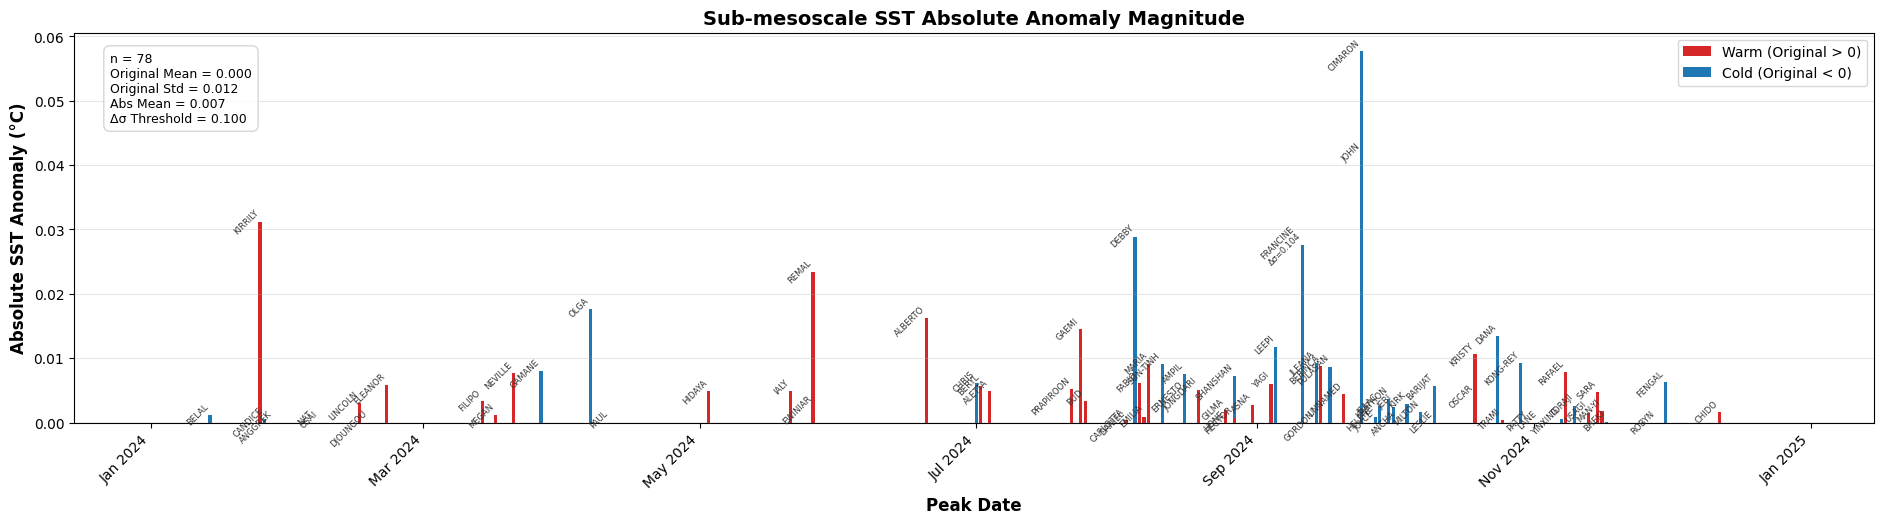

Saved: MSLA_Submeso_Abs_vs_Date.png


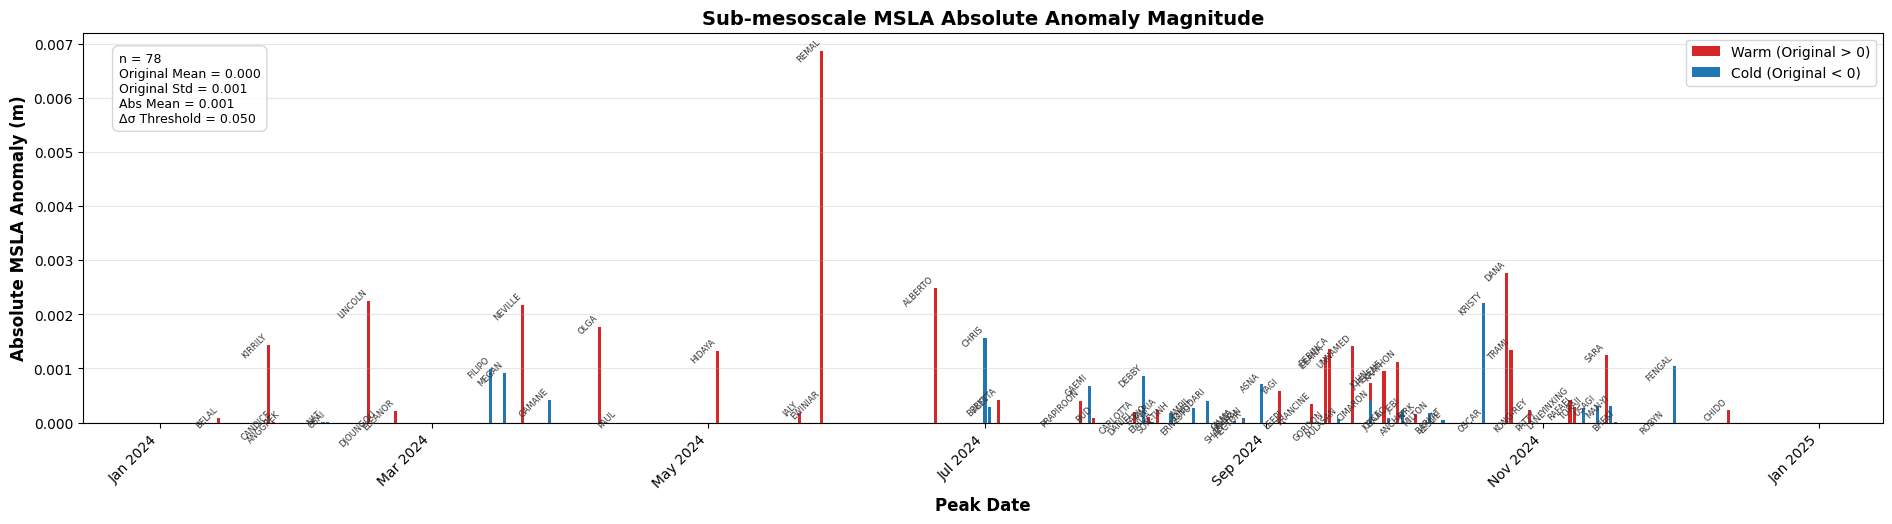

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os

def _bar_plot_abs_per_date(df, col, title, y_label, save_name, save=True, std_threshold=None):
    """
    Plots the absolute magnitude of the anomaly for each cyclone across the timeline.
    Colors bars red for original warm (positive) anomalies and blue for cold (negative).
    """
    if col not in df.columns:
        print(f"No data for {col}")
        return

    # Check if the corresponding std column exists
    std_col = f"{col}_Std"
    has_std = std_col in df.columns

    # Keep only rows with valid anomaly/std/date values
    if has_std:
        valid = df.dropna(subset=[col, std_col, 'Peak_Date']).copy()
    else:
        valid = df.dropna(subset=[col, 'Peak_Date']).copy()

    if valid.empty:
        print(f"No data for {col}")
        return

    # Ensure dates are datetime
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])

    # Sort chronologically
    valid = valid.sort_values('Peak_Date')

    # Color bars
    colors = ['#d62728' if v >= 0 else '#1f77b4' for v in valid[col]]

    # Absolute values for plotting
    abs_vals = valid[col].abs()

    # Figure size
    fig_width = min(20, max(12, len(valid) * 0.4))
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    # Plot bars
    bars = ax.bar(
        valid['Peak_Date'],
        abs_vals,
        color=colors,
        edgecolor=None,
        linewidth=0,
        width=0.7
    )

    # Zero line
    ax.axhline(0, color='gray', linewidth=0.8, zorder=2)

    # Titles and labels
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')

    # Date formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    if len(valid) <= 12:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

    # Restrict timeline
    ax.set_xlim([
        pd.to_datetime('2023-12-15'),
        pd.to_datetime('2025-01-15')
    ])

    fig.autofmt_xdate(rotation=45)

    ax.grid(axis='y', alpha=0.3)

    # Offset for labels
    ymin, ymax = abs_vals.min(), abs_vals.max()
    offset = 0.02 * (ymax - ymin) if ymax != ymin else 0.01

    # Legend for Warm/Cold
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d62728', label='Warm (Original > 0)'),
        Patch(facecolor='#1f77b4', label='Cold (Original < 0)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # ============================================================
    # STD THRESHOLD
    # ============================================================
    actual_std_threshold = (
        std_threshold
        if std_threshold is not None
        else valid[std_col].mean() if has_std else 0
    )

    # ============================================================
    # BAR ANNOTATIONS
    # ============================================================
    for i, (bar, name) in enumerate(zip(bars, valid['Cyclone'])):
        height = bar.get_height()

        # Standard deviation anomaly text
        std_text = ""
        if has_std:
            std_val = valid[std_col].iloc[i]
            if std_val > actual_std_threshold:
                std_text = f"\nΔσ={std_val:.3f}"

        annot_text = f"{name}{std_text}"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            annot_text,
            ha='right',
            va='bottom',
            fontsize=6,
            rotation=45,
            rotation_mode='anchor',
            color='#333333'
        )

    # ============================================================
    # STATISTICS BOX
    # ============================================================
    col_mean = valid[col].mean()
    col_std = valid[col].std()
    
    # We show the original data stats (mean and std) but can add abs mean
    abs_mean = abs_vals.mean()

    stats_text = (
        f"n = {len(valid)}\n"
        f"Original Mean = {col_mean:.3f}\n"
        f"Original Std = {col_std:.3f}\n"
        f"Abs Mean = {abs_mean:.3f}"
    )

    if has_std:
        stats_text += f"\nΔσ Threshold = {actual_std_threshold:.3f}"

    ax.text(
        0.02,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round,pad=0.5',
            facecolor='white',
            alpha=0.8,
            edgecolor='#cccccc'
        )
    )

    # Layout adjustment
    plt.subplots_adjust(
        bottom=0.25,
        top=0.9,
        left=0.08,
        right=0.98
    )

    # Save figure
    if save:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_name}")
    plt.show()
    plt.close(fig)

def plot_submeso_abs(df):
    scales = [
        ('SST_Submeso', 'Sub-mesoscale SST Absolute Anomaly Magnitude', 'Absolute SST Anomaly (°C)', 0.10),
        ('MSLA_Submeso', 'Sub-mesoscale MSLA Absolute Anomaly Magnitude', 'Absolute MSLA Anomaly (m)', 0.05)
    ]
    for col, title, y_label, std_thresh in scales:
        _bar_plot_abs_per_date(df, col, title, y_label, f"{col}_Abs_vs_Date.png", save=True, std_threshold=std_thresh)

if __name__ == '__main__':
    csv_file = 'cyclone_multiscale_anomalies.csv'
    if not os.path.exists(csv_file):
        print(f"Error: {csv_file} not found.")
    else:
        df = pd.read_csv(csv_file)
        plot_submeso_abs(df)


In [ ]:
import pandas as pd
import numpy as np
import json
import os
from cyclone_anomaly_analysis import (
    _get_peak_date, _make_square_bbox, _get_analysis_window_ranges,
    _get_analysis_date_list_from_range, load_sst_for_date, decompose_sst_field
)

def calculate_sst_submeso_gradients(cyclones_dict):
    records = []
    for cyc_name, cyc in cyclones_dict.items():
        print(f"Processing {cyc_name} ...", end=' ', flush=True)

        bbox = cyc.get('bbox')
        track = cyc.get('track')
        if not bbox or not track:
            print("skipped (no bbox/track)")
            continue

        bbox = _make_square_bbox(bbox, track)
        peak_date = _get_peak_date(cyc)
        if peak_date is None:
            print("skipped (no peak date)")
            continue

        windows = _get_analysis_window_ranges(cyc)
        if not windows:
            print("skipped (no analysis window)")
            continue

        # Target Signal (from During/Post window)
        _, start_str, end_str = windows[-1]
        date_list = _get_analysis_date_list_from_range(start_str, end_str)

        sst_sub_grad_vals = []
        ref_lat = (bbox['lat_min'] + bbox['lat_max']) / 2.0
        # SST grid resolution is 0.05 degrees
        dy_km = 111.0 * 0.05
        dx_km = 111.0 * np.cos(np.deg2rad(ref_lat)) * 0.05

        for date in date_list:
            sst_raw = load_sst_for_date(date, bbox)
            if sst_raw is not None:
                dec = decompose_sst_field(sst_raw)
                if dec and 'submeso' in dec:
                    submeso_field = dec['submeso']
                    # Compute gradient (axis 0 = lat/y, axis 1 = lon/x)
                    grad_y, grad_x = np.gradient(submeso_field)
                    
                    # Convert to physical units: degrees Celsius per km
                    grad_y_km = grad_y / dy_km
                    grad_x_km = grad_x / dx_km
                    
                    # Magnitude of the gradient
                    grad_mag = np.sqrt(grad_x_km**2 + grad_y_km**2)
                    
                    # Average over the region
                    mean_grad = np.nanmean(grad_mag)
                    sst_sub_grad_vals.append(mean_grad)

        if sst_sub_grad_vals:
            # Average over the dates
            mean_grad_for_cyc = np.nanmean(sst_sub_grad_vals)
            rec = {
                'Cyclone': cyc_name,
                'SST_Submeso_Grad_Avg': mean_grad_for_cyc
            }
            print(f"Grad={mean_grad_for_cyc:.5f} °C/km")
            records.append(rec)
        else:
            print("No data.")

    return pd.DataFrame(records)

# if __name__ == "__main__":
#     json_path = 'cyclone_info_2024_padded.json'
#     csv_file = 'cyclone_multiscale_anomalies.csv'
    
#     if os.path.exists(json_path) and os.path.exists(csv_file):
#         with open(json_path, 'r') as f:
#             raw_data = json.load(f)
            
#         CYCLONES = {}
#         for basin, b_data in raw_data.items():
#             for storm in b_data.get('storms', []):
#                 name = storm.get('name', '').upper()
#                 CYCLONES[name] = storm
            
#         grad_df = calculate_sst_submeso_gradients(CYCLONES)
        
#         # Merge with existing CSV
#         df = pd.read_csv(csv_file)
#         if 'SST_Submeso_Grad_Avg' in df.columns:
#             df = df.drop(columns=['SST_Submeso_Grad_Avg'])
            
#         df = pd.merge(df, grad_df, on='Cyclone', how='left')
#         df.to_csv(csv_file, index=False)
#         print(f"\nAppended SST_Submeso_Grad_Avg to {csv_file}")
#     else:
#         print("Missing json or csv file.")


Processing ALBERTO ... 

c:\Users\abhik\Desktop\project related work\cyclone_anomaly_analysis.py:99: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(files[0])
c:\Users\abhik\Desktop\project related work\cyclone_anomaly_analysis.py:99: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attrib

Grad=0.00243 °C/km
Processing BERYL ... 

c:\Users\abhik\Desktop\project related work\cyclone_anomaly_analysis.py:99: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(files[0])
c:\Users\abhik\Desktop\project related work\cyclone_anomaly_analysis.py:99: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attrib

Grad=0.00491 °C/km
Processing CHRIS ... 

...

Grad=0.00370 °C/km
Processing ROBYN ... 

c:\Users\abhik\Desktop\project related work\cyclone_anomaly_analysis.py:99: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(files[0])
c:\Users\abhik\Desktop\project related work\cyclone_anomaly_analysis.py:99: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attrib

Grad=0.00246 °C/km
Processing CHIDO ... 

c:\Users\abhik\Desktop\project related work\cyclone_anomaly_analysis.py:99: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(files[0])
c:\Users\abhik\Desktop\project related work\cyclone_anomaly_analysis.py:99: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attrib

Grad=0.00413 °C/km

Appended SST_Submeso_Grad_Avg to cyclone_multiscale_anomalies.csv


Saved: SST_Submeso_Grad_Avg_vs_Date.png


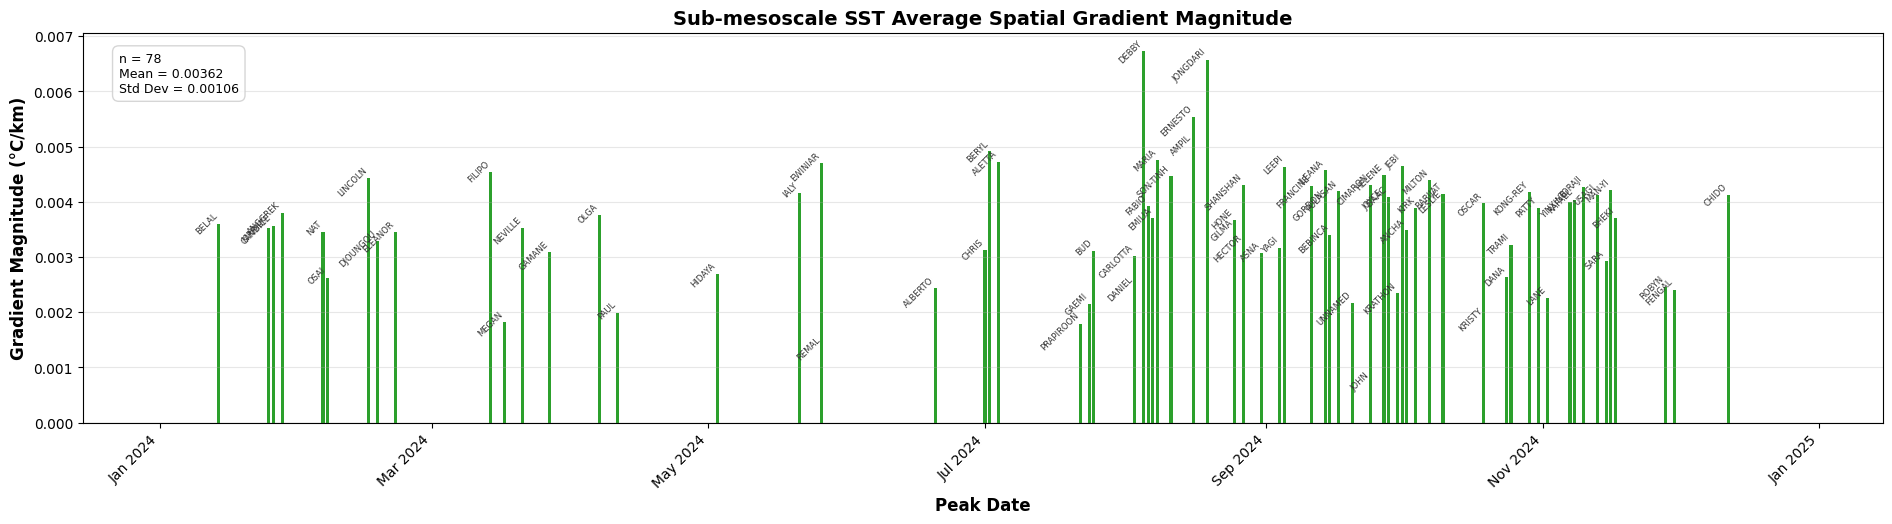

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os

def plot_gradient_timeline(df, col, title, y_label, save_name):
    valid = df.dropna(subset=[col, 'Peak_Date']).copy()
    if valid.empty:
        print(f"No data for {col}")
        return
        
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])
    valid = valid.sort_values('Peak_Date')

    # Figure size
    fig_width = min(20, max(12, len(valid) * 0.4))
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    # All values are magnitudes (>=0), using a distinct color
    color = '#2ca02c' # Green for spatial gradient

    bars = ax.bar(
        valid['Peak_Date'],
        valid[col],
        color=color,
        edgecolor=None,
        linewidth=0,
        width=0.7
    )

    ax.axhline(0, color='gray', linewidth=0.8, zorder=2)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    if len(valid) <= 12:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

    ax.set_xlim([
        pd.to_datetime('2023-12-15'),
        pd.to_datetime('2025-01-15')
    ])

    fig.autofmt_xdate(rotation=45)
    ax.grid(axis='y', alpha=0.3)

    ymin, ymax = valid[col].min(), valid[col].max()
    offset = 0.02 * (ymax - ymin) if ymax != ymin else 0.01

    for bar, name in zip(bars, valid['Cyclone']):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            name,
            ha='right',
            va='bottom',
            fontsize=6,
            rotation=45,
            rotation_mode='anchor',
            color='#333333'
        )

    # Statistics box
    col_mean = valid[col].mean()
    col_std = valid[col].std()

    stats_text = (
        f"n = {len(valid)}\n"
        f"Mean = {col_mean:.5f}\n"
        f"Std Dev = {col_std:.5f}"
    )

    ax.text(
        0.02,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round,pad=0.5',
            facecolor='white',
            alpha=0.8,
            edgecolor='#cccccc'
        )
    )

    plt.subplots_adjust(
        bottom=0.25,
        top=0.9,
        left=0.08,
        right=0.98
    )

    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    print(f"Saved: {save_name}")
    plt.show()
    plt.close(fig)
    
# if __name__ == '__main__':
#     csv_file = 'cyclone_multiscale_anomalies.csv'
#     if not os.path.exists(csv_file):
#         print(f"Error: {csv_file} not found.")
#     else:
#         df = pd.read_csv(csv_file)
#         plot_gradient_timeline(
#             df,
#             col='SST_Submeso_Grad_Avg',
#             title='Sub-mesoscale SST Average Spatial Gradient Magnitude',
#             y_label='Gradient Magnitude (°C/km)',
#             save_name='SST_Submeso_Grad_Avg_vs_Date.png'
#         )


  CYCLONE OCEAN COUPLING INDEX (COCI) ANALYSIS

Merged 78 cyclones with SST/MSLA anomalies + intensity.

─── Validation: Pearson r (Index vs Max Wind) ───
                  Index  Pearson_r      p_value
 A: Equal-Weight Linear   0.526398 7.419816e-07
   B: Ocean × Intensity   0.160992 1.591044e-01
C: Correlation-Weighted   0.038689 7.366418e-01
          D: Ocean-Only   0.038005 7.411377e-01

★ BEST INDEX: A: Equal-Weight Linear  (r = 0.5264)

─── Mean COCI by Category ───
            COCI_A    COCI_B    COCI_C    COCI_D  Count
Category                                               
TS       -0.223508 -0.113416  0.109050  0.108423     36
1        -0.343354  0.098660 -0.481087 -0.451744     12
2         0.177925  0.068496  0.111072  0.086770      7
3        -0.365494 -1.239785 -0.858817 -0.914893      2
4         0.435415  0.030264  0.019592  0.014830     17
5         1.062497  2.356073  0.613580  0.621993      4

Correlation weights (Option C):
  corr(SST, Vmax)  = 0.0279
  corr(MSLA, 

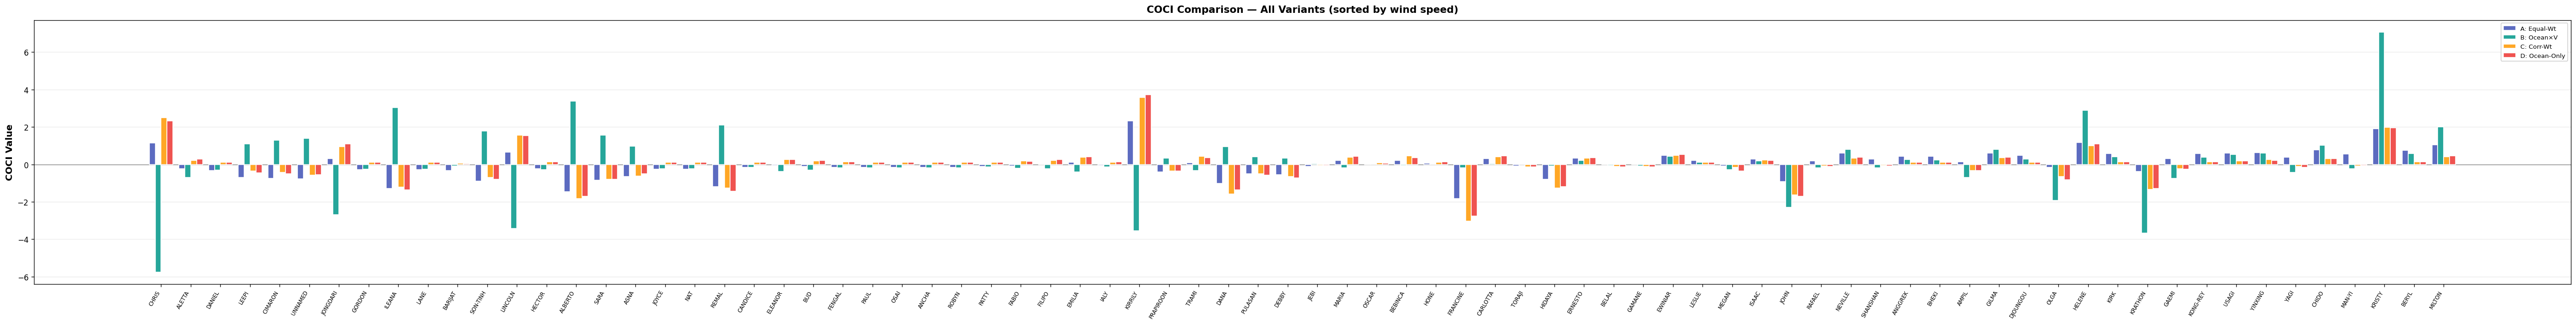

Saved: COCI_Best_Scatter.png


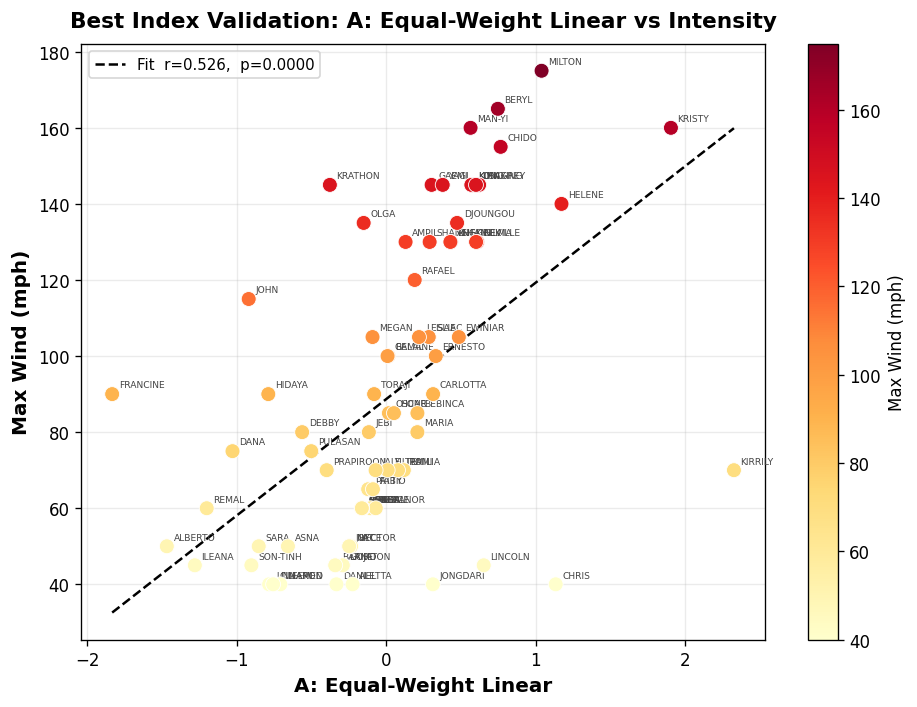

Saved: COCI_Category_Means.png


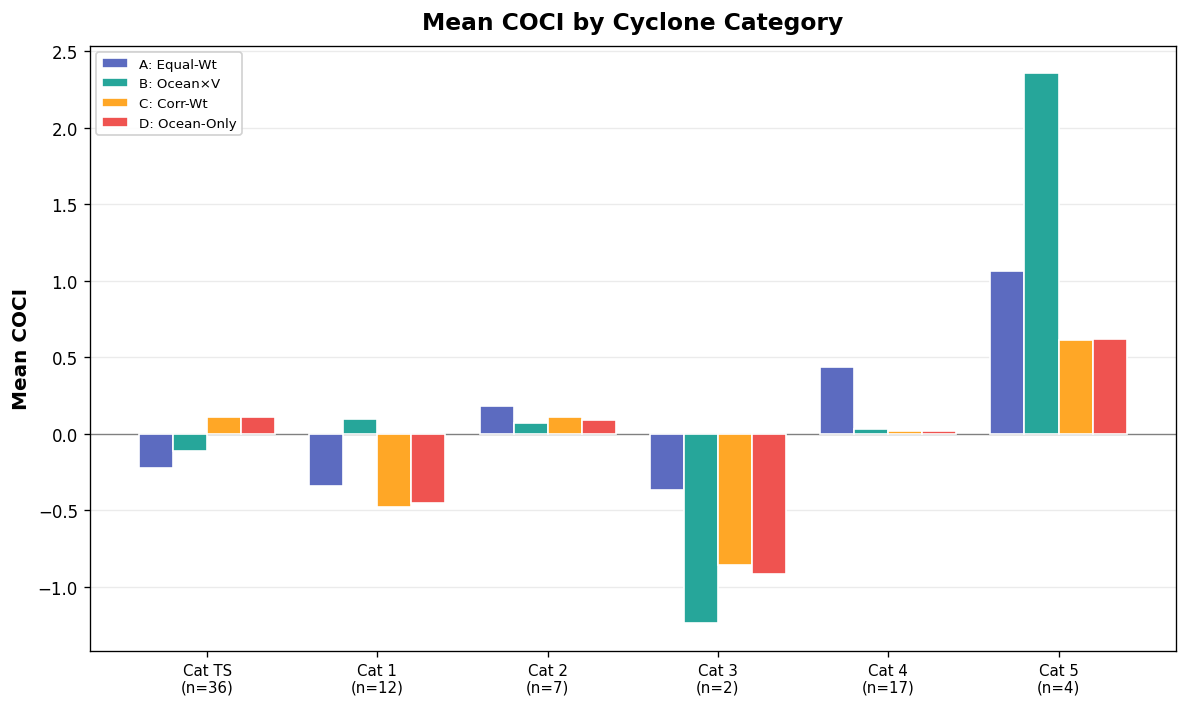


Full results → coci_results.csv
Validation   → coci_validation.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

# =============================================================================
# STEP 0 — LOAD INTENSITY DATA FROM JSON
# =============================================================================

def load_intensity_data(json_path='cyclone_info_2024_padded.json'):
    """Extract max_wind_mph and min_pressure_mb for every storm."""
    with open(json_path, 'r') as f:
        data = json.load(f)

    records = []
    for basin_key, basin in data.items():
        if not isinstance(basin, dict) or 'storms' not in basin:
            continue
        for s in basin['storms']:
            records.append({
                'Cyclone': s['name'],
                'Category': s.get('category', ''),
                'Max_Wind_mph': s.get('max_wind_mph', np.nan),
                'Min_Pressure_mb': s.get('min_pressure_mb', np.nan),
            })
    return pd.DataFrame(records)


# =============================================================================
# STEP 1 — MERGE ANOMALIES + INTENSITY
# =============================================================================

def build_coci_dataframe(anomaly_csv='cyclone_multiscale_anomalies.csv',
                         json_path='cyclone_info_2024_padded.json'):
    """Merge the pre-computed SST/MSLA anomalies with intensity metadata."""
    df_anom = pd.read_csv(anomaly_csv)
    df_int  = load_intensity_data(json_path)

    # normalise names to uppercase so CSV and JSON always match
    df_anom['Cyclone'] = df_anom['Cyclone'].str.upper()
    df_int['Cyclone']  = df_int['Cyclone'].str.upper()

    # merge on cyclone name
    df = df_anom.merge(df_int, on='Cyclone', how='left')

    # use meso-scale as primary anomaly (most relevant for cyclone coupling)
    df = df.rename(columns={'SST_Meso': 'SST_Anom', 'MSLA_Meso': 'MSLA_Anom'})

    # drop rows missing critical columns
    df = df.dropna(subset=['SST_Anom', 'MSLA_Anom', 'Max_Wind_mph'])

    # z-score normalisation
    for col, zcol in [('SST_Anom', 'Z_SST'),
                      ('MSLA_Anom', 'Z_MSLA'),
                      ('Max_Wind_mph', 'Z_V')]:
        mu, sigma = df[col].mean(), df[col].std()
        df[zcol] = (df[col] - mu) / sigma if sigma > 0 else 0.0

    return df


# =============================================================================
# STEP 2 — COMPUTE ALL INDEX VARIANTS
# =============================================================================

def compute_all_indices(df):
    """Add columns for every COCI formulation."""

    # --- Option A: Equal-weight linear ---
    df['COCI_A'] = (df['Z_SST'] + df['Z_MSLA'] + df['Z_V']) / 3.0

    # --- Option B: Ocean forcing × intensity (multiplicative) ---
    df['COCI_B'] = (df['Z_SST'] + df['Z_MSLA']) * df['Z_V']

    # --- Option C: Correlation-weighted (data-driven) ---
    if len(df) >= 2:
        r_sst, _  = pearsonr(df['SST_Anom'], df['Max_Wind_mph'])
        r_msla, _ = pearsonr(df['MSLA_Anom'], df['Max_Wind_mph'])
    else:
        r_sst, r_msla = 0.5, 0.5
    w_sst  = abs(r_sst)
    w_msla = abs(r_msla)
    w_sum  = w_sst + w_msla
    if w_sum > 0:
        df['COCI_C'] = (w_sst * df['Z_SST'] + w_msla * df['Z_MSLA']) / w_sum
    else:
        df['COCI_C'] = (df['Z_SST'] + df['Z_MSLA']) / 2.0

    # --- Option D: Simple ocean-only (no intensity) ---
    df['COCI_D'] = (df['Z_SST'] + df['Z_MSLA']) / 2.0

    # store the correlation weights for reporting
    df.attrs['r_sst']  = r_sst
    df.attrs['r_msla'] = r_msla

    return df


# =============================================================================
# STEP 3 — CLASSIFY EACH CYCLONE
# =============================================================================

def classify_coci(value):
    if value > 2:
        return 'Extreme'
    elif value > 1:
        return 'Strong'
    elif value > 0:
        return 'Moderate'
    elif value > -1:
        return 'Weak'
    else:
        return 'Suppressed'


def add_classifications(df):
    for idx_col in ['COCI_A', 'COCI_B', 'COCI_C', 'COCI_D']:
        df[f'{idx_col}_Class'] = df[idx_col].apply(classify_coci)
    return df


# =============================================================================
# STEP 4 — VALIDATE: correlate each index with Vmax
# =============================================================================

def validate_indices(df):
    """Return a summary DataFrame of validation metrics."""
    results = []
    for idx_col, label in [
        ('COCI_A', 'A: Equal-Weight Linear'),
        ('COCI_B', 'B: Ocean × Intensity'),
        ('COCI_C', 'C: Correlation-Weighted'),
        ('COCI_D', 'D: Ocean-Only'),
    ]:
        if len(df) >= 2:
            r, p = pearsonr(df[idx_col], df['Max_Wind_mph'])
        else:
            r, p = 0.0, 1.0
        results.append({
            'Index': label,
            'Column': idx_col,
            'Pearson_r': r,
            'p_value': p,
            'Mean': df[idx_col].mean(),
            'Std': df[idx_col].std(),
        })
    return pd.DataFrame(results)


# =============================================================================
# STEP 5 — VALIDATE: mean COCI by cyclone category
# =============================================================================

def category_validation(df):
    """Mean of each index grouped by cyclone category."""
    cat_order = ['TS', '1', '2', '3', '4', '5']
    idx_cols = ['COCI_A', 'COCI_B', 'COCI_C', 'COCI_D']
    grp = df.groupby('Category')[idx_cols].mean()
    grp = grp.reindex([c for c in cat_order if c in grp.index])
    grp['Count'] = df.groupby('Category')['Cyclone'].count()
    return grp


# =============================================================================
# PLOTS
# =============================================================================

def plot_index_comparison(df, save=True):
    """Bar chart comparing all 4 COCI variants for every cyclone."""
    idx_cols = ['COCI_A', 'COCI_B', 'COCI_C', 'COCI_D']
    labels   = ['A: Equal-Wt', 'B: Ocean×V', 'C: Corr-Wt', 'D: Ocean-Only']
    colors   = ['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']

    df_sorted = df.sort_values('Max_Wind_mph')
    x = np.arange(len(df_sorted))
    width = 0.2

    fig, ax = plt.subplots(figsize=(max(14, len(df_sorted) * 0.6), 6))
    for i, (col, lab, clr) in enumerate(zip(idx_cols, labels, colors)):
        ax.bar(x + i * width, df_sorted[col].values, width,
               label=lab, color=clr, edgecolor='white', zorder=3)

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(df_sorted['Cyclone'], rotation=60, fontsize=7, ha='right')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylabel('COCI Value', fontsize=12, fontweight='bold')
    ax.set_title('COCI Comparison — All Variants (sorted by wind speed)',
                 fontsize=13, fontweight='bold', pad=10)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(axis='y', alpha=0.25, zorder=0)
    plt.tight_layout()
    if save:
        plt.savefig('COCI_Comparison.png', dpi=150, bbox_inches='tight')
        print("Saved: COCI_Comparison.png")
    plt.show()


def plot_best_index_scatter(df, best_col, best_label, save=True):
    """Scatter plot: best COCI vs Max Wind with regression."""
    r, p = pearsonr(df[best_col], df['Max_Wind_mph'])

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(df[best_col], df['Max_Wind_mph'],
                    c=df['Max_Wind_mph'], cmap='YlOrRd',
                    s=80, edgecolors='white', linewidths=0.5, zorder=4)
    # annotate
    for _, row in df.iterrows():
        ax.annotate(row['Cyclone'],
                    xy=(row[best_col], row['Max_Wind_mph']),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=5.5, color='#444444')
    # regression
    m, b = np.polyfit(df[best_col].values, df['Max_Wind_mph'].values, 1)
    xs = np.linspace(df[best_col].min(), df[best_col].max(), 200)
    ax.plot(xs, m * xs + b, 'k--', lw=1.5,
            label=f'Fit  r={r:.3f},  p={p:.4f}')

    ax.set_xlabel(f'{best_label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Max Wind (mph)', fontsize=12, fontweight='bold')
    ax.set_title(f'Best Index Validation: {best_label} vs Intensity',
                 fontsize=13, fontweight='bold', pad=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.colorbar(sc, ax=ax, label='Max Wind (mph)')
    plt.tight_layout()
    if save:
        plt.savefig('COCI_Best_Scatter.png', dpi=150, bbox_inches='tight')
        print("Saved: COCI_Best_Scatter.png")
    plt.show()


def plot_category_means(cat_df, save=True):
    """Grouped bar chart of mean COCI by cyclone category."""
    idx_cols = ['COCI_A', 'COCI_B', 'COCI_C', 'COCI_D']
    labels   = ['A: Equal-Wt', 'B: Ocean×V', 'C: Corr-Wt', 'D: Ocean-Only']
    colors   = ['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']

    x = np.arange(len(cat_df))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (col, lab, clr) in enumerate(zip(idx_cols, labels, colors)):
        vals = cat_df[col].fillna(0).values
        ax.bar(x + i * width, vals, width,
               label=lab, color=clr, edgecolor='white', zorder=3)

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels([f"Cat {c}\n(n={int(cat_df.loc[c, 'Count'])})"
                        for c in cat_df.index], fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylabel('Mean COCI', fontsize=12, fontweight='bold')
    ax.set_title('Mean COCI by Cyclone Category',
                 fontsize=14, fontweight='bold', pad=10)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(axis='y', alpha=0.25, zorder=0)
    plt.tight_layout()
    if save:
        plt.savefig('COCI_Category_Means.png', dpi=150, bbox_inches='tight')
        print("Saved: COCI_Category_Means.png")
    plt.show()


# =============================================================================
# MASTER RUNNER
# =============================================================================

def run_coci_analysis(anomaly_csv='cyclone_multiscale_anomalies.csv',
                      json_path='cyclone_info_2024_padded.json',
                      save=True):
    """End-to-end COCI analysis. Returns (df, validation, category, best_col)."""

    print("=" * 60)
    print("  CYCLONE OCEAN COUPLING INDEX (COCI) ANALYSIS")
    print("=" * 60)

    # 1. Build merged dataframe
    df = build_coci_dataframe(anomaly_csv, json_path)
    print(f"\nMerged {len(df)} cyclones with SST/MSLA anomalies + intensity.\n")

    # 2. Compute all indices
    df = compute_all_indices(df)
    df = add_classifications(df)

    # 3. Validate
    val_df = validate_indices(df)
    print("─── Validation: Pearson r (Index vs Max Wind) ───")
    print(val_df[['Index', 'Pearson_r', 'p_value']].to_string(index=False))

    # 4. Identify best
    best_row = val_df.loc[val_df['Pearson_r'].abs().idxmax()]
    best_col = best_row['Column']
    best_label = best_row['Index']
    print(f"\n★ BEST INDEX: {best_label}  (r = {best_row['Pearson_r']:.4f})")

    # 5. Category validation
    cat_df = category_validation(df)
    print("\n─── Mean COCI by Category ───")
    print(cat_df.to_string())

    # 6. Correlation weights used in Option C
    print(f"\nCorrelation weights (Option C):")
    print(f"  corr(SST, Vmax)  = {df.attrs.get('r_sst', 0):.4f}")
    print(f"  corr(MSLA, Vmax) = {df.attrs.get('r_msla', 0):.4f}")

    # 7. Plots
    plot_index_comparison(df, save)
    plot_best_index_scatter(df, best_col, best_label, save)
    plot_category_means(cat_df, save)

    # 8. Save full table
    out_csv = 'coci_results.csv'
    df.to_csv(out_csv, index=False)
    print(f"\nFull results → {out_csv}")

    val_csv = 'coci_validation.csv'
    val_df.to_csv(val_csv, index=False)
    print(f"Validation   → {val_csv}")

    return df, val_df, cat_df, best_col


# =============================================================================
# RUN  (uncomment to execute)
# =============================================================================
# df_coci, val, cat, best = run_coci_analysis()


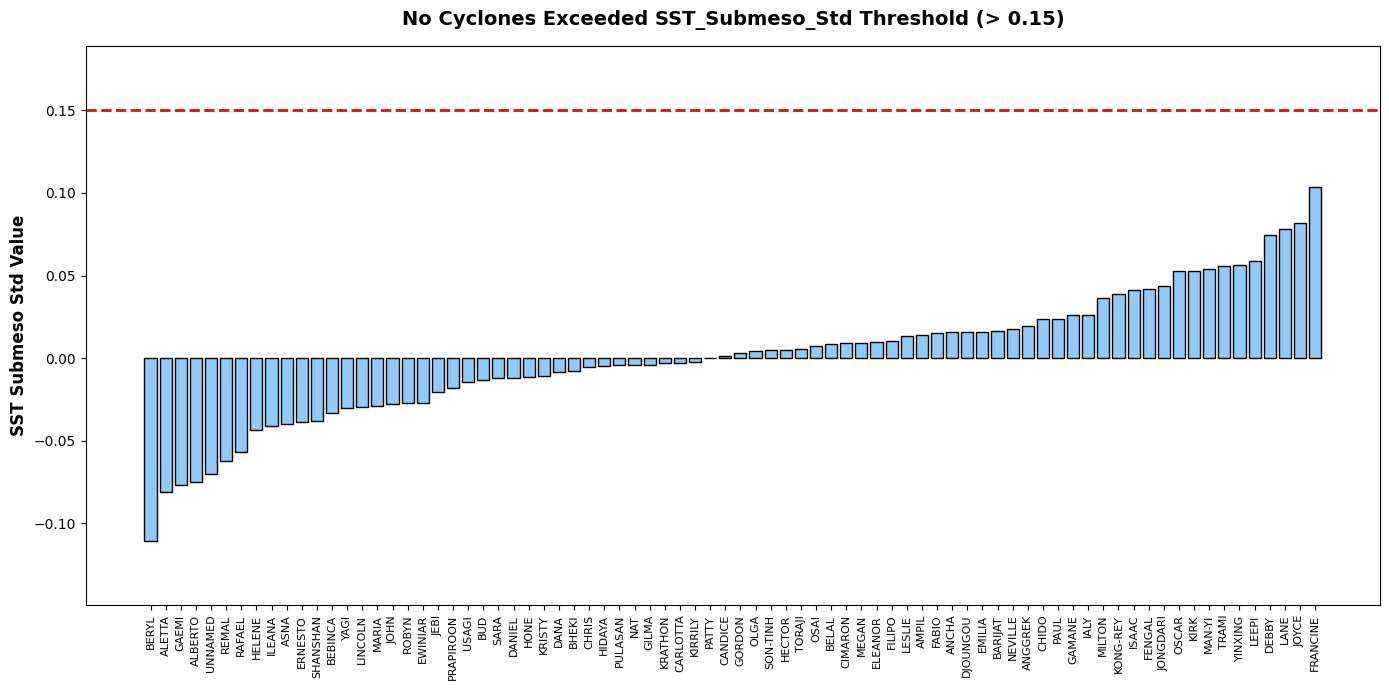

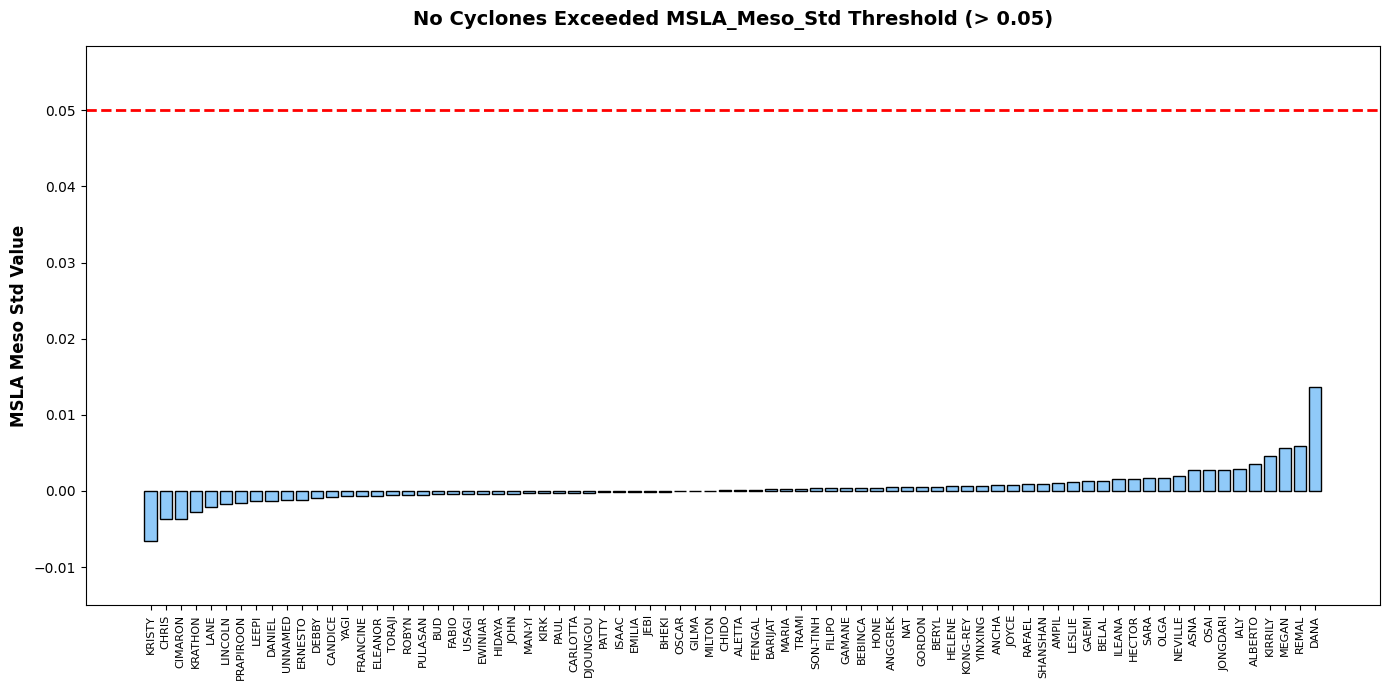

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_and_annotate_high_std(csv_file='cyclone_multiscale_anomalies.csv', std_column='SST_Submeso_Std', threshold=0.1):
    """
    Plots the Standard Deviation for all cyclones and annotates the ones 
    that cross a specific threshold value.
    """
    # Load the exported anomaly data
    df = pd.read_csv(csv_file)
    
    # Drop rows without the specific std data
    df = df.dropna(subset=[std_column])
    
    # Sort for better visual representation
    df = df.sort_values(by=std_column).reset_index(drop=True)
    
    plt.figure(figsize=(14, 7))
    
    # Setup x indexing
    x_positions = np.arange(len(df))
    
    # Bar plot for all cyclones
    bars = plt.bar(x_positions, df[std_column], color='#90CAF9', edgecolor='black')
    
    # Draw threshold line
    plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')
    
    # Find and annotate outliers
    outliers_found = False
    for i, row in df.iterrows():
        val = row[std_column]
        if val > threshold:
            outliers_found = True
            # Color the bar red if it exceeds threshold
            bars[i].set_color('#EF5350')
            bars[i].set_edgecolor('black')
            
            # Annotate the cyclone name & value above the bar
            plt.text(x_positions[i], val + (val * 0.02), 
                     f"{row['Cyclone']}\n({val:.3f})", 
                     ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkred', rotation=45)
            
    plt.xticks(x_positions, df['Cyclone'], rotation=90, fontsize=8)
    plt.ylabel(f'{std_column.replace("_", " ")} Value', fontsize=12, fontweight='bold')
    plt.title(f'Cyclones Exceeding {std_column} Threshold (> {threshold})', fontsize=14, fontweight='bold', pad=15)
    
    if outliers_found:
        plt.legend()
    else:
        plt.title(f'No Cyclones Exceeded {std_column} Threshold (> {threshold})', fontsize=14, fontweight='bold', pad=15)
        
    plt.margins(y=0.15) # Add padding at the top for labels
    plt.tight_layout()
    plt.show()

# ==========================================
# Run the function (adjust target and threshold as needed)
# ==========================================

# # Example 1: Finding Submeso SST Standard Deviation Outliers > 0.15
# plot_and_annotate_high_std(std_column='SST_Submeso_Std', threshold=0.15)

# # Example 2: Finding Meso MSLA Standard Deviation Outliers > 0.05
# plot_and_annotate_high_std(std_column='MSLA_Meso_Std', threshold=0.05)


─── Top 5 Cyclones by 0-1 Coupling Score ───
    Cyclone Category    COCI_A  COCI_Scale_0_to_1  COCI_Score_100
67  KIRRILY       TS  2.324407           1.000000      100.000000
14   KRISTY        5  1.903055           0.898663       89.866294
7    HELENE        4  1.171260           0.722663       72.266305
2     CHRIS       TS  1.132485           0.713337       71.333750
12   MILTON        5  1.038025           0.690620       69.061954
Saved: COCI_Score_0to1_Ranking.png


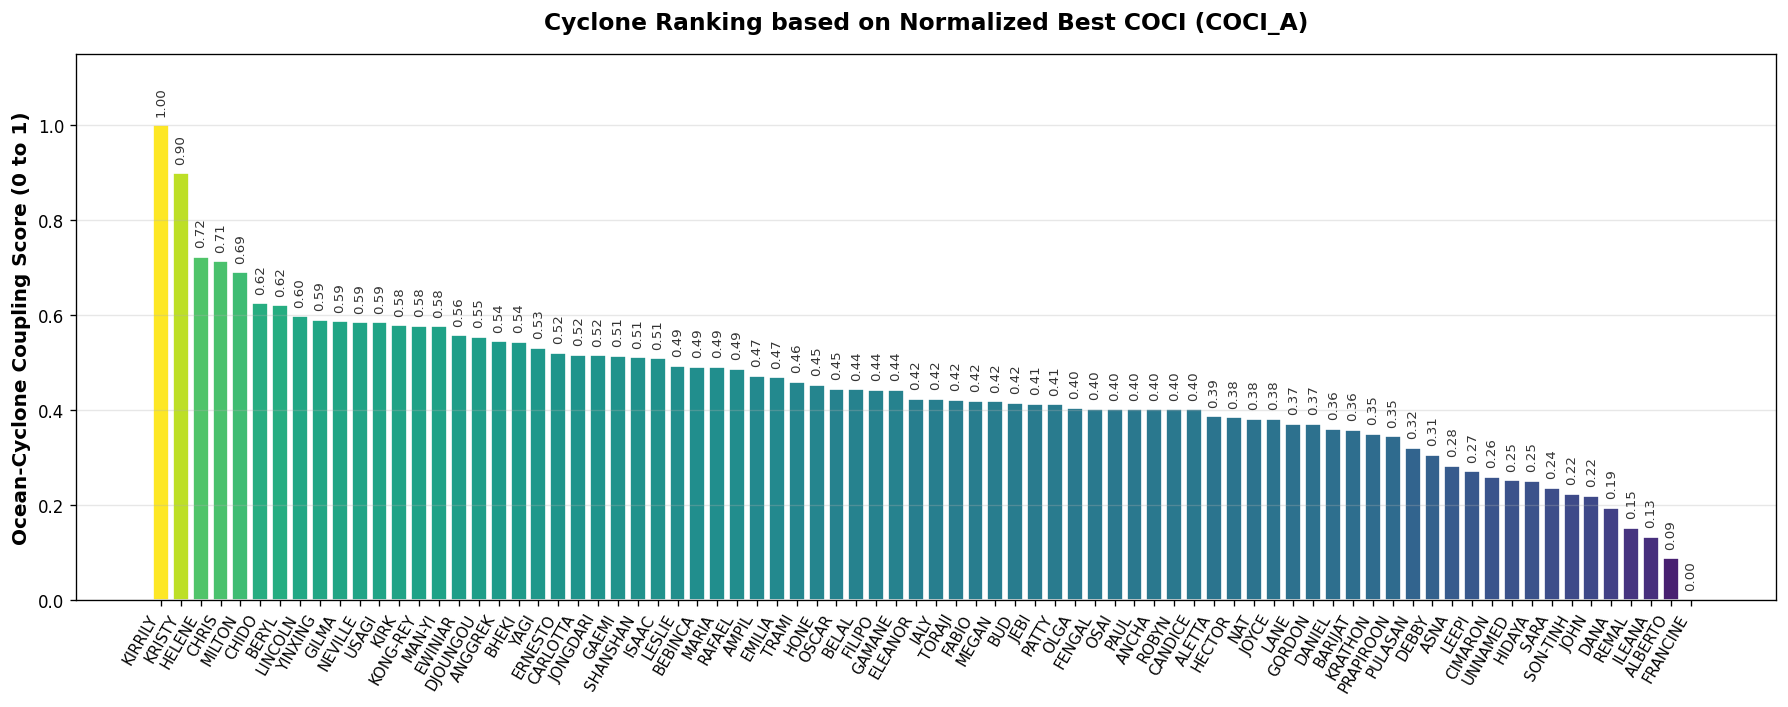

In [ ]:
# =============================================================================
# STEP 6 — NORMALIZE BEST COCI TO 0-1 SCALE & PLOT RANKING
# =============================================================================

def calculate_coci_0_to_1(df, best_col):
    """
    Applies Min-Max normalization to the best COCI variant.
    Maps everything to a strict [0, 1] range.
    """
    min_val = df[best_col].min()
    max_val = df[best_col].max()
    
    # Mathematical scaling to 0 - 1
    df['COCI_Scale_0_to_1'] = (df[best_col] - min_val) / (max_val - min_val)
    
    # Creating an alternative 0 to 100 percentage score (often easier to read)
    df['COCI_Score_100'] = df['COCI_Scale_0_to_1'] * 100
    
    return df

def plot_coci_scores(df, best_col, save=True):
    """Bar chart ranking all cyclones from 1.0 (Highest) to 0.0 (Lowest)."""
    # Sort cyclones by their new score so the graph acts as a leaderboard
    df_sorted = df.sort_values('COCI_Scale_0_to_1', ascending=False)
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Use a colormap so high numbers are yellow/green, low numbers are dark purple
    colors = plt.cm.viridis(df_sorted['COCI_Scale_0_to_1'])
    
    bars = ax.bar(df_sorted['Cyclone'], df_sorted['COCI_Scale_0_to_1'], 
                  color=colors, edgecolor='white', linewidth=1)
    
    ax.set_ylabel('Ocean-Cyclone Coupling Score (0 to 1)', fontsize=12, fontweight='bold')
    ax.set_title(f'Cyclone Ranking based on Normalized Best COCI ({best_col})', fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xticklabels(df_sorted['Cyclone'], rotation=60, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.15) # Give room for labels on top
    
    # Annotate the specific 0.xx value on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', 
                ha='center', va='bottom', fontsize=8, rotation=90, color='#333333')
        
    plt.tight_layout()
    if save:
        plt.savefig('COCI_Score_0to1_Ranking.png', dpi=150)
        print("Saved: COCI_Score_0to1_Ranking.png")
    plt.show()

# --- Run the function using the 'best' variable exported from your master runner ---
df_coci = calculate_coci_0_to_1(df_coci, best)

print("\n─── Top 5 Cyclones by 0-1 Coupling Score ───")
print(df_coci[['Cyclone', 'Category', best, 'COCI_Scale_0_to_1', 'COCI_Score_100']].sort_values('COCI_Scale_0_to_1', ascending=False).head())

plot_coci_scores(df_coci, best)

# Save updated dataset with the new 0_val_1 scoring columns
# df_coci.to_csv('coci_results_with_scoring.csv', index=False)

Saved: COCI_Individual_Components.png


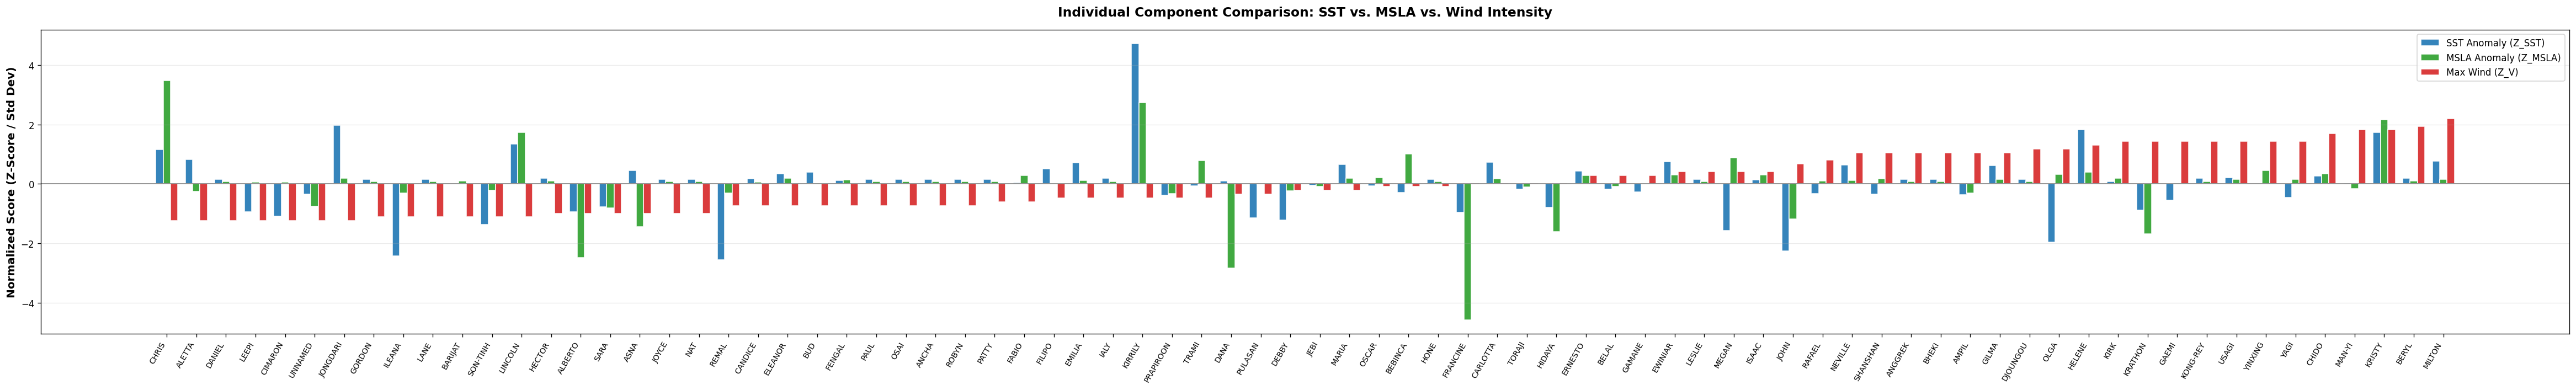

In [ ]:
def plot_individual_coci_components(df, save=True):
    """
    Grouped bar chart comparing the individual normalized components 
    (Z_SST, Z_MSLA, Z_V) for each cyclone to see their individual effects.
    Sorted by maximum wind speed (Z_V).
    """
    if 'Z_SST' not in df.columns or df.empty:
        print("Required normalized columns (Z_SST, Z_MSLA, Z_V) not found.")
        return
        
    # Sort by normalized wind speed to see how ocean components react to intensity
    df_sorted = df.sort_values('Z_V')
    
    x = np.arange(len(df_sorted))
    width = 0.25  # standard width for 3 side-by-side bars
    
    fig, ax = plt.subplots(figsize=(max(14, len(df_sorted) * 0.5), 6))
    
    # Plot the 3 components
    ax.bar(x - width, df_sorted['Z_SST'], width, 
           label='SST Anomaly (Z_SST)', color='#1f77b4', edgecolor='white', alpha=0.9)
           
    ax.bar(x, df_sorted['Z_MSLA'], width, 
           label='MSLA Anomaly (Z_MSLA)', color='#2ca02c', edgecolor='white', alpha=0.9)
           
    ax.bar(x + width, df_sorted['Z_V'], width, 
           label='Max Wind (Z_V)', color='#d62728', edgecolor='white', alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted['Cyclone'], rotation=60, ha='right', fontsize=8.5)
    
    ax.axhline(0, color='gray', linewidth=1, zorder=1)
    
    ax.set_ylabel('Normalized Score (Z-Score / Std Dev)', fontsize=12, fontweight='bold')
    ax.set_title('Individual Component Comparison: SST vs. MSLA vs. Wind Intensity', 
                 fontsize=14, fontweight='bold', pad=15)
                 
    ax.legend(fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.25)
    
    plt.tight_layout()
    if save:
        plt.savefig('COCI_Individual_Components.png', dpi=150, bbox_inches='tight')
        print("Saved: COCI_Individual_Components.png")
    plt.show()

# =============================================================================
# Add this line to the bottom of your MASTER RUNNER function (run_coci_analysis)
# OR simply run it alone like this if your dataframe is already loaded:
# =============================================================================
# plot_individual_coci_components(df_coci, save=True)

Saved: Ranking_Wind_0to1.png


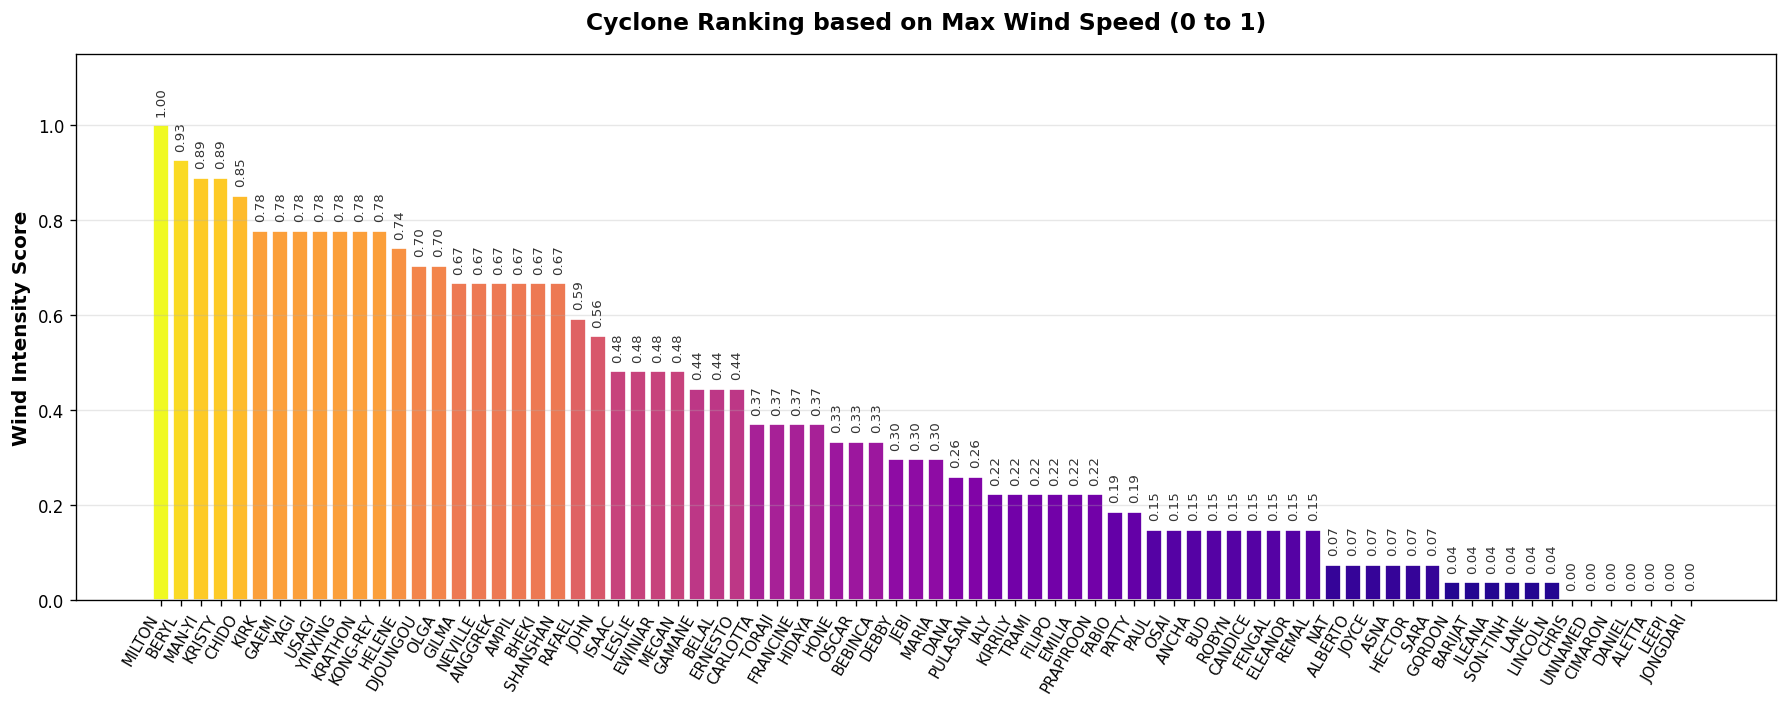

Saved: Ranking_SST_0to1.png


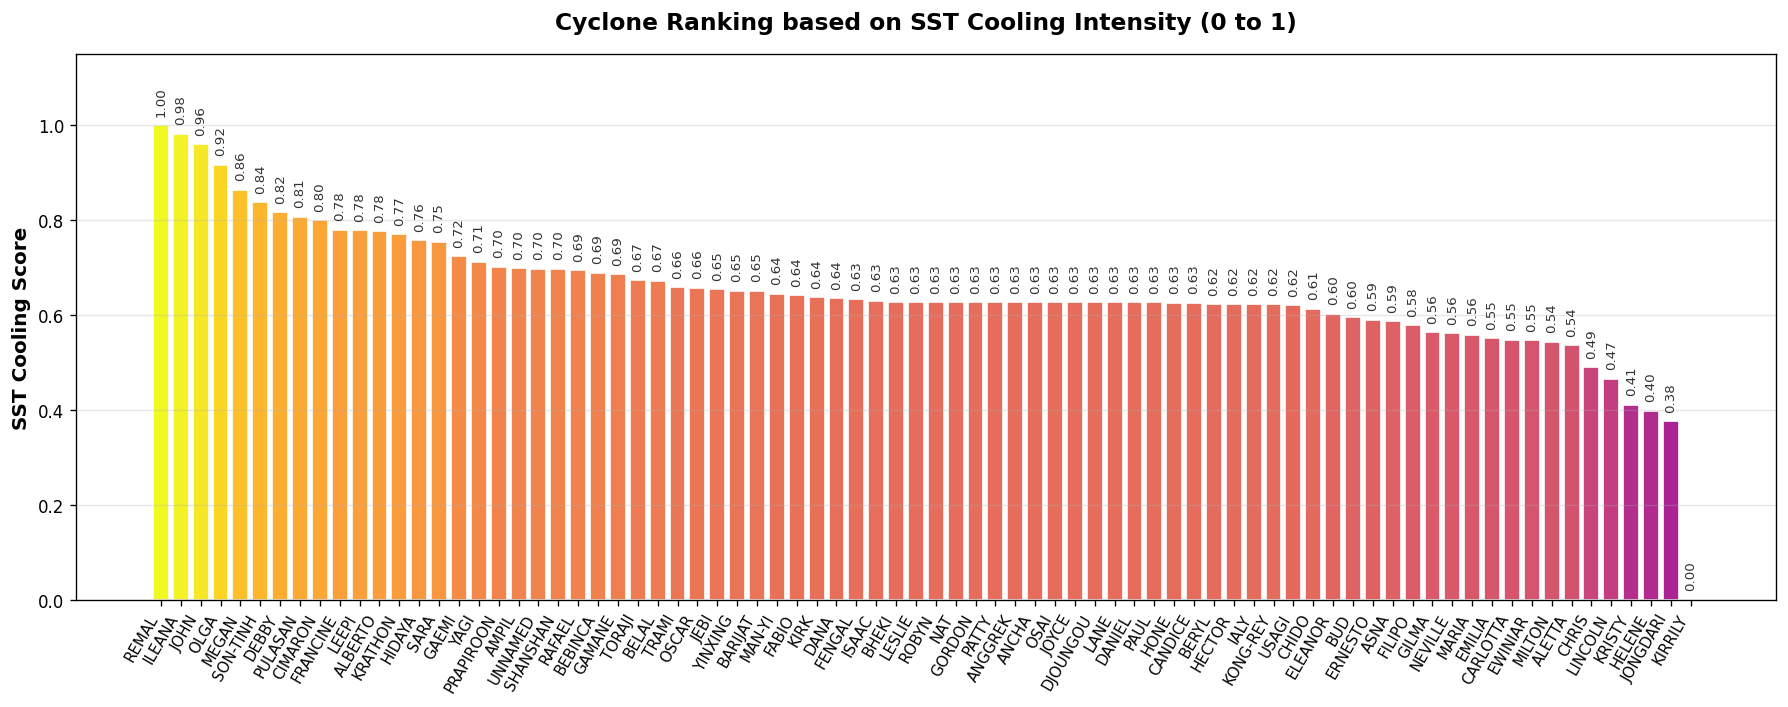

Saved: Ranking_MSLA_0to1.png


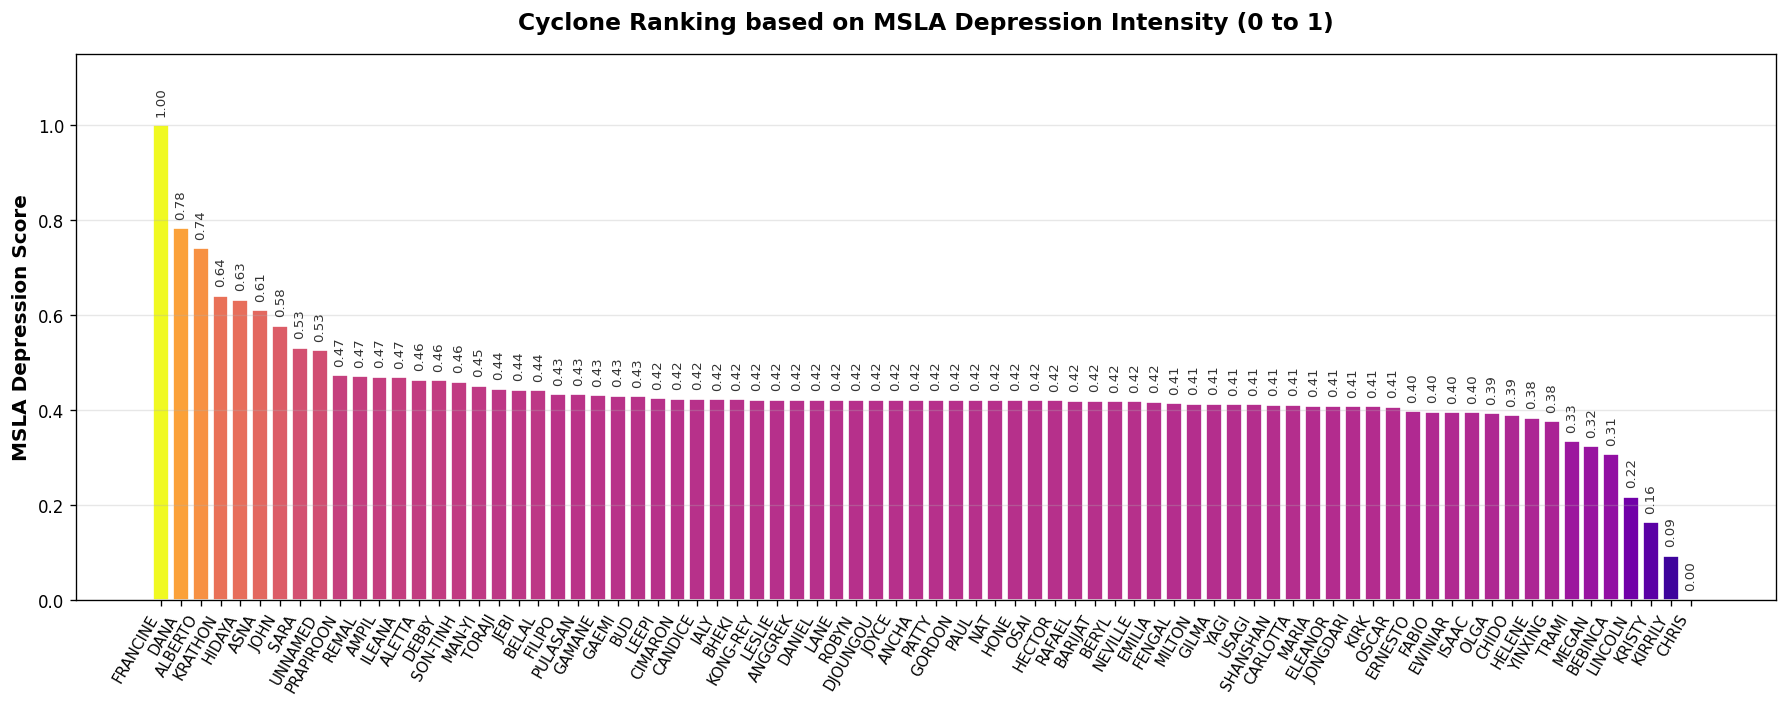

In [ ]:
# =============================================================================
# INDIVIDUAL COMPONENT RANKINGS (0 to 1 SCALE)
# =============================================================================

def calculate_individual_0_to_1(df):
    """
    Normalizes Max Wind, SST Anomaly, and MSLA Anomaly to a 0-1 scale.
    Note: SST and MSLA are inverted so that the MOST NEGATIVE anomaly (strongest cooling/depression) gets 1.0.
    """
    # Wind: Higher is stronger
    min_v, max_v = df['Max_Wind_mph'].min(), df['Max_Wind_mph'].max()
    df['Wind_Scale_0_to_1'] = (df['Max_Wind_mph'] - min_v) / (max_v - min_v)
    
    # SST: More negative is stronger
    min_sst, max_sst = df['SST_Anom'].min(), df['SST_Anom'].max()
    df['SST_Scale_0_to_1'] = (max_sst - df['SST_Anom']) / (max_sst - min_sst)
    
    # MSLA: More negative is stronger
    min_msla, max_msla = df['MSLA_Anom'].min(), df['MSLA_Anom'].max()
    df['MSLA_Scale_0_to_1'] = (max_msla - df['MSLA_Anom']) / (max_msla - min_msla)
    
    return df

def plot_single_ranking(df, col_name, title, ylabel, save_name, save=True):
    """Helper to plot a single leaderboard."""
    df_sorted = df.sort_values(col_name, ascending=False)
    
    fig, ax = plt.subplots(figsize=(15, 6))
    colors = plt.cm.plasma(df_sorted[col_name]) # Using plasma for a distinct look
    
    bars = ax.bar(df_sorted['Cyclone'], df_sorted[col_name], 
                  color=colors, edgecolor='white', linewidth=1)
    
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xticklabels(df_sorted['Cyclone'], rotation=60, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.15)
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', 
                ha='center', va='bottom', fontsize=8, rotation=90, color='#333333')
        
    plt.tight_layout()
    if save:
        plt.savefig(save_name, dpi=150)
        print(f"Saved: {save_name}")
    plt.show()

def plot_all_individual_rankings(df):
    """Generates the three individual ranking plots."""
    df = calculate_individual_0_to_1(df)
    
    plot_single_ranking(df, 'Wind_Scale_0_to_1', 
                        'Cyclone Ranking based on Max Wind Speed (0 to 1)', 
                        'Wind Intensity Score', 'Ranking_Wind_0to1.png')
                        
    plot_single_ranking(df, 'SST_Scale_0_to_1', 
                        'Cyclone Ranking based on SST Cooling Intensity (0 to 1)', 
                        'SST Cooling Score', 'Ranking_SST_0to1.png')
                        
    plot_single_ranking(df, 'MSLA_Scale_0_to_1', 
                        'Cyclone Ranking based on MSLA Depression Intensity (0 to 1)', 
                        'MSLA Depression Score', 'Ranking_MSLA_0to1.png')
                        
    return df

# --- RUN IT ---
# df_coci = plot_all_individual_rankings(df_coci)

Saved: COCI_A_Dominance_Stacked.png


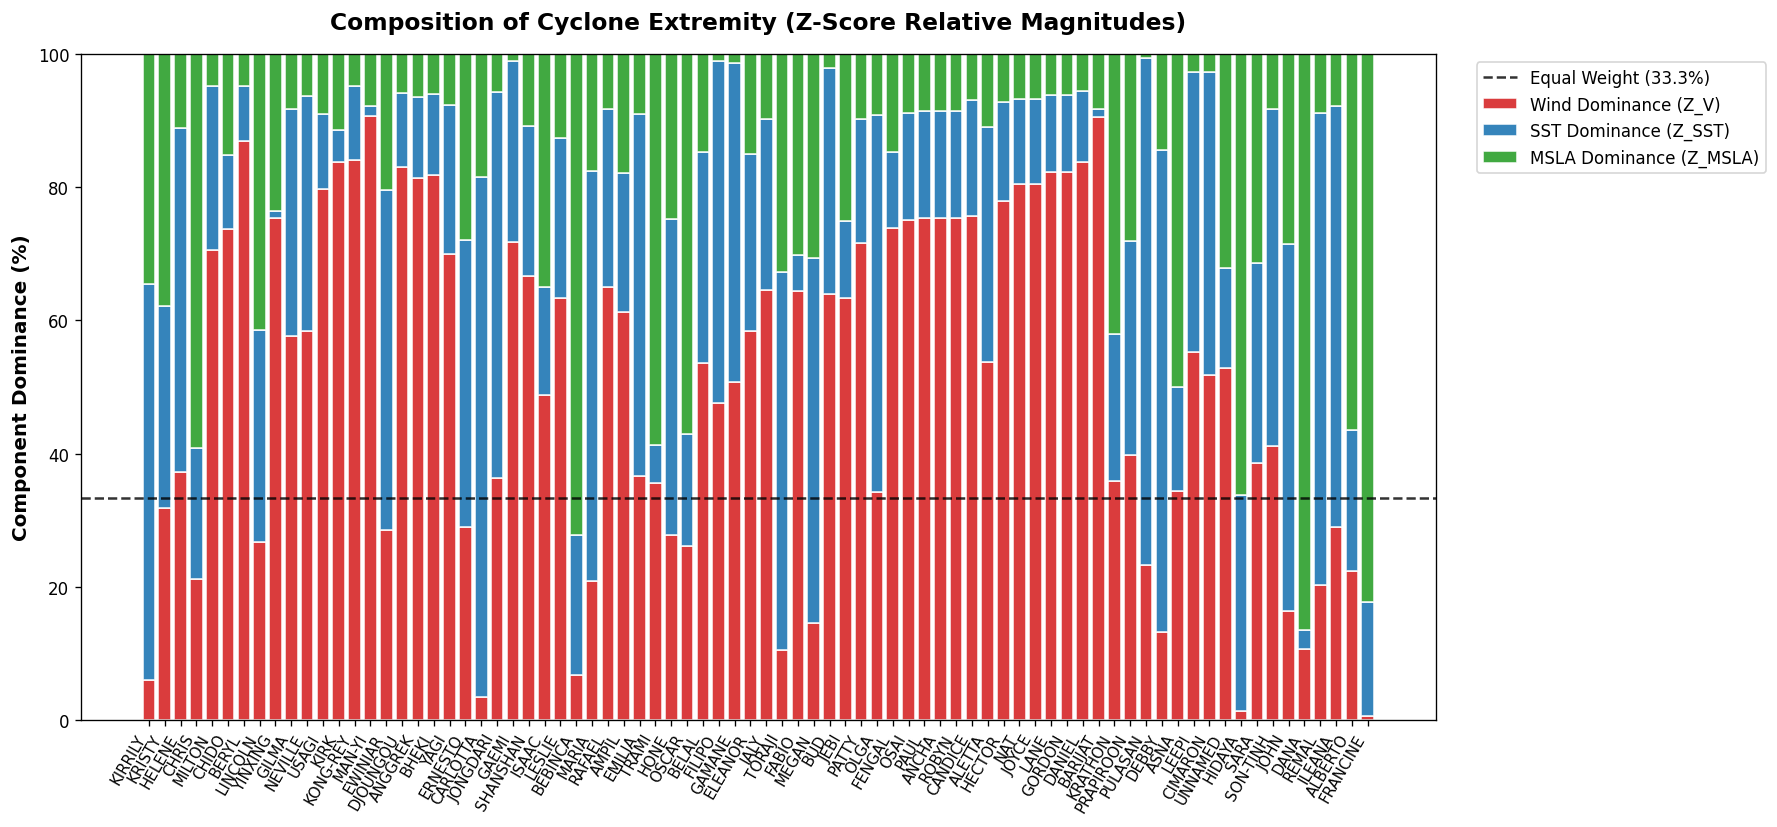

In [ ]:
def plot_coci_a_dominance(df, save=True):
    """
    Calculates and plots the relative 'dominance' of each Z-score component 
    (Wind, SST, MSLA) in forming the cyclone's extremity.
    Uses absolute magnitudes to avoid negative sign cancellation.
    """
    if not all(c in df.columns for c in ['Z_SST', 'Z_MSLA', 'Z_V', 'COCI_A']):
        print("Required Z-score columns missing.")
        return
        
    df_dom = df.copy()
    
    # 1. Calculate absolute magnitudes (how 'extreme' the factor is, regardless of direction)
    df_dom['Abs_Z_SST'] = df_dom['Z_SST'].abs()
    df_dom['Abs_Z_MSLA'] = df_dom['Z_MSLA'].abs()
    df_dom['Abs_Z_V'] = df_dom['Z_V'].abs()
    
    # 2. Calculate Total Extremity
    df_dom['Total_Abs_Z'] = df_dom['Abs_Z_SST'] + df_dom['Abs_Z_MSLA'] + df_dom['Abs_Z_V']
    
    # 3. Calculate Percentage Dominance (0 to 100%)
    df_dom['Pct_V'] = (df_dom['Abs_Z_V'] / df_dom['Total_Abs_Z']) * 100
    df_dom['Pct_SST'] = (df_dom['Abs_Z_SST'] / df_dom['Total_Abs_Z']) * 100
    df_dom['Pct_MSLA'] = (df_dom['Abs_Z_MSLA'] / df_dom['Total_Abs_Z']) * 100
    
    # Sort the chart by the actual COCI_A score (highest to lowest)
    df_dom = df_dom.sort_values('COCI_A', ascending=False)
    
    # 4. Plot 100% Stacked Bar Chart
    fig, ax = plt.subplots(figsize=(15, 7))
    
    bars1 = ax.bar(df_dom['Cyclone'], df_dom['Pct_V'], 
                   label='Wind Dominance (Z_V)', color='#d62728', edgecolor='white', alpha=0.9)
    bars2 = ax.bar(df_dom['Cyclone'], df_dom['Pct_SST'], bottom=df_dom['Pct_V'], 
                   label='SST Dominance (Z_SST)', color='#1f77b4', edgecolor='white', alpha=0.9)
    bars3 = ax.bar(df_dom['Cyclone'], df_dom['Pct_MSLA'], bottom=df_dom['Pct_V'] + df_dom['Pct_SST'], 
                   label='MSLA Dominance (Z_MSLA)', color='#2ca02c', edgecolor='white', alpha=0.9)
    
    # Add a reference line for perfectly equal weighting
    ax.axhline(33.33, color='black', linestyle='--', alpha=0.8, linewidth=1.5, label='Equal Weight (33.3%)')
    
    ax.set_ylabel('Component Dominance (%)', fontsize=12, fontweight='bold')
    ax.set_title('Composition of Cyclone Extremity (Z-Score Relative Magnitudes)', 
                 fontsize=14, fontweight='bold', pad=15)
                 
    ax.set_xticklabels(df_dom['Cyclone'], rotation=60, ha='right', fontsize=9)
    ax.set_ylim(0, 100)
    
    # Legend formatting
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=10)
    
    plt.tight_layout()
    if save:
        plt.savefig('COCI_A_Dominance_Stacked.png', dpi=150, bbox_inches='tight')
        print("Saved: COCI_A_Dominance_Stacked.png")
    plt.show()
    
    return df_dom

# =============================================================================
# RUN THE FUNCTION
# =============================================================================
# df_dominance = plot_coci_a_dominance(df_coci, save=True)


   REGIONAL COMPONENTS DOMINANCE SUMMARY
[AUSTRALIA] (n=5 cyclones)
  → Dominant Factor: SST
  → Wind: 31.3% | SST: 43.8% | MSLA: 24.8%

[EAST_PACIFIC] (n=12 cyclones)
  → Dominant Factor: Wind
  → Wind: 49.7% | SST: 37.0% | MSLA: 13.3%

[GLOBAL] (n=4 cyclones)
  → Dominant Factor: Wind
  → Wind: 76.5% | SST: 13.9% | MSLA: 9.5%

[NORTH_ATLANTIC] (n=18 cyclones)
  → Dominant Factor: Wind
  → Wind: 48.5% | SST: 25.0% | MSLA: 26.5%

[NORTH_INDIAN] (n=4 cyclones)
  → Dominant Factor: MSLA
  → Wind: 34.8% | SST: 25.2% | MSLA: 40.0%

[SOUTHWEST_PACIFIC] (n=2 cyclones)
  → Dominant Factor: Wind
  → Wind: 77.7% | SST: 14.5% | MSLA: 7.8%

[SOUTH_INDIAN] (n=10 cyclones)
  → Dominant Factor: Wind
  → Wind: 57.5% | SST: 29.1% | MSLA: 13.3%

[WEST_PACIFIC] (n=23 cyclones)
  → Dominant Factor: Wind
  → Wind: 51.8% | SST: 29.1% | MSLA: 19.1%

Saved: Regional_Component_Dominance.png


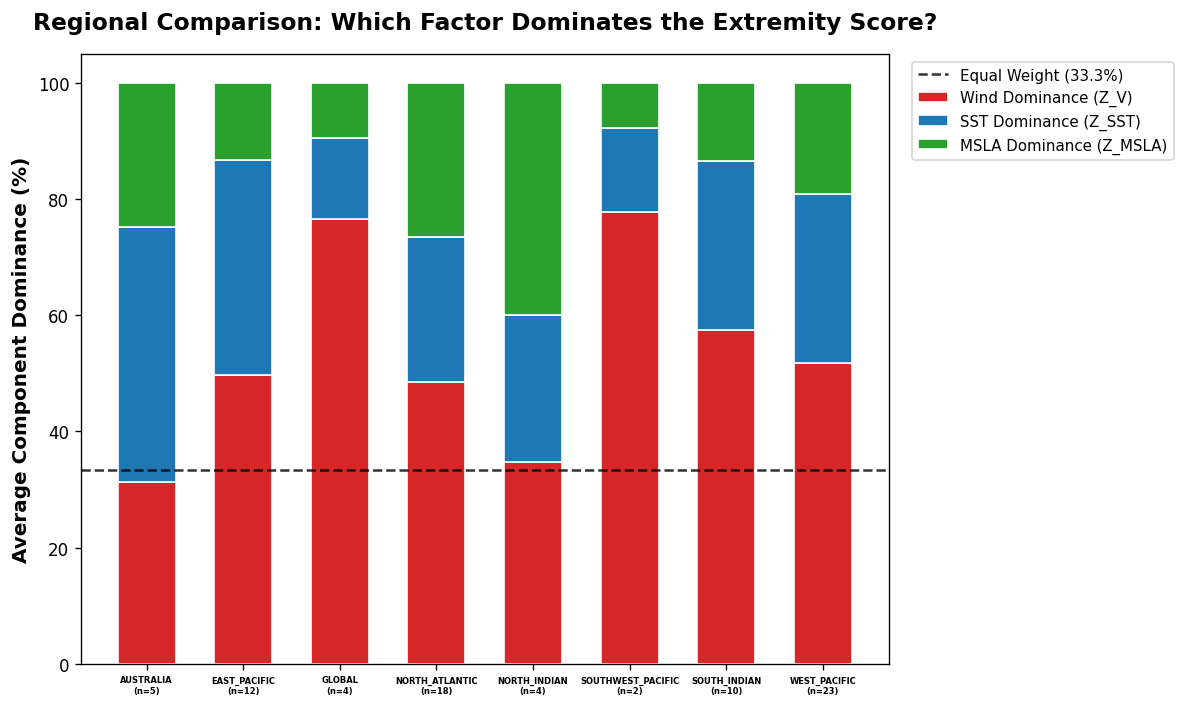

In [ ]:
import json

# =============================================================================
# REGIONAL DOMINANCE ANALYSIS
# =============================================================================

def add_basin_info(df, json_path='cyclone_info_2024_padded.json'):
    """Extracts the ocean basin from the JSON and attaches it to the DataFrame."""
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    basin_map = {}
    for basin_key, basin_data in data.items():
        if not isinstance(basin_data, dict) or 'storms' not in basin_data:
            continue
        for s in basin_data['storms']:
            basin_map[s['name'].upper()] = basin_key.upper()
            
    df_out = df.copy()
    df_out['Basin'] = df_out['Cyclone'].map(basin_map)
    return df_out

def plot_regional_dominance(df, json_path='cyclone_info_2024_padded.json', save=True):
    """
    Groups cyclones by Basin and calculates which Z-score component 
    (Wind, SST, MSLA) dominates the COCI score on average for that region.
    """
    # 1. Attach basin info if missing
    if 'Basin' not in df.columns:
        df = add_basin_info(df, json_path)
        
    # 2. Re-calculate dominance mathematically cleanly
    df['Abs_Z_SST'] = df['Z_SST'].abs()
    df['Abs_Z_MSLA'] = df['Z_MSLA'].abs()
    df['Abs_Z_V'] = df['Z_V'].abs()
    
    df['Total_Abs_Z'] = df['Abs_Z_SST'] + df['Abs_Z_MSLA'] + df['Abs_Z_V']
    
    df['Pct_V'] = (df['Abs_Z_V'] / df['Total_Abs_Z']) * 100
    df['Pct_SST'] = (df['Abs_Z_SST'] / df['Total_Abs_Z']) * 100
    df['Pct_MSLA'] = (df['Abs_Z_MSLA'] / df['Total_Abs_Z']) * 100
    
    # 3. Filter valid rows
    valid = df.dropna(subset=['Pct_V', 'Pct_SST', 'Pct_MSLA', 'Basin'])
    if valid.empty:
        print("No valid basin data found.")
        return
        
    # 4. Group by Basin and get the averages
    regional_means = valid.groupby('Basin')[['Pct_V', 'Pct_SST', 'Pct_MSLA']].mean()
    cyclone_counts = valid.groupby('Basin')['Cyclone'].count()
    
    # Determine the statically dominating factor per region
    def get_dominant(row):
        labels = {'Pct_V': 'Wind', 'Pct_SST': 'SST', 'Pct_MSLA': 'MSLA'}
        return labels[row.idxmax()]
        
    regional_means['Dominant_Factor'] = regional_means.apply(get_dominant, axis=1)
    
    # Print the textual leaderboard
    print("\n" + "="*50)
    print("   REGIONAL COMPONENTS DOMINANCE SUMMARY")
    print("="*50)
    for basin in regional_means.index:
        count = cyclone_counts[basin]
        dom = regional_means.loc[basin, 'Dominant_Factor']
        v = regional_means.loc[basin, 'Pct_V']
        s = regional_means.loc[basin, 'Pct_SST']
        m = regional_means.loc[basin, 'Pct_MSLA']
        print(f"[{basin}] (n={count} cyclones)")
        print(f"  → Dominant Factor: {dom}")
        print(f"  → Wind: {v:.1f}% | SST: {s:.1f}% | MSLA: {m:.1f}%\n")
        
    # 5. Plotting a 100% stacked bar chart by Region
    x = np.arange(len(regional_means))
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack the bars
    ax.bar(x, regional_means['Pct_V'], 
           label='Wind Dominance (Z_V)', color='#d62728', edgecolor='white', width=0.6)
           
    ax.bar(x, regional_means['Pct_SST'], bottom=regional_means['Pct_V'], 
           label='SST Dominance (Z_SST)', color='#1f77b4', edgecolor='white', width=0.6)
           
    ax.bar(x, regional_means['Pct_MSLA'], bottom=regional_means['Pct_V'] + regional_means['Pct_SST'], 
           label='MSLA Dominance (Z_MSLA)', color='#2ca02c', edgecolor='white', width=0.6)
    
    ax.set_xticks(x)
    labels = [f"{b}\n(n={cyclone_counts[b]})" for b in regional_means.index]
    ax.set_xticklabels(labels, fontsize=5, fontweight='bold')
    
    # Draw reference line at exactly a 33% split
    ax.axhline(33.33, color='black', linestyle='--', alpha=0.8, linewidth=1.5, label='Equal Weight (33.3%)')
    
    ax.set_ylabel('Average Component Dominance (%)', fontsize=12, fontweight='bold')
    ax.set_title('Regional Comparison: Which Factor Dominates the Extremity Score?', 
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
    
    plt.tight_layout()
    if save:
        plt.savefig('Regional_Component_Dominance.png', dpi=150, bbox_inches='tight')
        print(f"Saved: Regional_Component_Dominance.png")
    plt.show()

    return regional_means

# =============================================================================
# RUN THE REGIONAL FUNCTION
# =============================================================================
# df_regional_summary = plot_regional_dominance(df_coci, save=True) 8 minute ee jittebi function announce

In [1]:
# ── Gradient Computation ─────────────────────────────────────────────

def compute_submeso_gradient(data_field, resolution, filter_scale, ref_lat):
    """
    Compute sub-mesoscale spatial gradient magnitude.
    
    Parameters
    ----------
    data_field : 2D array-like (e.g. SST or MSLA values)
    resolution : float – grid spacing in degrees (0.05 for SST, 0.125 for MSLA)
    filter_scale : filter scale for mesoscale extraction
    ref_lat : float – reference latitude for dx correction
    
    Returns
    -------
    grad : 2D ndarray – gradient magnitude in units/km
    """
    sub = fast_submeso(data_field, resolution, filter_scale, ref_lat)

    dy, dx = np.gradient(sub)

    dy_km = dy / (111.0 * resolution)
    dx_km = dx / (111.0 * np.cos(np.deg2rad(ref_lat)) * resolution)

    grad = np.sqrt(dx_km**2 + dy_km**2)
    return grad


# ── Panel Drawing ────────────────────────────────────────────────────

def draw_panel(ax, field, lons, lats, bbox,
               cmap, vmin, vmax,
               track_data=None, date=None):

    ax.set_extent([bbox['lon_min'], bbox['lon_max'],
                   bbox['lat_min'], bbox['lat_max']])
    ax.add_feature(cfeature.LAND, facecolor='#d4c9a8')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    norm = Normalize(vmin=vmin, vmax=vmax)
    im = ax.pcolormesh(lons, lats, field,
                       cmap=cmap, norm=norm,
                       shading='auto',
                       transform=ccrs.PlateCarree())

    if track_data and date:
        all_lons = [e[0] for e in track_data]
        all_lats = [e[1] for e in track_data]
        all_dts  = [datetime.strptime(e[2], '%Y-%m-%d %H:%M') for e in track_data]

        # full track (dashed white)
        ax.plot(all_lons, all_lats, '--', color='white', lw=0.8,
                transform=ccrs.PlateCarree())

        # past track up to current date (solid yellow)
        past_lons = [lo for lo, dt in zip(all_lons, all_dts) if dt.date() <= date.date()]
        past_lats = [la for la, dt in zip(all_lats, all_dts) if dt.date() <= date.date()]

        if past_lons:
            ax.plot(past_lons, past_lats, '-o', color='yellow', lw=1, ms=2,
                    transform=ccrs.PlateCarree())
            ax.plot(past_lons[-1], past_lats[-1], '*', color='red', ms=7,
                    transform=ccrs.PlateCarree())

    return im


# ── Multi-panel Evolution Plot ───────────────────────────────────────

def plot_evolution(storm_name, dates, lons, lats, fields, bbox,
                   track, title, unit, vmax, save_path):

    n = len(dates)
    fig = plt.figure(figsize=(max(24, n * 3), 6))
    gs  = gridspec.GridSpec(1, n)

    im_ref = None
    for i, date in enumerate(dates):
        ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
        im = draw_panel(ax, fields[i], lons, lats, bbox,
                        cmap='viridis', vmin=0, vmax=vmax,
                        track_data=track, date=date)
        im_ref = im
        ax.set_title(date.strftime('%b %d'), fontsize=7)

    cax = fig.add_axes([0.92, 0.15, 0.012, 0.7])
    cb  = fig.colorbar(im_ref, cax=cax)
    cb.set_label(unit)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()


# ── Per-storm Processing Loop ────────────────────────────────────────
# Assumes you already have: analysis_dates, track, bbox, storm_name, storm_dir

def _resolve_bbox(bbox_value, track_data, pad_deg=0.6):
    if bbox_value is not None:
        return bbox_value
    if not track_data:
        raise ValueError("bbox is not defined and track is empty, so a bounding box cannot be derived.")

    track_lons = [point[0] for point in track_data]
    track_lats = [point[1] for point in track_data]
    return {
        'lon_min': min(track_lons) - pad_deg,
        'lon_max': max(track_lons) + pad_deg,
        'lat_min': min(track_lats) - pad_deg,
        'lat_max': max(track_lats) + pad_deg,
    }


bbox = _resolve_bbox(globals().get('bbox'), track)
ref_lat = (bbox['lat_min'] + bbox['lat_max']) / 2

sst_grad_history  = []
msla_grad_history = []
sst_lons = sst_lats = None
msla_lons = msla_lats = None

for d in analysis_dates:

    # --- SST gradient ---
    sst = load_sst_for_date(d, bbox)
    if sst is not None:
        if sst_lons is None:
            sst_lons, sst_lats = sst.lon.values, sst.lat.values
        sst_grad_history.append(
            compute_submeso_gradient(sst, 0.05, FILTER_SCALES_SST['meso'], ref_lat)
        )
    else:
        sst_grad_history.append(None)

    # --- MSLA gradient ---
    msla = load_msla_for_date(d, bbox)
    if msla is not None:
        if msla_lons is None:
            msla_lons, msla_lats = msla.longitude.values, msla.latitude.values
        msla_grad_history.append(
            compute_submeso_gradient(msla, 0.125, FILTER_SCALES_MSLA['meso'], ref_lat)
        )
    else:
        msla_grad_history.append(None)

# ── Generate plots ───────────────────────────────────────────────────

if sst_lons is not None:
    plot_evolution(
        storm_name, analysis_dates, sst_lons, sst_lats,
        sst_grad_history, bbox, track,
        f"{storm_name} -- SST Sub-mesoscale Spatial Gradient Magnitude",
        "Gradient (°C/km)", 0.02,
        os.path.join(storm_dir, f"{storm_name}_SST_submeso_grad_evolution.png")
    )

if msla_lons is not None:
    plot_evolution(
        storm_name, analysis_dates, msla_lons, msla_lats,
        msla_grad_history, bbox, track,
        f"{storm_name} -- MSLA Sub-mesoscale Spatial Gradient Magnitude",
        "Gradient (m/km)", 0.003,
        os.path.join(storm_dir, f"{storm_name}_MSLA_submeso_grad_evolution.png")
    )

NameError: name 'bbox' is not defined